# Setup Code
(Run this entire section as is, no edits needed)

## Package imports and google drive filesystem setup

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from cycler import cycler
from IPython.display import clear_output
# from google.colab import output

In [2]:
# from google.colab import drive
# # Suppress the output statement "Mounted at /content/drive"
# with open(os.devnull, 'w') as f:
#     old_stdout = sys.stdout
#     sys.stdout = f
#     drive.mount('/content/drive', force_remount=True)
#     sys.stdout = old_stdout  # Restore the original stdout

## Function Definitions

### Handling of raw model files

In [3]:
# Functions to access model parameters from the model's filename. For use in sorting a list of models before loading their data

def get_mass(model):
    filename_params = (model.split('.')[1]).split('_')
    return float(filename_params[0].split('V')[0].replace('M','').replace('p','.'))

def get_index(model):
    filename_params = (model.split('.')[1]).split('_')
    return float('.'.join(filename_params[4].split('d')))

def get_rho_0(model):
    filename_params = (model.split('.')[1]).split('_')
    rho_0_exp = float(filename_params[5].split('e')[1].replace('m','-'))
    rho_0_mant = float('.'.join(filename_params[5].split('e')[0].split('d')))
    return rho_0_mant*10**rho_0_exp

def get_R_disk(model):
    filename_params = (model.split('.')[1]).split('_')
    return float('.'.join(filename_params[6].replace('rd','').split('p')))

def get_angle(model):
    return (model.split('.')[1]).split('_')[-1].replace('i','')

In [4]:
# Load data from a model file into useable data structures.
# Takes in a path to a model file
# Returns:
#   > dataframe: a pandas dataframe containing the model's spectral data. Columns are:
#                 - "Wavelength" (wavelength axis values, in Angstroms),
#                 - "Flux" (flux axis values, non-normalized),
#                 - "Checksum" (computational check values, not used in most analysis)
#   > header: model metadata stored as a dictionary. Keys and corresponding values are documented with inline comments and in the "overview of model parameters" section

def load_model(file_path):
    # Load the spectral data (wavelengths and fluxes) into a pandas dataframe
    dataframe = pd.read_table(file_path, sep="\\s+", names=["Wavelength","Flux","Checksum"], index_col=0, skiprows=5)

    # Extract model parameters from file name
    filename_params = (file_path.split('.')[1]).split('_')
    rho_0_exp = float(filename_params[5].split('e')[1].replace('m','-'))
    rho_0_mant = float('.'.join(filename_params[5].split('e')[0].split('d')))
    rho_0 = rho_0_mant*10**rho_0_exp
    r_disk = float('.'.join(filename_params[6].replace('rd','').split('p')))

    # Read the header information and filename parameters into a dictionary to access later
    with open(file_path,"r") as file:
        header_lines = file.readlines()[:5]
        file.close()

    # Split header lines by whitespace to separate keywords and values
    for i, line in enumerate(header_lines):
        line = [str.strip() for str in line.split(' ') if str]
        header_lines[i] = line

    # Store model parameters and header info in a dictionary
    header = {}
    header['Power Index'] = float('.'.join(filename_params[4].split('d'))) # disk density power law exponent
    header['rho_0'] = rho_0 # base disk density
    header['Disk Radius'] = r_disk # outer disk radius, in units of R_eq
    header['Wavelength'] = float(header_lines[1][3]) # Reference wavelength of some kind?
    header['Equivalent Width'] = float(header_lines[1][6]) # Equivalent width of the H-alpha line, in angstroms
    header['Pdiff'] = float(header_lines[1][10]) # Not really sure about this
    header['Rotational Velocity'] = float(header_lines[2][3]) # Rotational velocity of the star, in km/s
    header['v sin i'] = float(header_lines[2][6]) # Observable rotational velocity (based on inclination angle), in km/s
    header['Inclination Angle'] = float(header_lines[2][9]) # Inclination angle of the star/disk, in degrees
    header['Radius'] = float(header_lines[3][3]) # Radius of the star, in R_sun
    header['Mass'] = float(header_lines[3][6]) # Mass of the star, in M_sun
    header['T_eff'] = float(header_lines[3][9]) # Surface temperature of the star, in K
    header['log g'] = float(header_lines[3][12]) # log of star's surface gravity
    header['v_frac'] = float(header_lines[4][3]) # rotational velocity as fraction of critical velocity (?)
    header['R_pole'] = float(header_lines[4][9]) # Polar radius of the star, in R_sun
    header['R_eq'] = float(header_lines[4][12]) # Equatorial radius of the star, in R_sun

    return dataframe, header


### Seeing and convolution codes
[Written by Sten Gustaffson]

In [5]:
# Calculate grism plate scale based on telescope and camera parameters
def grism_plate_scale(focal_length, pixel_size, f_ratio, colli_fl, focus_fl):
    grism_f_ratio = f_ratio / (colli_fl / focus_fl)
    return (pixel_size / (focal_length*(grism_f_ratio/f_ratio))).to(u.dimensionless_unscaled) * 206265 * u.arcsec / u.pix

# Calculate fwhm of idealized spectral line's dispersion
def seeing_fwhm(seeing, dispersion, plate_scale):
    # seeing: atmospheric seeing in arcsec
    # dispersion: wavelength dispersion of the grism in angstroms/pixel
    # plate scale: angular plate scale of the grism in arcsec/pixel
    return (seeing * dispersion/plate_scale)

In [6]:
# convolve a model file to a lower spectral resolution
def convolve_model(model_data, fwhm):
  #Load data and get array of wavelengths and fluxes
  model_wavelengths = np.array(model_data["Wavelength"])
  norm_model_flux = model_data['Flux']/model_data['Flux'][1] # Normalize flux to the continuum value

  d_wavelength = (model_wavelengths[len(model_wavelengths)-1]-model_wavelengths[0])/len(model_wavelengths-1) # in angstroms
  sigma = (fwhm.value/(2*np.sqrt(2*np.log(2))))/d_wavelength # in indices
  # print(sigma)

  gaussian_pos_x_vals = np.arange(0, 3*sigma, 1)
  gaussian_neg_x_vals = np.flip(np.arange(-1, -3*sigma, -1))
  # the positive and negative arrays are to ensure the values are symmetric around zero and will always be odd in number.
  gaussian_x_vals = np.append(gaussian_neg_x_vals, gaussian_pos_x_vals)# array covering 3 standard deviations on either side of zero in steps of 1.

  gaussian = 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(gaussian_x_vals/sigma)**2/2) # normal distribution gaussian function value for each x value with std dev sigma. sum is about one.
  # print(sum(gaussian))
  norm_gaussian = gaussian/sum(gaussian) # force sum to be exactly one (very small change)

  # adding padding equal to the last value on either side to avoid edge distortions
  padded_norm_model_flux = np.append(np.repeat(norm_model_flux[1], len(norm_gaussian)/2), norm_model_flux)
  padded_norm_model_flux = np.append(padded_norm_model_flux, np.repeat(norm_model_flux[len(norm_model_flux)],len(norm_gaussian)/2))

  convolved_model_flux = np.convolve(padded_norm_model_flux, norm_gaussian,"valid")
  # ^valid means that only values where the two arrays fully overlap are in the output array
  # output is the same size as norm_model_flux

  return [model_wavelengths,convolved_model_flux]

### Fitting Code
[Written by Carson Bantz]

In [7]:
# Crop spectral data to range given by wavelengths
# expects spectrum as a csv file, wavelengths as an array of increasing wavelength values (in same units as used in spectrum)
def crop_data(spectrum, wavelengths):
    data = np.genfromtxt(
        spectrum,
        delimiter=",",
        skip_header=1,
        usecols=(0, 1),
        invalid_raise=False
    )

    data = np.atleast_2d(data)

    data_wavelengths = data[:, 0]
    data_fluxes = data[:, 1]

    good = np.isfinite(data_wavelengths) & np.isfinite(data_fluxes)

    data_wavelengths = data_wavelengths[good]
    data_fluxes = data_fluxes[good]

    filtered_mask = (
        (data_wavelengths >= np.nanmin(wavelengths)) &
        (data_wavelengths <= np.nanmax(wavelengths))
    )

    filtered_wavelengths = data_wavelengths[filtered_mask]
    filtered_fluxes = data_fluxes[filtered_mask]

    return filtered_wavelengths, filtered_fluxes

Determine closeness of fit between model and real spectrum. Method adapted from [Sigut et. al (2020)](https://ui.adsabs.harvard.edu/abs/2020ApJ...894...18S/abstract)

In [8]:
def test_model(model, spectrum, fwhm, core_weighted = False):
  # "progress bar" code for doing multiple fits
  model_index = models.index(model)

  if model_index % 5 == 0:
      clear_output(wait=True)
      print(f"Model {model_index}/{len(models)}")

  # Load model and get array of wavelengths and fluxes
  model_data, header = load_model(model)

  # Convolve model to same resolution as grism data
  [model_wavelengths,convolved_model_flux] = convolve_model(model_data, fwhm)

  # Load spectrum data from csv and crop to model range
  filtered_data_wavelengths, filtered_data_fluxes = crop_data(spectrum, model_wavelengths)

  # find nearest model point to compare with spectral data point
  closest_indices = []  # Store indices of closest wavelengths to make equivalent dataset from model
  for i in filtered_data_wavelengths:
    distance = np.abs(model_wavelengths - i)
    closest_indices.append(np.argmin(distance))

  # Select model data points that will be used for comparison
  reduced_model_wavelengths = np.array(model_wavelengths[closest_indices])
  reduced_model_fluxes = np.array(convolved_model_flux[closest_indices])

  #Apply core_weighting if requested and return figure of merit (taken from Sigut et al (2020))
  if core_weighted:
    w_i = np.abs(reduced_model_fluxes - 1)
  else:
    w_i = reduced_model_fluxes/reduced_model_fluxes

  figure_of_merit = (1/np.sum(w_i)) * np.sum(w_i * np.abs((reduced_model_fluxes - filtered_data_fluxes)/filtered_data_fluxes)) * 100

    # pretty pictures (comment for actual use)
    # plt.plot(model_wavelengths, norm_model_flux)
    # plt.plot(model_wavelengths, convolved_model_flux)
    # plt.show()

  return (figure_of_merit)


### Plotting codes

In [9]:
# Plot the normalized spectrum of a single model
# Also displays model parameters from header data
def plot_model(dataframe, header):
    norm_flux = dataframe['Flux']/dataframe['Flux'][1] # Normalize flux to the continuum value

    # Set plot dimensions (wide)
    fig, ax = plt.subplots()
    fig.set_size_inches(15,5)

    # Plot modeled spectrum
    ax.plot(dataframe['Wavelength'], norm_flux)

    # add axes labels
    ax.set_xlabel('Wavelength (Angstroms)')
    ax.set_ylabel('Continuum-Normalized Flux')

    #Uncomment this line to use a fixed y-scale across all plots
    ax.set_ylim(0,10)

    box = dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.5) # info box style arguments

    # Show model parameters in info box
    model_params = '\n'.join((
        r'$M_{star} = %.2f \ M_{\odot}$' % (header['Mass'], ),
        r'$n = %.2f$' % (header['Power Index'], ),
        r'$\rho_0 = %.2e$' % (header['rho_0'], ),
        r'$R_d = %.2f \ R_{\odot}$' % (header['Disk Radius'], ),
        r'$i = %.0f \degree$' % (header['Inclination Angle'], )
    ))
    ax.text(0.02, 0.95, model_params, transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=box)

    # Show other header values in info box
    header_text = '\n'.join((
        r'$R_{star} = %.2f \ R_{\odot}$' % (header['Radius'], ),
        r'Equivalent Width $= %.2f \ Å$' % (header['Equivalent Width'], ),
        r'$v_{\mathrm{rot}} = %.2f \ \mathrm{km/s}$' % (header['Rotational Velocity'], )
    ))
    ax.text(0.98, 0.95, header_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right', bbox=box)


    plt.show()

In [10]:
# Plot a model spectrum alongside its convolved version
def plot_convolved_model(dataframe, header, fwhm):
    norm_flux = dataframe['Flux']/dataframe['Flux'][1] # Normalize flux to the continuum value
    [model_wavelengths, convolved_flux] = convolve_model(dataframe, fwhm)

    # Set plot dimensions (wide)
    fig, ax = plt.subplots()
    fig.set_size_inches(10,5)

    # Plot full-resolution modeled spectrum
    ax.plot(dataframe['Wavelength'], norm_flux, color='#1f77b4', linestyle='dashed')

    # Plot convolved model
    ax.plot(model_wavelengths, convolved_flux, color = '#ff7f0e')


    # add axes labels
    ax.set_xlabel('Wavelength (Angstroms)')
    ax.set_ylabel('Continuum-Normalized Flux')

    # Uncomment this line to use a fixed y-scale across all plots
    ax.set_ylim(0,10)

    box = dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.5) # info box style arguments

    # Show model parameters in info box
    model_params = '\n'.join((
        r'$M_{star} = %.2f \ M_{\odot}$' % (header['Mass'], ),
        r'$n = %.2f$' % (header['Power Index'], ),
        r'$\rho_0 = %.2e$' % (header['rho_0'], ),
        r'$R_d = %.2f \ R_{\odot}$' % (header['Disk Radius'], ),
        r'$i = %.0f \degree$' % (header['Inclination Angle'], )
    ))
    ax.text(0.02, 0.95, model_params, transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=box)

    # Show other header values in info box
    header_text = '\n'.join((
        r'$R_{star} = %.2f \ R_{\odot}$' % (header['Radius'], ),
        r'Equivalent Width $= %.2f \ Å$' % (header['Equivalent Width'], ),
        r'$v_{\mathrm{rot}} = %.2f \ \mathrm{km/s}$' % (header['Rotational Velocity'], )
    ))
    ax.text(0.98, 0.95, header_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right', bbox=box)


    plt.show()

In [11]:
# Plot an overlaid series of models
# Expects a list of model filenames that vary in exactly one model parameter
# This parameter is passed in via 'keyword' to use in retrieving data from the model header
def plot_model_series(models, fwhm, keyword):
    model_dict = {}
    convolved_dict = {}
    for model in models:
      dataframe, header = load_model(model)
      model_dict[header[keyword]] = dataframe

    dataframe, header = load_model(models[0])

    # Select static model parameters to display based on keyword
    model_params = []
    if keyword != 'Mass':
        model_params.append(r'$M_{star} = %.2f \ M_{\odot}$' % (header['Mass'], ))
    if keyword != 'Power Index':
      model_params.append(r'$n = %.2f$' % (header['Power Index'], ))
    if keyword != 'rho_0':
      model_params.append(r'$\rho_0 = %.2e$' % (header['rho_0'], ))
    if keyword != 'Disk Radius':
      model_params.append(r'$R_d = %.2f \ R_{*}$' % (header['Disk Radius'], ))
    if keyword != 'Inclination Angle':
      model_params.append(r'$i = %.0f \degree$' % (header['Inclination Angle'], ))

    display_params = '\n'.join(model_params)


    box = dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.5) # info box style arguments

    # redefine color scheme for plotting spectra.
    # Recommended to use a sequential color list (i.e. intensity, color gradient, resistor codes, etc.) with at least as many entries as expected spectra in list
    plt.rcParams['axes.prop_cycle'] = cycler(
        color=['DarkRed', 'OrangeRed', 'orange', 'Gold', 'yellow', 'GreenYellow', 'Lime', 'cyan', 'Teal', 'blue', 'indigo', 'purple', 'black']
        )

    # Set up full-resolution plots
    fig1,ax1 = plt.subplots()
    fig1.set_size_inches(10,10)

    # add title, axes labels, and info box
    ax1.set_title('Full Resolution Models')
    ax1.set_xlabel('Wavelength (Angstroms)')
    ax1.set_ylabel('Continuum-Normalized Flux')
    ax1.text(0.02, 0.95, display_params, transform=ax1.transAxes, verticalalignment='top', horizontalalignment='left', bbox=box)

    # Uncomment this line to focus in on H alpha line region
    ax1.set_xlim(6546,6580)


    fig2,ax2 = plt.subplots()
    fig2.set_size_inches(10,10)

    # add title, axes labels, and info box
    ax2.set_title('Convolved Models')
    ax2.set_xlabel('Wavelength (Angstroms)')
    ax2.set_ylabel('Continuum-Normalized Flux')
    ax2.text(0.02, 0.95, display_params, transform=ax2.transAxes, verticalalignment='top', horizontalalignment='left', bbox=box)

    # Uncomment this line to focus in on H alpha line region
    ax2.set_xlim(6546,6580)

    # Plot models in the list
    for key,dataframe in model_dict.items():
      norm_flux = dataframe['Flux']/dataframe['Flux'][1] # Normalize flux to the continuum value
      [model_wavelengths, convolved_flux] = convolve_model(dataframe, fwhm)

      # generate legend labels based on varying-parameter keyword
      if keyword == 'Mass':
        legend_label = r'$M_{star} = %.2f \ M_{\odot}$' % (key)
      elif keyword == 'Power Index':
        legend_label = r'$n = %.2f$' % (key)
      elif keyword == 'rho_0':
        legend_label = r'$\rho_0 = %.2e$' % (key)
      elif keyword == 'Disk Radius':
        legend_label = r'$R_d = %.2f \ R_{*}$' % (key)
      elif keyword == 'Inclination Angle':
        legend_label = r'$i = %.0f \degree$' % (key)

      ax1.plot(dataframe['Wavelength'], norm_flux, label=legend_label)

      ax2.plot(model_wavelengths, convolved_flux, label=legend_label)

    ax1.legend()
    ax2.legend()


In [12]:
def plot_model_overlay(test_data, dataframe, header, fwhm):
    norm_flux = dataframe['Flux']/dataframe['Flux'][1] # Normalize flux to the continuum value
    [model_wavelengths, convolved_flux] = convolve_model(dataframe, fwhm)
    test_wavelengths = test_data[0]
    test_fluxes = test_data[1]

    # Set plot dimensions (wide)
    fig, ax = plt.subplots()
    fig.set_size_inches(15,5)

    # Plot full-resolution modeled spectrum
    ax.plot(dataframe['Wavelength'], norm_flux, color='C0', linestyle='dashed')

    # Plot convolved model
    ax.plot(model_wavelengths, convolved_flux, color = 'C1')

    # Plot grism spectrum
    ax.scatter(test_wavelengths,test_fluxes, facecolors='none', edgecolors='red', marker='o')


    # add axes labels
    ax.set_xlabel('Wavelength (Angstroms)')
    ax.set_ylabel('Continuum-Normalized Flux')

    # Uncomment this line to use a fixed y-scale across all plots
    #ax.set_ylim(0,5)

    box = dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.5) # info box style arguments

    # Show model parameters in info box
    model_params = '\n'.join((
        r'$M_{star} = %.2f \ M_{\odot}$' % (header['Mass'], ),
        r'$n = %.2f$' % (header['Power Index'], ),
        r'$\rho_0 = %.2e$' % (header['rho_0'], ),
        r'$R_d = %.2f \ R_{\odot}$' % (header['Disk Radius'], ),
        r'$i = %.0f \degree$' % (header['Inclination Angle'], )
    ))
    ax.text(0.02, 0.95, model_params, transform=ax.transAxes, verticalalignment='top', horizontalalignment='left', bbox=box)

    # Show other header values in info box
    header_text = '\n'.join((
        r'$R_{star} = %.2f \ R_{\odot}$' % (header['Radius'], ),
        r'Equivalent Width $= %.2f \ Å$' % (header['Equivalent Width'], ),
        r'$v_{\mathrm{rot}} = %.2f \ \mathrm{km/s}$' % (header['Rotational Velocity'], )
    ))
    ax.text(0.98, 0.95, header_text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='right', bbox=box)


    plt.show()

# Overview of Model Parameters

The code used to generate these spectra uses the following equation to model the disk density:

$$ \rho(R,Z) = \rho_0 \left( \frac{R_*}{R} \right)^n e^{-\left( \frac{Z}{H} \right)^2} $$

* $R$ is the radial distance in the equatorial plane of the star/disk; $Z$ is the vertical height above/below this plane
* $R_*$ is the stellar radius
* $\rho_0$ is the base density of the disk (at $R=R_*$)
* $H$ is the scale height of the disk, which is proportional to the temperature of the disk
* $\rho_0$ and $n$, the power-law index, are free parameters

The spectrum modeling code takes in options for $n$ and $\rho_0$ as well as for $R_d$, the outer radius of the disk, and $i$ the inclination angle

## List of model parameter options:


* ### $M$ (star mass):
    `[2p5,3p0,3p2,3p5,3p7,4p2,4p7,5p5,6p0,7p0,8p0]`

    $(2.5\ M_{\odot},3.0\ M_{\odot},3.2\ M_{\odot},3.5\ M_{\odot},3.7\ M_{\odot},4.2\ M_{\odot},4.7\ M_{\odot},5.5\ M_{\odot},6.0\ M_{\odot},7.0\ M_{\odot},8.0\ M_{\odot})$

    These masses correspond roughly to the following spectral types (on the main sequence):

    * $2.5\ M_{\odot} ↔\text{A0 - B9}$
    * $3.0\ M_{\odot} ↔\text{B9 - B8}$
    * $3.2\ M_{\odot} ↔\text{B8}$
    * $3.5\ M_{\odot} ↔\text{B8 - B7}$
    * $3.7\ M_{\odot} ↔\text{B7}$
    * $4.2\ M_{\odot} ↔\text{B6}$
    * $4.7\ M_{\odot} ↔\text{B5}$
    * $5.5\ M_{\odot} ↔\text{B4 - B3}$
    * $6.0\ M_{\odot} ↔\text{B3 - B2}$
    * $7.0\ M_{\odot} ↔\text{B2}$
    * $8.0\ M_{\odot} ↔\text{B2 - B1}$

* ### $n$ (power-law index):

    `[1d50,1d75,2d00,2d25,2d50,2d75,3d00,3d25,3d50,3d75,4d00]`

    $(1.50,1.75,2.00,2.25,2.50,2.75,3.00,3.25,3.50,3.75,4.00)$
* ### $\rho_0$ (base disk density):

    `[1d00em12,1d48em12,2d20em12,3d27em12,4d85em12,7d20em12,1d07em11,1d58em11,2d35em11,3d49em11,5d18em11,7d69em11,1d14em10,1d69em10,2d51em10]`

    $(1.00\times 10^{-12},1.48\times 10^{-12},2.20\times 10^{-12},3.27\times 10^{-12},4.85\times 10^{-12},7.20\times 10^{-12})$
    
    $(1.07\times 10^{-11},1.58\times 10^{-11},2.35\times 10^{-11},3.49\times 10^{-11},5.18\times 10^{-11},7.69\times 10^{-11})$
    
    $(1.14\times 10^{-10},1.69\times 10^{-10},2.51\times 10^{-10})$
* ### $R_d$ (outer disk radius):

    `[5p0,15p0,25p0,35p0,45p0,55p0,65p0]`
        
    $(5.0\ R_\odot, 15.0\ R_\odot, 25.0\ R_\odot, 35.0\ R_\odot, 45.0\ R_\odot, 55.0\ R_\odot, 65.0\ R_\odot)$
* ### $i$ (inclination angle):

    `[0,10,20,30,40,50,60,70,80,83,85,87,90]`

    $(0°, 10°, 20°, 30°, 40°, 50°, 60°, 70°, 80°, 83°, 85°, 87°, 90°)$

## List of Header Keywords and Values:


* `Power Index` = disk density power law exponent
* `rho_0` = base disk density, in $\text{g/cm}^3$
* `Disk Radius` = outer disk radius, in units of $R_{eq}$
* `Wavelength` = Reference wavelength of some kind?
* `Equivalent Width` = Equivalent width of the H-alpha line, in angstroms
* `Pdiff` = ¯\\\_(ツ)_/¯
* `Rotational Velocity` = Rotational velocity of the star, in $\text{km/s}$
* `v sin i` = Observable rotational velocity (based on inclination angle), in $\text{km/s}$
* `Inclination Angle` = Inclination angle of the star/disk, in degrees
* `Radius` = Radius of the star, in $R_{\odot}$
* `Mass` = Mass of the star, in $M_{\odot}$
* `T_eff` = Surface temperature of the star, in $\text{K}$
* `log g` = log of star's surface gravity (in $\text{m/s}^2$)
* `v_frac` = rotational velocity as fraction of critical velocity (probably?)
* `R_pole` = Polar radius of the star, in $R_{\odot}$
* `R_eq` = Equatorial radius of the star, in $R_{\odot}$

In [13]:
import importlib
import model_spectra_utils
importlib.reload(model_spectra_utils)
from model_spectra_utils import *

# 3D Model Visualization

In [ ]:
import numpy as np
import astropy.units as u
from astropy.constants import G, k_B, m_p, M_sun, R_sun

def compute_H0(
    Mstar,
    Rstar,
    Teff,
    disk_temp_fraction=0.6,
    mu=0.62,
):
    """
    Compute H0 in units of R_star from vertical hydrostatic equilibrium.

    H(R) = H0 * R^(3/2)

    where R is in units of R_star.

    Parameters
    ----------
    Mstar : float
        Stellar mass in solar masses.
    Rstar : float
        Stellar radius in solar radii.
    Teff : float or None
        Stellar effective temperature in K.
    Tdisk : float or None
        Disk temperature in K. If None, uses disk_temp_fraction * Teff.
    disk_temp_fraction : float
        Approximate Tdisk / Teff.
    mu : float
        Mean molecular weight. ~0.62 for ionized gas.
    use_sqrt2 : bool
        If True, uses H = sqrt(2) c_s / Omega_K.
        This matches exp[-(Z/H)^2].
        If False, uses H = c_s / Omega_K, matching exp[-Z^2/(2H^2)].

    Returns
    -------
    H0 : float
        Scale height at R = R_star, in units of R_star.
    c_s : astropy Quantity
        Isothermal sound speed.
    v_k : astropy Quantity
        Keplerian/critical speed at R_star.
    Tdisk : astropy Quantity
        Adopted disk temperature.
    """

    Tdisk = disk_temp_fraction * Teff * u.K

    M = Mstar * M_sun
    R = Rstar * R_sun

    c_s = np.sqrt(k_B * Tdisk / (mu * m_p)).to(u.km / u.s)
    v_k = np.sqrt(G * M / R).to(u.km / u.s)

    H0 = (c_s / v_k).decompose().value

    return H0

def make_star_texture(N=256,
                      edge_color=(1.0, 0.45, 0.0),
                      center_color=(1.0, 1.0, 0.85),
                      limb_power=0.75,
                      alpha_power=0.35):

    yy, xx = np.mgrid[-1:1:complex(N), -1:1:complex(N)]
    r = np.sqrt(xx**2 + yy**2)

    t = np.clip(r, 0, 1) ** limb_power

    img = np.zeros((N, N, 4))

    for k in range(3):
        img[..., k] = center_color[k] * (1 - t) + edge_color[k] * t

    # fully opaque across stellar disk, transparent only outside
    img[..., 3] = 1.0
    img[r > 1] = [0, 0, 0, 0]

    return img

def plot_star_disk_3d(
    Mstar=None,
    Rstar=None,
    Teff=None,
    rho0=None,
    Rd=45.0,
    n=None,
    inc_deg=None,
    Rout=None,
    beta=1.5,
    N=300_000,
    density_threshold=1e-16,
    cmap="plasma",
    elev=18,
    azim=-55,
    seed=1,
    point_size=0.7,
    star_plot_radius=1.0,
    density_scale_factor=0.2,
    z_scale_factor = 0.35,
):
    """
    Physical 3D Be-star disk visualization in units of stellar radii.

    Coordinates are in units of R_star.

    Density law:
        rho(R,Z) = rho0 * (1/R)^n * exp[-(Z/H)^2]

    H(R) = H0 * R^beta

    Disk begins at R = 1 R_star.
    Star is drawn as a 3D textured surface using plot_surface.
    No z-axis compression is applied.
    """

    rng = np.random.default_rng(seed)

    if Rout is None:
        Rout = Rd

    Rin = 1.0

    def H(R):
        return compute_H0(Mstar, Rstar, Teff) * R**beta

    def density(R, Z):
        return rho0 * (1.0 / R)**n * np.exp(-(Z / H(R))**2)

    u = rng.random(N)
    R = np.sqrt(Rin**2 + u * (Rout**2 - Rin**2))
    phi = rng.uniform(0, 2 * np.pi, N)
    Z = rng.uniform(-5 * H(R), 5 * H(R))

    X = R * np.cos(phi)
    Y = R * np.sin(phi)

    rho = density(R, Z)

    keep = rho >= density_threshold
    X, Y, Z, R, rho = X[keep], Y[keep], Z[keep], R[keep], rho[keep]

    inc = np.radians(inc_deg)
    Y_rot = Y * np.cos(inc) - Z * np.sin(inc)
    Z_rot = Y * np.sin(inc) + Z * np.cos(inc)

    elev_rad = np.radians(elev)
    azim_rad = np.radians(azim)

    view_vec = np.array([
        np.cos(elev_rad) * np.cos(azim_rad),
        np.cos(elev_rad) * np.sin(azim_rad),
        np.sin(elev_rad),
    ])
    view_vec = view_vec / np.linalg.norm(view_vec)

    P = np.vstack([X, Y_rot, Z_rot]).T
    depth = P @ view_vec
    perp = P - np.outer(depth, view_vec)
    projected_dist = np.linalg.norm(perp, axis=1)

    occulted_by_star = (
        (depth < 0) &
        (projected_dist < star_plot_radius)
    )

    visible = ~occulted_by_star

    X = X[visible]
    Y_rot = Y_rot[visible]
    Z_rot = Z_rot[visible]
    rho = rho[visible]
    depth = depth[visible]

    rho_plot = np.log10(rho)

    alpha_values = np.clip(
        (rho / rho0) ** density_scale_factor,
        0,
        1
    )

    fig = plt.figure(figsize=(20, 18))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho")

    behind = depth < 0
    front = depth >= 0

    sc = ax.scatter(
        X[behind],
        Y_rot[behind],
        Z_rot[behind],
        c=rho_plot[behind],
        s=point_size,
        alpha=alpha_values[behind],
        cmap=cmap,
        depthshade=False,
        rasterized=True,
    )

    # 3D star surface
    u_s = np.linspace(0, 2 * np.pi, 180)
    v_s = np.linspace(0, np.pi, 90)

    xs = star_plot_radius * np.outer(np.cos(u_s), np.sin(v_s))
    ys = star_plot_radius * np.outer(np.sin(u_s), np.sin(v_s))
    zs = star_plot_radius * np.outer(np.ones_like(u_s), np.cos(v_s))

    # Apply same inclination rotation to star coordinates
    ys_rot = ys * np.cos(inc) - zs * np.sin(inc)
    zs_rot = ys * np.sin(inc) + zs * np.cos(inc)

    star_img = make_star_texture(
        N=ys.shape[0],
        edge_color=(1.0, 0.35, 0.0),
        center_color=(1.0, 1.0, 0.85),
    )

    # Viewer-facing color gradient for the star:
    # white/yellow center, orange limb

    P_star = np.stack([xs, ys_rot, zs_rot], axis=-1)

    depth_star = (
        P_star[..., 0] * view_vec[0] +
        P_star[..., 1] * view_vec[1] +
        P_star[..., 2] * view_vec[2]
    )

    perp_star = P_star - depth_star[..., None] * view_vec
    r_proj = np.linalg.norm(perp_star, axis=-1) / star_plot_radius
    r_proj = np.clip(r_proj, 0, 1)

    t = r_proj ** 0.75

    center_color = np.array([1.0, 1.0, 0.85, 1.0])  # pale yellow/white
    edge_color = np.array([1.0, 0.35, 0.0, 1.0])    # orange limb

    star_facecolors = np.zeros((*xs.shape, 4))

    for k in range(4):
        star_facecolors[..., k] = (
            center_color[k] * (1 - t) +
            edge_color[k] * t
        )

    ax.plot_surface(
        xs,
        ys_rot,
        zs_rot,
        facecolors=star_facecolors,
        linewidth=0,
        antialiased=False,
        shade=False,
    )

    ax.scatter(
        X[front],
        Y_rot[front],
        Z_rot[front],
        c=rho_plot[front],
        s=point_size,
        alpha=alpha_values[front],
        cmap=cmap,
        depthshade=False,
        rasterized=True,
    )

    lim = Rout * 1.05

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim*z_scale_factor, lim*z_scale_factor)

    ax.set_box_aspect((1, 1, z_scale_factor), zoom = 1.25)

    ax.set_xlabel(r"$x\ [R_\star]$")
    ax.set_ylabel(r"$y\ [R_\star]$")
    ax.set_zlabel(r"$z\ [R_\star]$")

    ax.view_init(elev=elev, azim=azim)

    ax.set_title(
        rf"Be-star disk visualization: "
        rf"$M_\star={Mstar:.1f}M_\odot$, "
        rf"$R_\star={Rstar:.1f}R_\odot$, "
        rf"$\rho_0={rho0:.1e}$ g cm$^{{-3}}$, "
        rf"$R_d={Rd:.1f}R_\star$, "
        rf"$n={n:.2f}$, "
        rf"$i={inc_deg:.0f}^\circ$"
    )

    cbar = fig.colorbar(sc, ax=ax, shrink=0.65, pad=0.08)
    cbar.set_label(r"$\log_{10}\rho$ [g cm$^{-3}$]")

    plt.tight_layout()
    plt.show()

In [ ]:
Rstar = 6 # solar radii

plot_star_disk_3d(
    Mstar=9,
    Rstar=Rstar,
    Teff = 22000,
    # rho0=1e-12,
    rho0=1.58e-11,
    Rd=20,
    n=4,
    inc_deg=80,
    Rout=None,
    beta = 1.6,
    point_size=0.25,
    N = 2000000,
    elev = 90,
    azim = 90,
    star_plot_radius = 1,
    density_scale_factor = 0.2,
    z_scale_factor = 0.75
)

UnitConversionError: 'J(1/2) / (K(1/2) kg(1/2))' and 'km / s' (speed/velocity) are not convertible

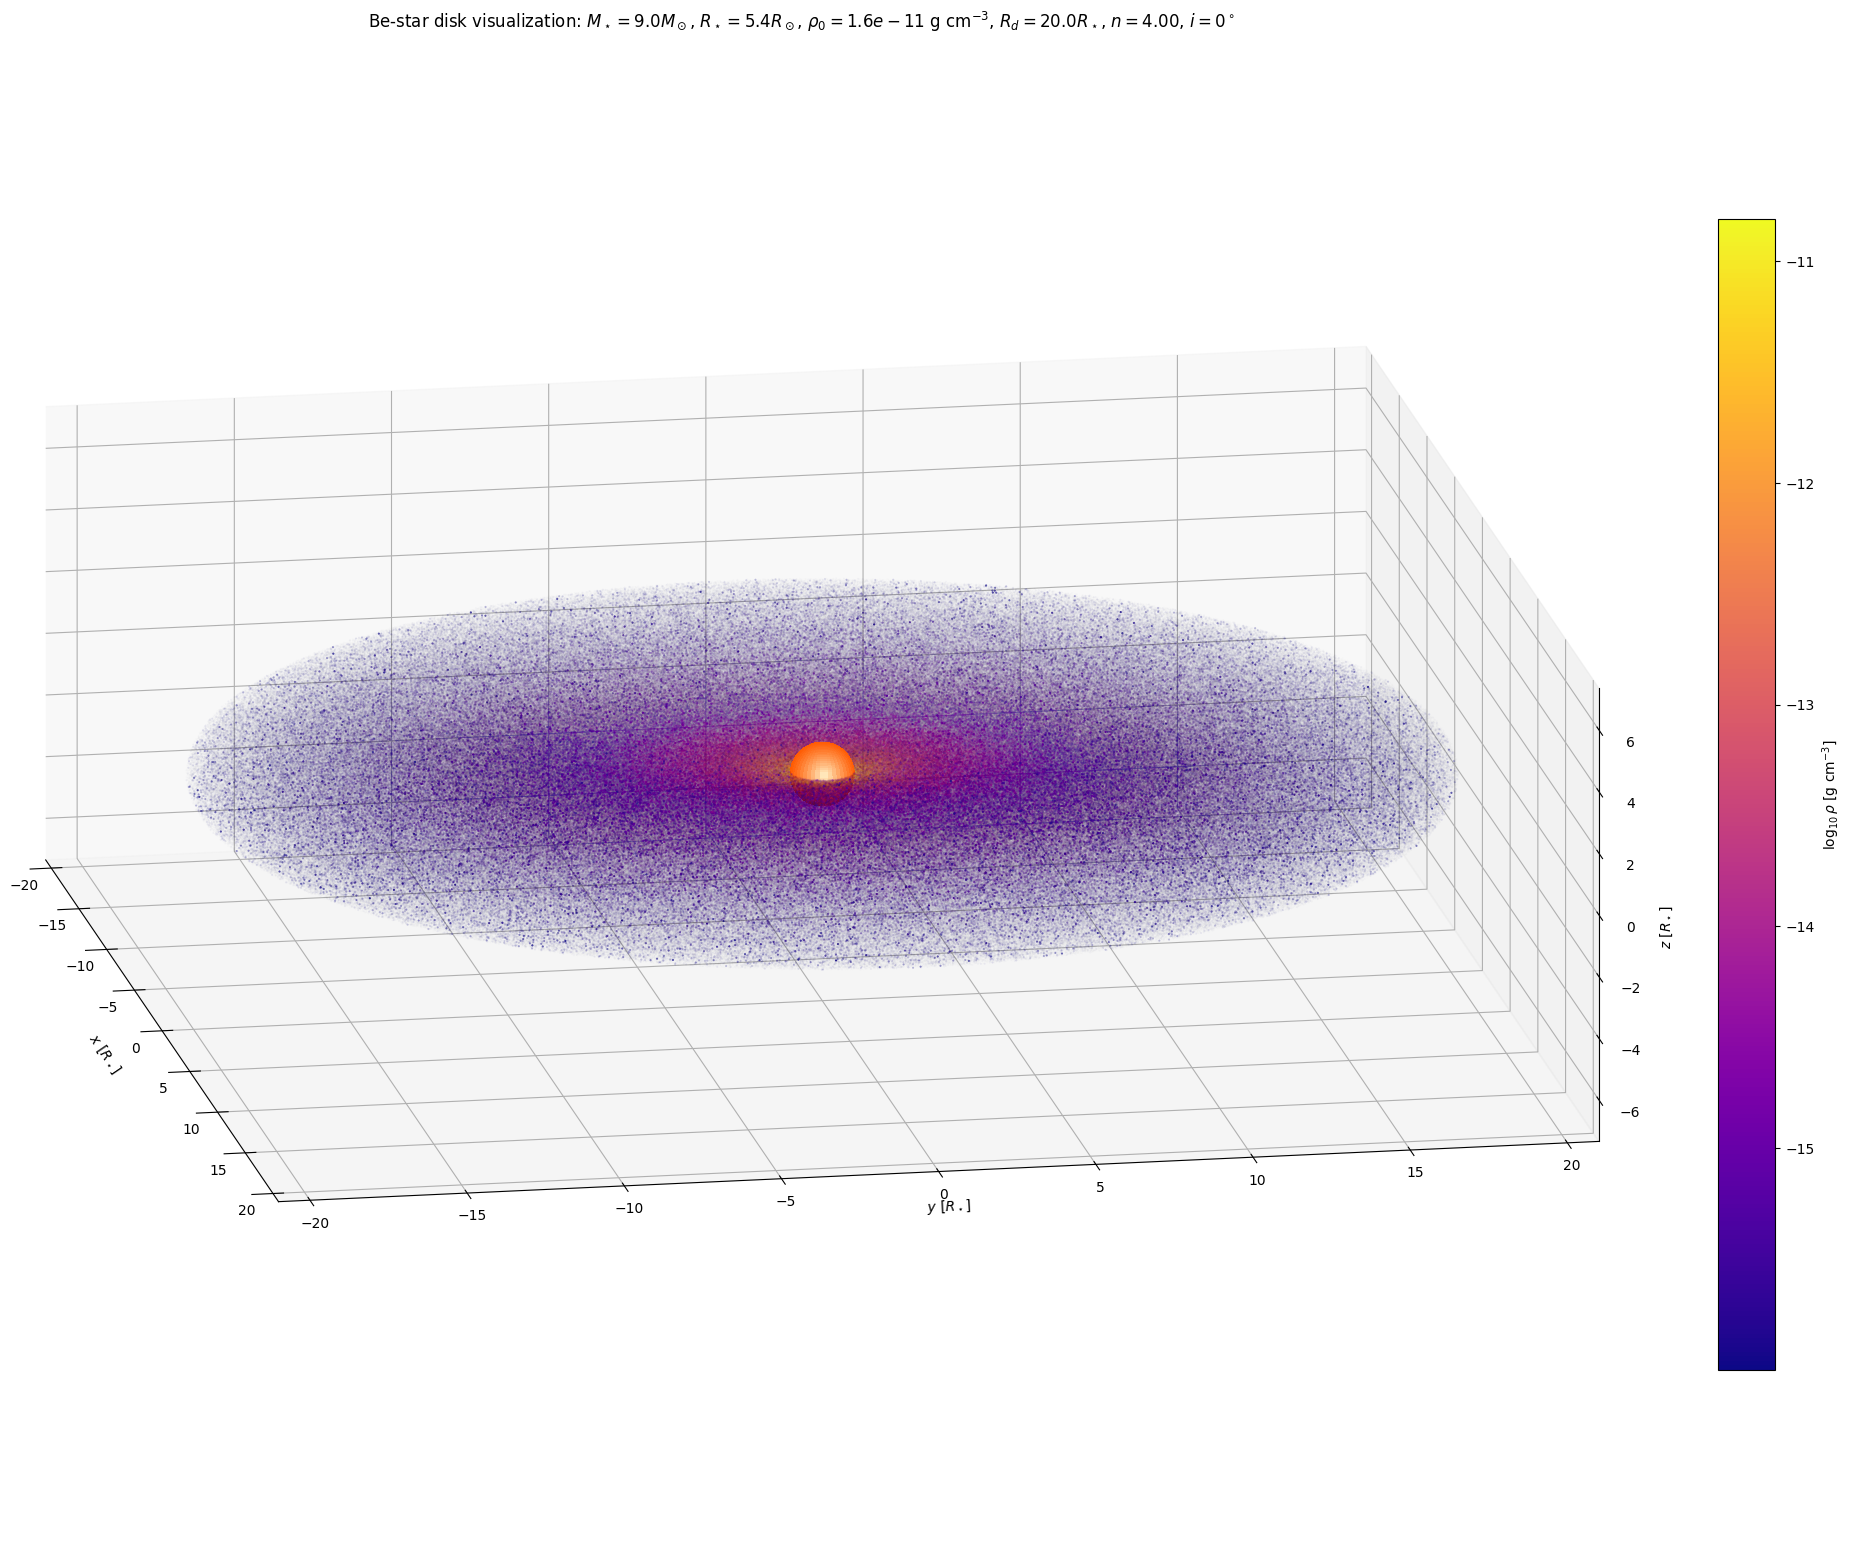

In [ ]:
## Poster parameters, don't change!

Mstar = 9 # solar masses
Rstar = 5.4 # solar radii
Teff = 22000

plot_star_disk_3d(
    Mstar=Mstar,
    Rstar=Rstar,
    Teff=Teff,
    # rho0=1e-12,
    rho0=1.58e-11,
    Rd=20,
    n=4,
    inc_deg=0,
    Rout=None,
    beta = 1.6,
    point_size=0.25,
    N = 20000000,
    elev = 15,
    azim = -10,
    star_plot_radius = 1,
    density_scale_factor = 0.5,
    z_scale_factor = 0.35
)

# Select spectrum data and models for comparison

In [16]:
# models_dir = '/content/drive/MyDrive/SP25-PHYS491/groups/alcyone/Model Spectra'
models_dir = os.path.expanduser('~/Downloads/Model Spectra')


mass = ['8p0', '9p0', '10p0']

# power_index = ['1d50', '1d75', '2d00']
# rho_0 = ['*']
# R_disk = ['5p0','15p0', '25p0', '35p0']
inclination_angle = ['50', '60', '70', '80']

# mass = ['*']
power_index = ['*']
rho_0 = ['*']
R_disk = ['5p0', '15p0', '25p0']
# inclination_angle = ['*']


filters = []
for m in mass:
  for n in power_index:
    for rho in rho_0:
      for r in R_disk:
        for i in inclination_angle:
          filters.append(f'{models_dir}/*{m}*/SPEC.*{n}_{rho}_rd{r}_*i{i}')


models = []
for filter in filters:
  models.extend(glob.glob(filter))
print(f'Found {len(models)} model files')

# Sort models by inclination angle:
models.sort(key=get_angle)

for model in models:
    print(model)

Found 5940 model files
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_1d75_3d27em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d50_1d07em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d00_1d07em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d25_7d20em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d75_7d20em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_4d00_3d49em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_1d50_1d14em10_rd5p0_halpha_alp0p0_i50
/Users/josh

In [17]:
# grism_data_dir = '/content/drive/MyDrive/SP25-PHYS491/final/Calibrated Spectra/ALCYONE_calibrated_csvs/'
grism_data_dir = '/Users/joshuamarine/Desktop/Code/calibrated_data/Lam_Eri_hrg_calibrated_csvs/'
# grism_data_dir = '/Users/joshuamarine/Desktop/Code/calibrated_data/QQ_Gem_hrg_calibrated_csvs/'
grism_data = []
grism_data.extend(glob.glob(f'{grism_data_dir}*norm.csv'))

In [18]:
csv_files = glob.glob(f"{grism_data_dir}*norm.csv")

stacked = stack_spectra_by_day(
    csv_files,
    stack_mode="sum",
    renormalize=True
)

print('Valid dates:')
for key in stacked.keys():
    print(key)

Valid dates:
2025-12-22
2026-01-17
2026-01-28
2026-02-15
2026-03-27
2026-01-31
2025-12-09
2025-12-13
2025-12-14
2025-12-21
2025-11-14
2025-11-21
2025-12-03
2025-11-24
2025-11-27
2025-12-01
2026-02-03
2025-12-11
2026-01-16
2026-02-27
2026-03-04
2026-03-12
2025-12-23
2026-01-15
2025-12-12
2025-12-10
2026-01-10
2026-01-14
2026-01-26
2025-12-07
2025-12-20
2025-11-25
2025-12-15
2026-01-21
2026-02-25
2025-12-19
2025-12-08


In [19]:
stacked_norm = {
    date: normalize_spectrum(
        spec,
        continuum_windows=((6510, 6540), (6590, 6620)),
        plot=False,
    )
    for date, spec in stacked.items()
}

# Find best-fitting models

[5810.26182196 5810.61070363 5810.959659   ... 7398.53688564 7399.05557377
 7399.57428418]


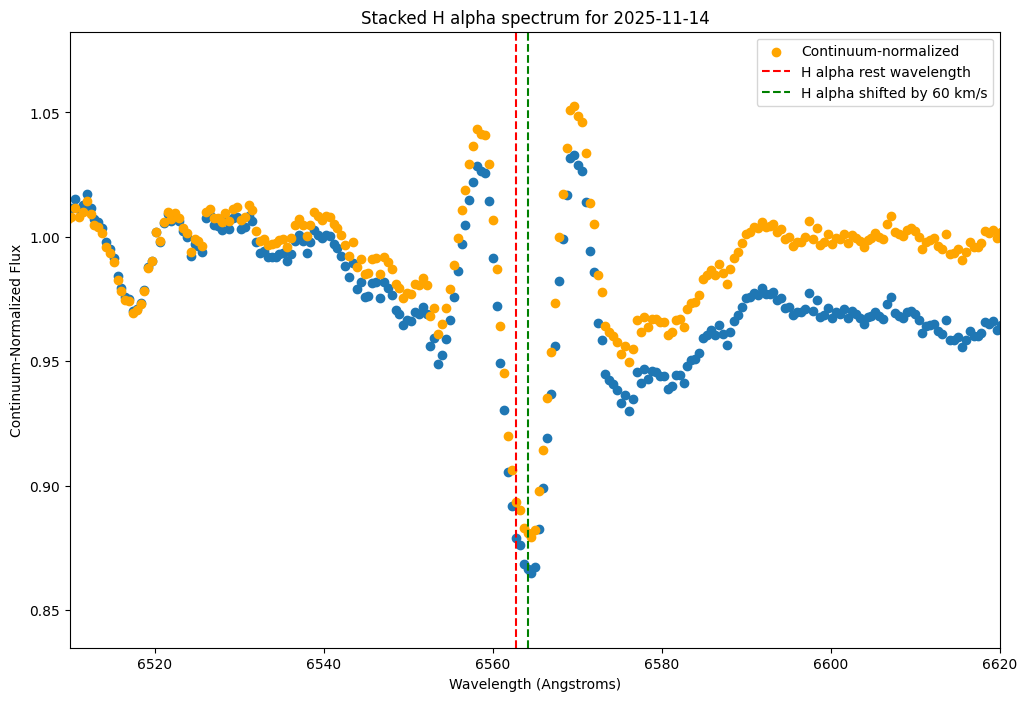

In [21]:
# date_obs = '2010-11-24T00:37:42.99'
# test_spectrum = next((s for s in bess_spectra if s["date_obs"] == date_obs), None)

date_obs = '2025-11-14'
# date_obs = '2025-11-25'
# date_obs = '2025-12-09'
# date_obs = '2026-01-17'

# date_obs = '2025-12-10'
test_spectrum = stacked[date_obs]
test_spectrum_norm = stacked_norm[date_obs]

v_shift = 60 # km/s

xmin = 6510
xmax = 6620
mask = (test_spectrum['wavelength'] >= xmin) & (test_spectrum['wavelength'] <= xmax)
ymin = min(np.min(test_spectrum['flux'][mask]), np.min(test_spectrum_norm['flux'][mask])) - np.std(test_spectrum['flux'][mask])
ymax = max(np.max(test_spectrum['flux'][mask]), np.max(test_spectrum_norm['flux'][mask])) + np.std(test_spectrum['flux'][mask])

print(test_spectrum['wavelength'])

plt.figure(figsize = (12,8))
plt.scatter(test_spectrum['wavelength'], test_spectrum['flux'])
plt.scatter(test_spectrum_norm['wavelength'], test_spectrum_norm['flux'], color='orange', label='Continuum-normalized')
plt.title(f'Stacked H alpha spectrum for {date_obs}')
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Continuum-Normalized Flux')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.axvline(x=6562.8, color = 'red', linestyle = 'dashed', label = 'H alpha rest wavelength')
plt.axvline(x=6562.8*(1+v_shift/2.998e5), color = 'green', linestyle = 'dashed', label = f'H alpha shifted by {v_shift} km/s')
plt.legend()
plt.show()

In [22]:
# Calculate grism plate scale and ersulting convolution fwhm
# Use these values for our telescope/camera and average seeing of 2.4"

plate_scale = grism_plate_scale(3454*u.mm, 7.5*u.um, 6.8, 75*u.mm, 50*u.mm)
fwhm = seeing_fwhm(2.4*u.arcsec, 0.45*u.angstrom/u.pix, plate_scale)
# fwhm = seeing_fwhm(3.6*u.arcsec, 0.45*u.angstrom/u.pix, plate_scale)
fwhm = seeing_fwhm(4.8*u.arcsec, 0.45*u.angstrom/u.pix, plate_scale)
# fwhm = seeing_fwhm(6.0*u.arcsec, 0.45*u.angstrom/u.pix, plate_scale)
print(fwhm)

3.2151261726419897 Angstrom


In [23]:
results, bad_models = fit_models_for_spectrum(
    test_spectrum_norm,
    models,
    fwhm,
    core_weighted = True,
    velocity_guess_kms=60.0,
    velocity_tolerance_kms=100.0,
    fit_velocity=True,
    fit_window=40.0,
    model_center=6562.8
)

summarize_best_fit(results)

Models:   0%|          | 0/235131 [00:00<?, ?model/s]

Skipped 11 bad models.


,model_index,model,error_type,error
0,7251,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
1,24302,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
2,42483,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
3,62827,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
4,80362,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
5,98270,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
6,116720,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
7,135146,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
8,152333,/Users/joshuamarine/Downloads/Model Spectra/M5...,ParserError,Could not construct index. Requested to use 1 ...
9,206297,/Users/joshuamarine/Downloads/Model Spectra/M5...,IndexError,list index out of range


,fom,f_rel,velocity_shift_kms,lambda_shift_A,Mass,Power Index,rho_0,Disk Radius,Inclination Angle,model
0,0.614552,1.000000,60.099066,1.315637,9.0,4.0,2.350000e-11,15.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
1,0.615956,1.002284,60.133514,1.316391,9.0,4.0,2.350000e-11,25.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
2,0.616125,1.002559,60.145192,1.316647,9.0,4.0,2.350000e-11,35.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
3,0.616194,1.002672,60.145679,1.316658,9.0,4.0,2.350000e-11,45.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
4,0.616256,1.002773,60.149098,1.316733,9.0,4.0,2.350000e-11,65.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
5,0.616256,1.002773,60.149098,1.316733,9.0,4.0,2.350000e-11,55.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
6,0.710422,1.155999,57.869858,1.266837,9.0,4.0,2.350000e-11,5.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...
7,0.711127,1.157146,57.575159,1.260386,10.0,3.0,7.200000e-12,5.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M1...
8,0.745811,1.213584,57.932947,1.268219,10.0,4.0,2.350000e-11,5.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M1...
9,0.795857,1.295019,57.774865,1.264758,9.0,3.0,7.200000e-12,5.0,60.0,/Users/joshuamarine/Downloads/Model Spectra/M9...


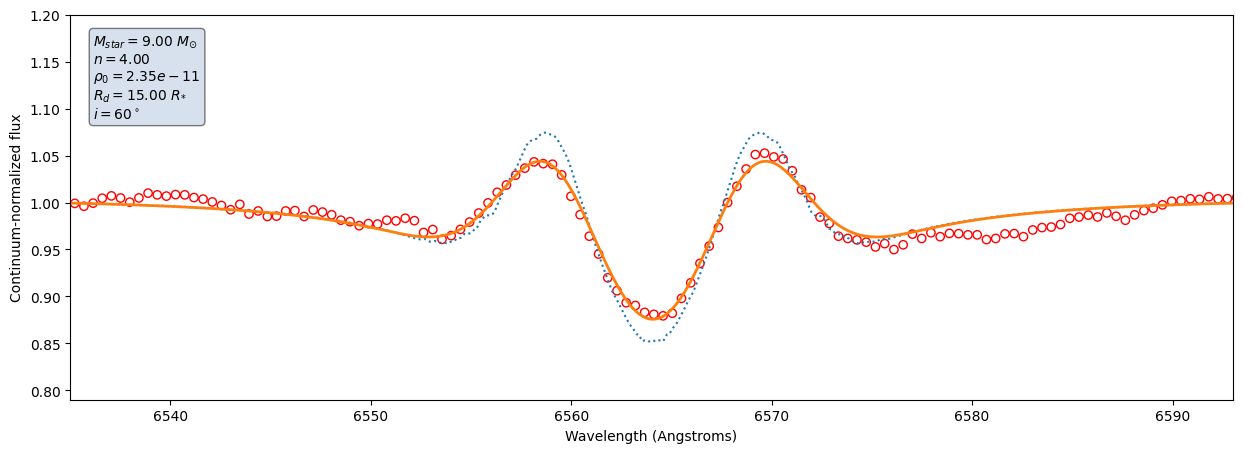

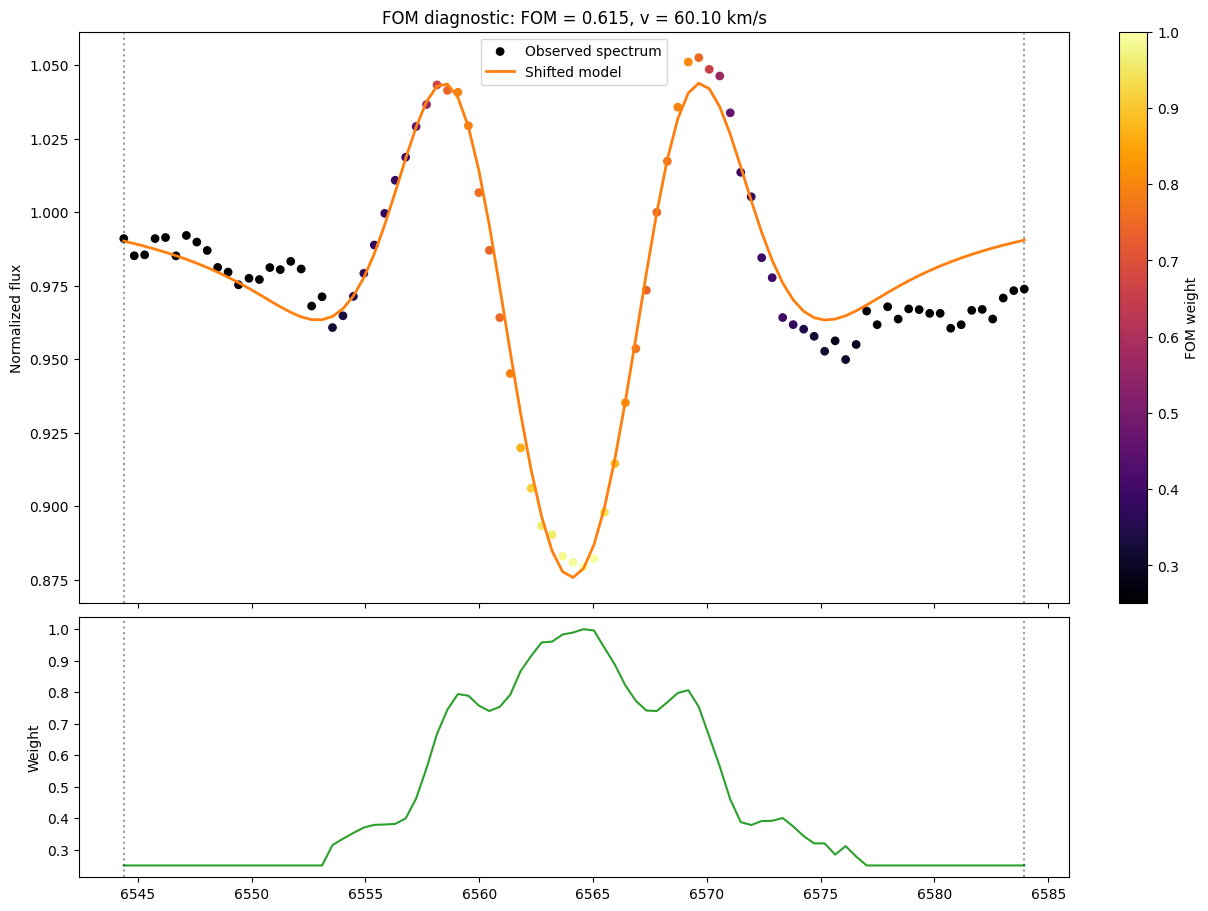

In [24]:
best = results.iloc[0]

dataframe, header = load_model(best["model"])

plot_model_overlay(
    test_spectrum_norm,
    dataframe,
    header,
    fwhm,
    fit_result=best,
    xlim=(6535, 6593),
    ylim=(0.79, 1.2),
    fit_window = 40.0,
    verbose = True,
)

In [25]:
fom_threshold = 3

accepted = results[results["f_rel"] <= fom_threshold].copy()
# accepted = results[results["fom"] <= 1.15].copy()

print(f'{len(accepted)} of {len(results)} model spectra pass fom ≤ {fom_threshold}')

params = [
    "Mass",
    "Power Index",
    "rho_0",
    "Disk Radius",
    "Inclination Angle"
]

accepted[params].describe(percentiles=[0.16, 0.5, 0.84])

471 of 235120 model spectra pass fom ≤ 3


,Mass,Power Index,rho_0,Disk Radius,Inclination Angle
count,471.000000,471.000000,4.710000e+02,471.000000,471.000000
mean,10.608705,3.316348,1.052189e-11,32.048832,59.808917
std,2.272460,0.547216,5.742810e-12,20.884580,10.567192
min,7.000000,1.500000,1.000000e-12,5.000000,30.000000
16%,8.000000,2.750000,4.850000e-12,5.000000,50.000000
50%,10.000000,3.500000,1.070000e-11,35.000000,60.000000
84%,13.900000,4.000000,1.580000e-11,55.000000,70.000000
max,13.900000,4.000000,2.350000e-11,65.000000,80.000000


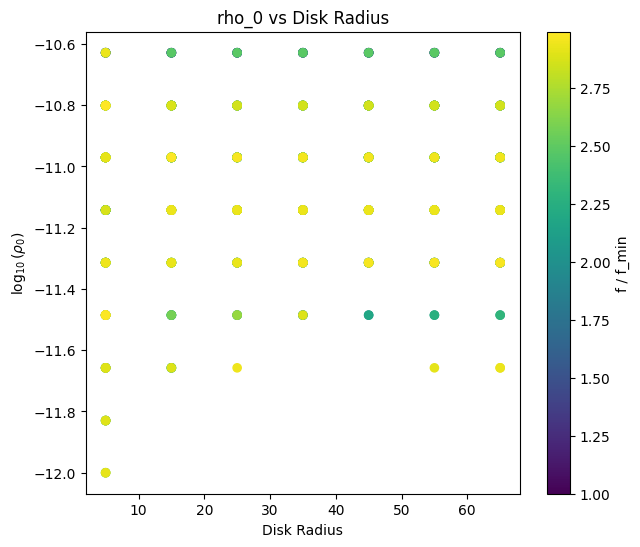

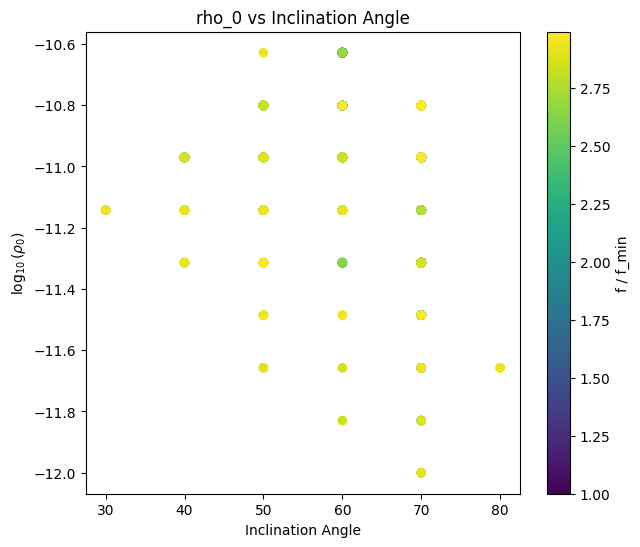

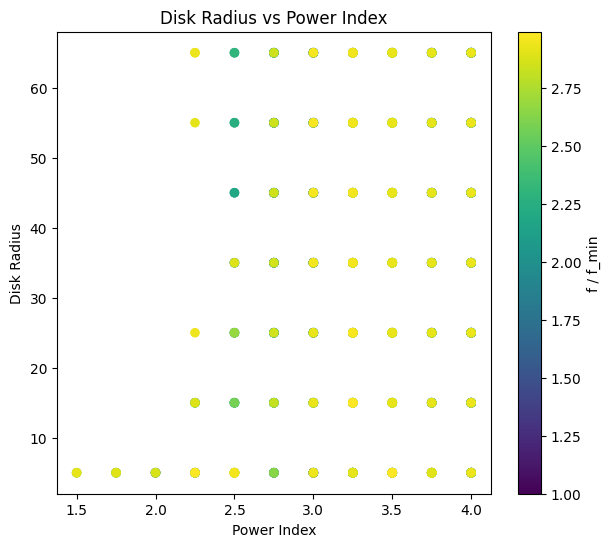

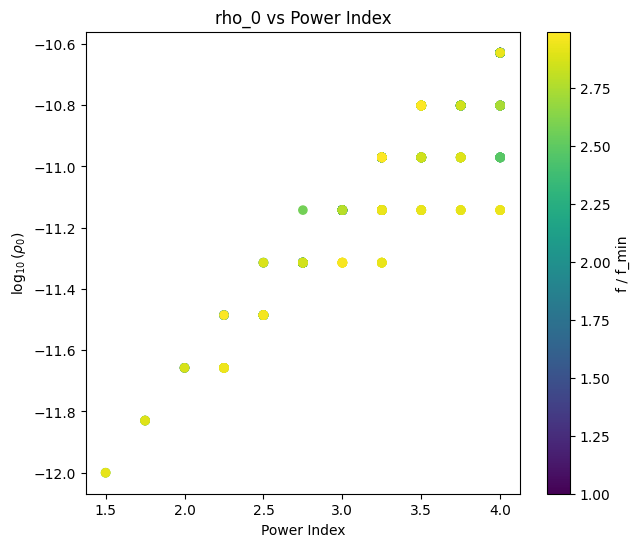

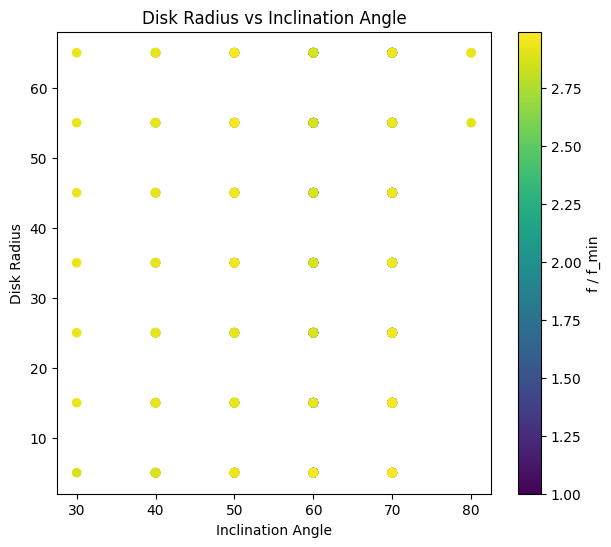

In [26]:
pairs = [
    ("Disk Radius", "rho_0"),
    ("Inclination Angle", "rho_0"),
    ("Power Index", "Disk Radius"),
    ("Power Index", "rho_0"),
    ("Inclination Angle", "Disk Radius"),
]

for x, y in pairs:
    plt.figure(figsize=(7,6))

    yvals = np.log10(accepted[y]) if y == "rho_0" else accepted[y]

    sc = plt.scatter(
        accepted[x],
        yvals,
        c=accepted["f_rel"],
        s=35
    )

    plt.colorbar(sc, label="f / f_min")
    plt.xlabel(x)
    plt.ylabel(r"$\log_{10}(\rho_0)$" if y == "rho_0" else y)
    plt.title(f"{y} vs {x}")
    plt.show()

In [27]:
summary_stats = accepted[params].copy()
summary_stats["log_rho_0"] = np.log10(accepted["rho_0"])

summary_stats[
    ["Mass", "Power Index", "log_rho_0", "Disk Radius", "Inclination Angle"]
].quantile([0.16, 0.50, 0.84])

,Mass,Power Index,log_rho_0,Disk Radius,Inclination Angle
0.16,8.0,2.75,-11.314258,5.0,50.0
0.50,10.0,3.50,-10.970616,35.0,60.0
0.84,13.9,4.00,-10.801343,55.0,70.0


In [28]:
accepted.sort_values("fom").head(50)[
    [
        "model",
        "fom",
        "f_rel",
        "Mass",
        "Power Index",
        "rho_0",
        "Disk Radius",
        "Inclination Angle",
        "velocity_shift_kms"
    ]
]

,model,fom,f_rel,Mass,Power Index,rho_0,Disk Radius,Inclination Angle,velocity_shift_kms
0,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.614552,1.000000,9.0,4.00,2.350000e-11,15.0,60.0,60.099066
1,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.615956,1.002284,9.0,4.00,2.350000e-11,25.0,60.0,60.133514
2,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.616125,1.002559,9.0,4.00,2.350000e-11,35.0,60.0,60.145192
3,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.616194,1.002672,9.0,4.00,2.350000e-11,45.0,60.0,60.145679
4,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.616256,1.002773,9.0,4.00,2.350000e-11,65.0,60.0,60.149098
5,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.616256,1.002773,9.0,4.00,2.350000e-11,55.0,60.0,60.149098
6,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.710422,1.155999,9.0,4.00,2.350000e-11,5.0,60.0,57.869858
7,/Users/joshuamarine/Downloads/Model Spectra/M1...,0.711127,1.157146,10.0,3.00,7.200000e-12,5.0,60.0,57.575159
8,/Users/joshuamarine/Downloads/Model Spectra/M1...,0.745811,1.213584,10.0,4.00,2.350000e-11,5.0,60.0,57.932947
9,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.795857,1.295019,9.0,3.00,7.200000e-12,5.0,60.0,57.774865


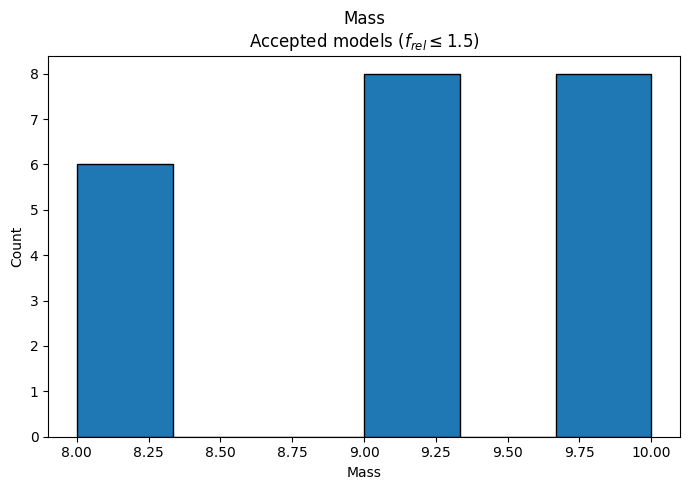

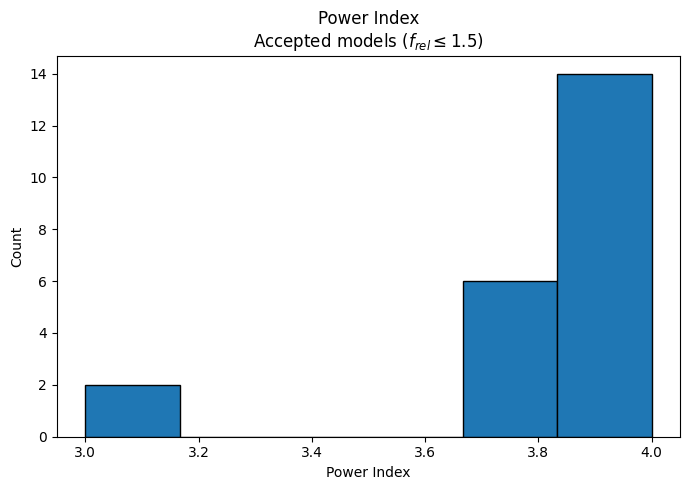

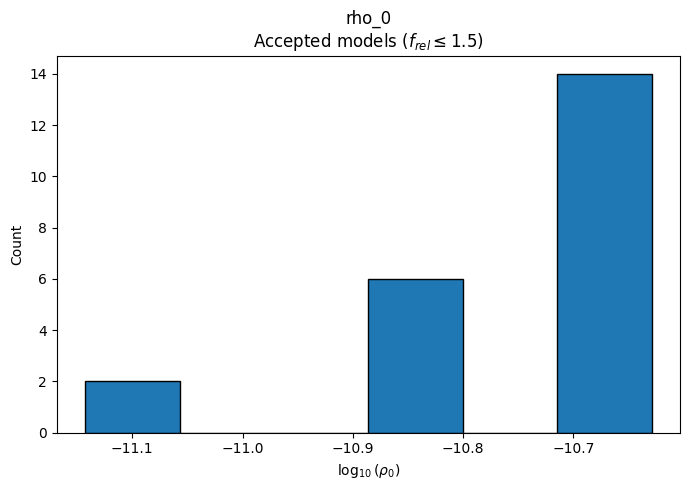

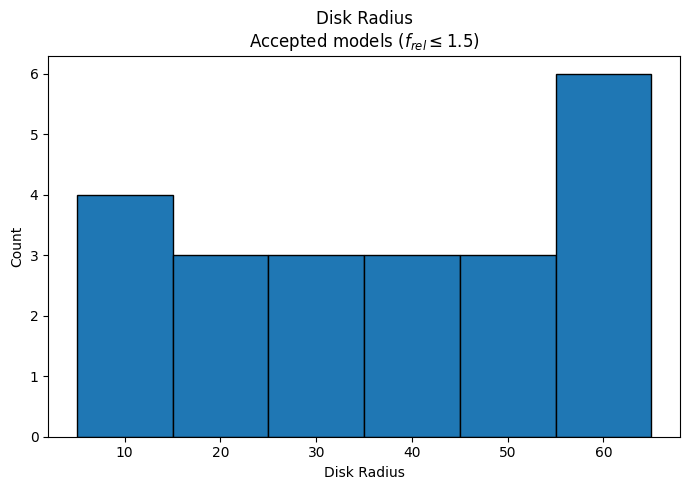

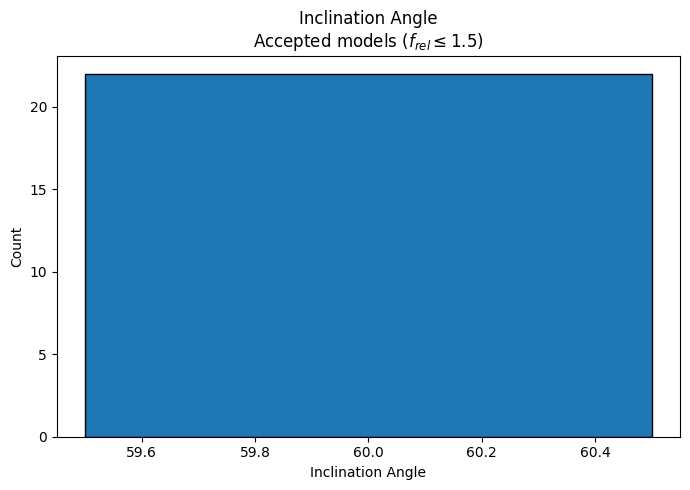

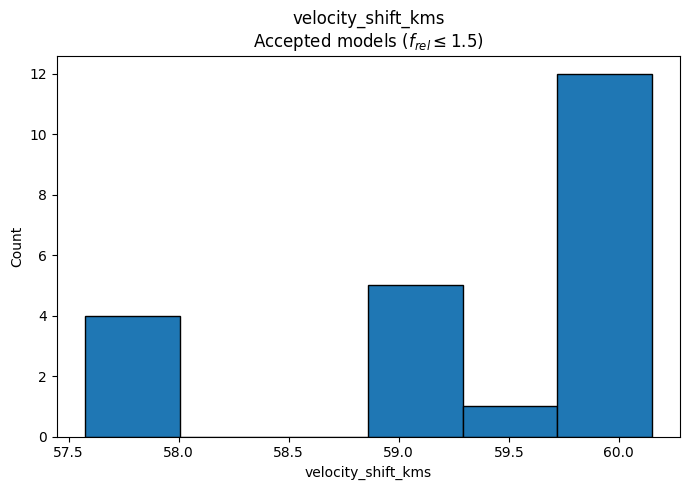

In [ ]:
plot_parameter_diagnostics(results, accepted_fom=1.15)

# Run for all spectra in list

In [66]:
# models_dir = '/content/drive/MyDrive/SP25-PHYS491/groups/alcyone/Model Spectra'
models_dir = os.path.expanduser('~/Downloads/Model Spectra')


mass = ['8p0', '9p0', '10p0']

# power_index = ['1d50', '1d75', '2d00']
# rho_0 = ['*']
# R_disk = ['5p0','15p0', '25p0', '35p0']
inclination_angle = ['50', '60', '70']

# mass = ['*']
power_index = ['*']
rho_0 = ['*']
R_disk = ['5p0', '15p0', '25p0']
# inclination_angle = ['*']


filters = []
for m in mass:
  for n in power_index:
    for rho in rho_0:
      for r in R_disk:
        for i in inclination_angle:
          filters.append(f'{models_dir}/*{m}*/SPEC.*{n}_{rho}_rd{r}_*i{i}')


models = []
for filter in filters:
  models.extend(glob.glob(filter))
print(f'Found {len(models)} model files')

# Sort models by inclination angle:
models.sort(key=get_angle)

for model in models:
    print(model)

Found 4455 model files
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_1d75_3d27em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d50_1d07em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d00_1d07em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d25_7d20em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d75_7d20em12_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_4d00_3d49em11_rd5p0_halpha_alp0p0_i50
/Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_1d50_1d14em10_rd5p0_halpha_alp0p0_i50
/Users/josh

In [67]:
all_results, all_bad_models = fit_all_spectra_parallel(
    stacked_norm,
    models,
    fwhm=fwhm,
    max_workers=None,
    core_weighted=True,
    velocity_guess_kms=60.0,
    velocity_tolerance_kms=100.0,
    fit_velocity=True,
    fit_window=40.0,
    model_center=6562.8,
    verbose = 1
)

Spectra Completed:   0%|          | 0/37 [00:00<?, ?spec/s]

Total Models Fit:   0%|          | 0/164835 [00:00<?, ?model/s]

In [68]:
print(type(all_results))

all_results.keys()

<class 'pandas.core.frame.DataFrame'>


Index(['spectrum_id', 'fwhm', 'model', 'model_index', 'fom',
       'velocity_shift_kms', 'lambda_shift_A', 'Mass', 'Power Index', 'rho_0',
       'Disk Radius', 'Inclination Angle', 'Radius', 'Equivalent Width',
       'Rotational Velocity', 'T_eff', 'f_rel'],
      dtype='object')

In [69]:
summary = (
    all_results
    .sort_values("fom")
    .groupby("spectrum_id", as_index=False)
    .first()
)

summary = summary[
    [
        "spectrum_id",
        "model",
        "fom",
        "velocity_shift_kms",
        "lambda_shift_A",
        "Mass",
        "Power Index",
        "rho_0",
        "Disk Radius",
        "Inclination Angle",
        "Equivalent Width",
        "f_rel"
    ]
]

summary

,spectrum_id,model,fom,velocity_shift_kms,lambda_shift_A,Mass,Power Index,rho_0,Disk Radius,Inclination Angle,Equivalent Width,f_rel
0,2025-11-14,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.614552,60.099066,1.315637,9.0,4.00,2.350000e-11,15.0,60.0,-0.95,1.0
1,2025-11-21,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.592231,57.907033,1.267651,9.0,3.75,1.580000e-11,25.0,60.0,-1.14,1.0
2,2025-11-24,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.561315,64.741220,1.417259,9.0,4.00,1.580000e-11,25.0,50.0,-1.40,1.0
3,2025-11-25,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.533279,62.364897,1.365239,9.0,4.00,1.580000e-11,5.0,50.0,-1.47,1.0
4,2025-11-27,/Users/joshuamarine/Downloads/Model Spectra/M1...,0.443761,56.499565,1.236840,10.0,3.00,4.850000e-12,5.0,50.0,-1.42,1.0
5,2025-12-01,/Users/joshuamarine/Downloads/Model Spectra/M1...,0.567102,62.640538,1.371273,10.0,2.75,3.270000e-12,5.0,50.0,-1.63,1.0
6,2025-12-03,/Users/joshuamarine/Downloads/Model Spectra/M9...,0.490455,70.883683,1.551725,9.0,2.75,3.270000e-12,5.0,50.0,-1.86,1.0
7,2025-12-07,/Users/joshuamarine/Downloads/Model Spectra/M8...,0.491828,68.294111,1.495036,8.0,3.25,4.850000e-12,25.0,50.0,-2.17,1.0
8,2025-12-08,/Users/joshuamarine/Downloads/Model Spectra/M8...,0.490213,64.965572,1.422171,8.0,3.25,4.850000e-12,25.0,50.0,-2.17,1.0
9,2025-12-09,/Users/joshuamarine/Downloads/Model Spectra/M8...,0.486861,68.594283,1.501607,8.0,3.25,4.850000e-12,25.0,50.0,-2.17,1.0


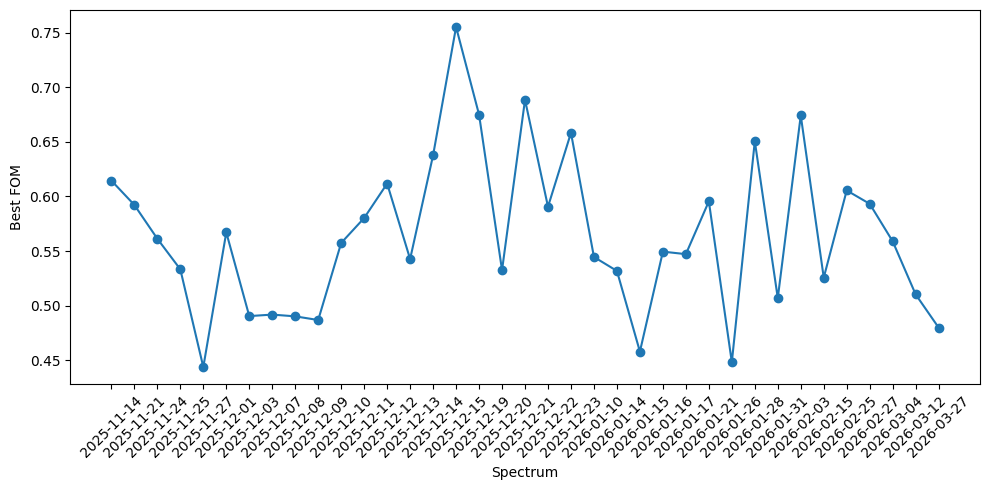

In [70]:
plt.figure(figsize=(10,5))

plt.plot(summary["spectrum_id"], summary["fom"], marker="o")

plt.xticks(rotation=45)
plt.xlabel("Spectrum")
plt.ylabel("Best FOM")
plt.tight_layout()
plt.show()

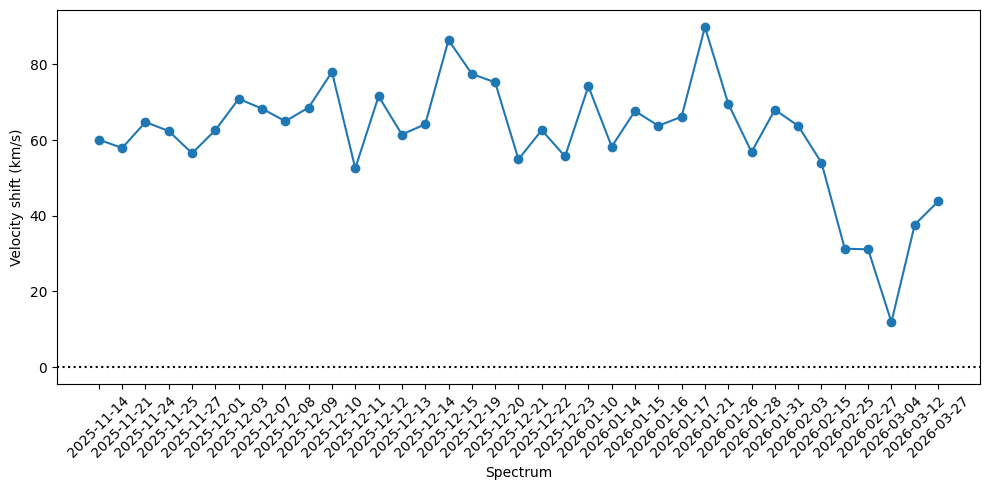

In [71]:
plt.figure(figsize=(10,5))

plt.plot(summary["spectrum_id"], summary["velocity_shift_kms"], marker="o")
plt.axhline(0, color="k", linestyle=":")

plt.xticks(rotation=45)
plt.xlabel("Spectrum")
plt.ylabel("Velocity shift (km/s)")
plt.tight_layout()
plt.show()

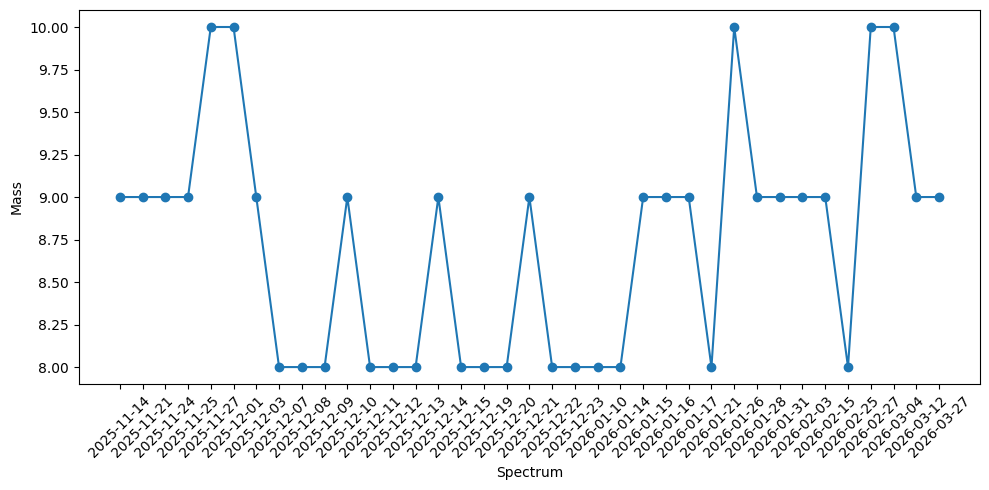

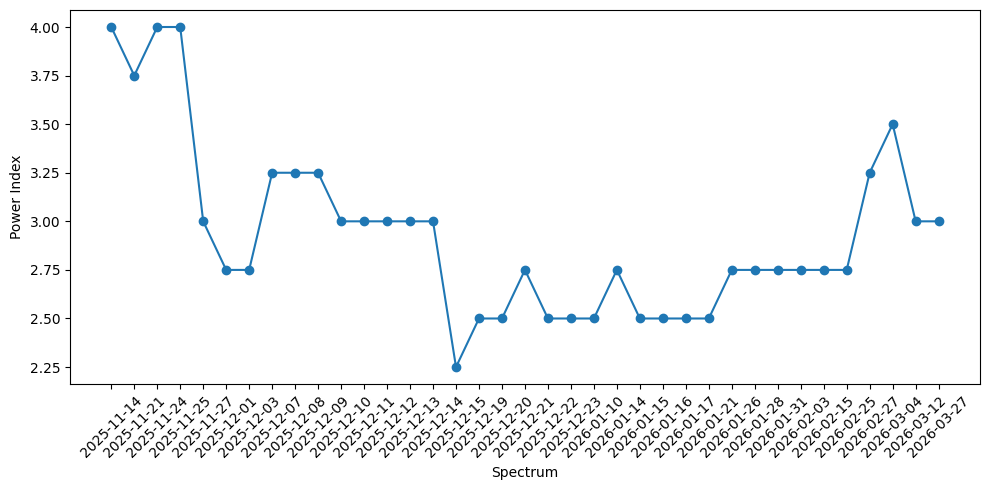

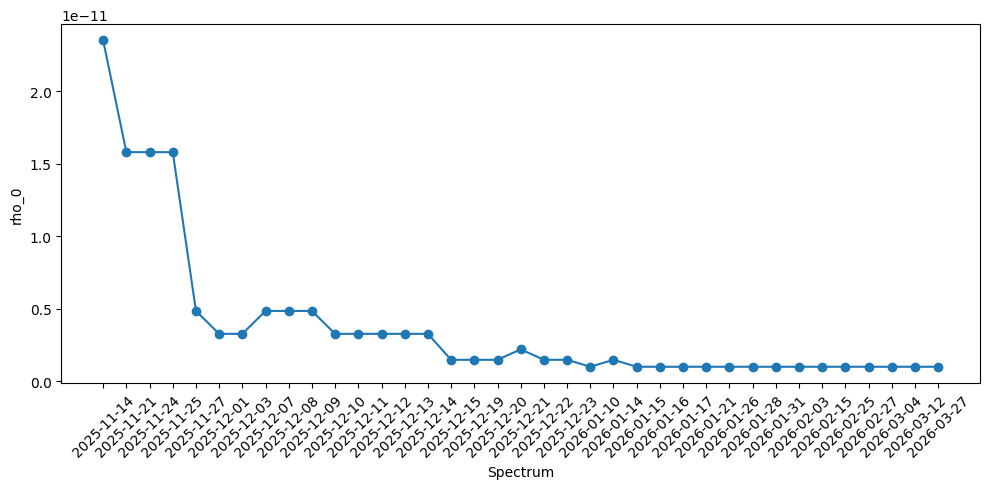

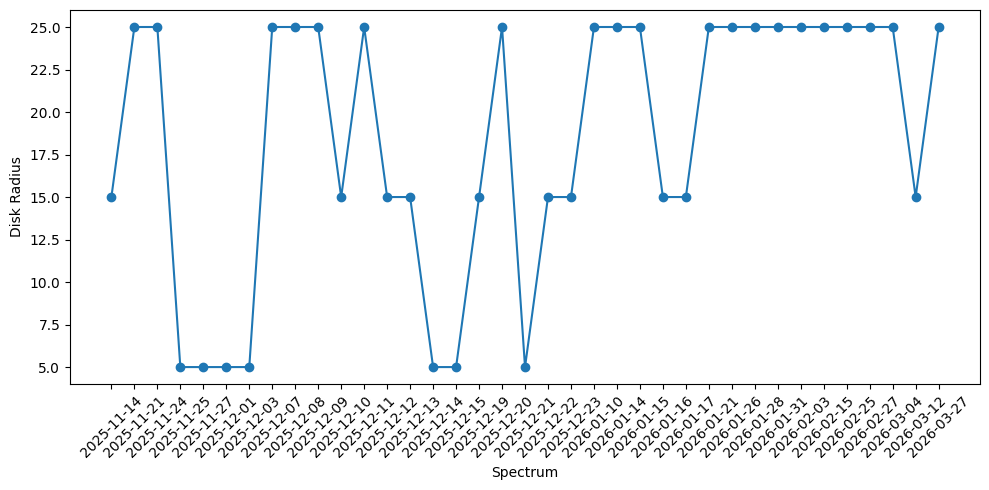

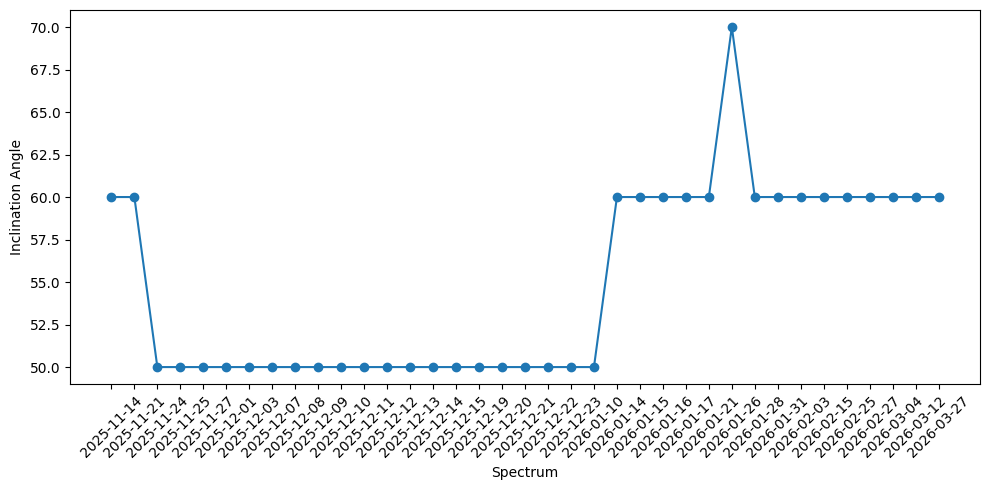

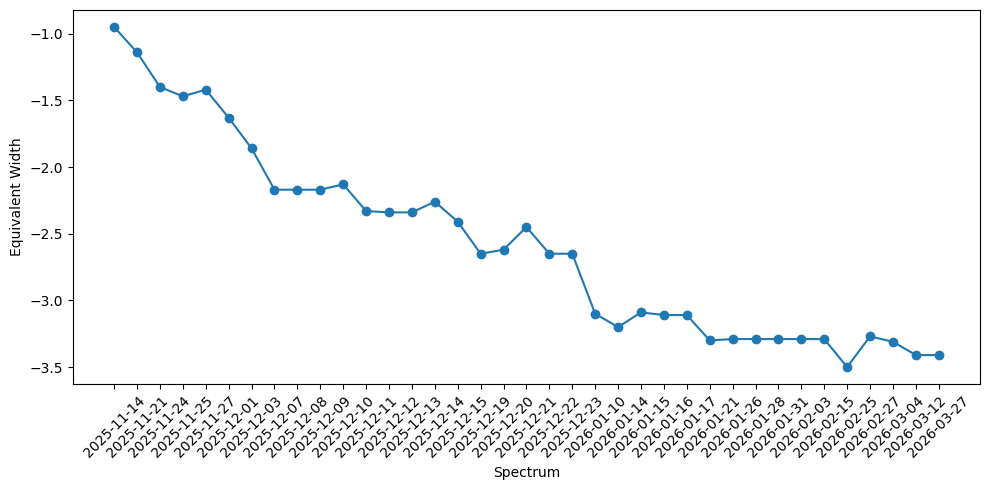

In [72]:
for col in ["Mass", "Power Index", "rho_0", "Disk Radius", "Inclination Angle", "Equivalent Width"]:
    plt.figure(figsize=(10,5))
    plt.plot(summary["spectrum_id"], summary[col], marker="o")
    plt.xticks(rotation=45)
    plt.xlabel("Spectrum")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

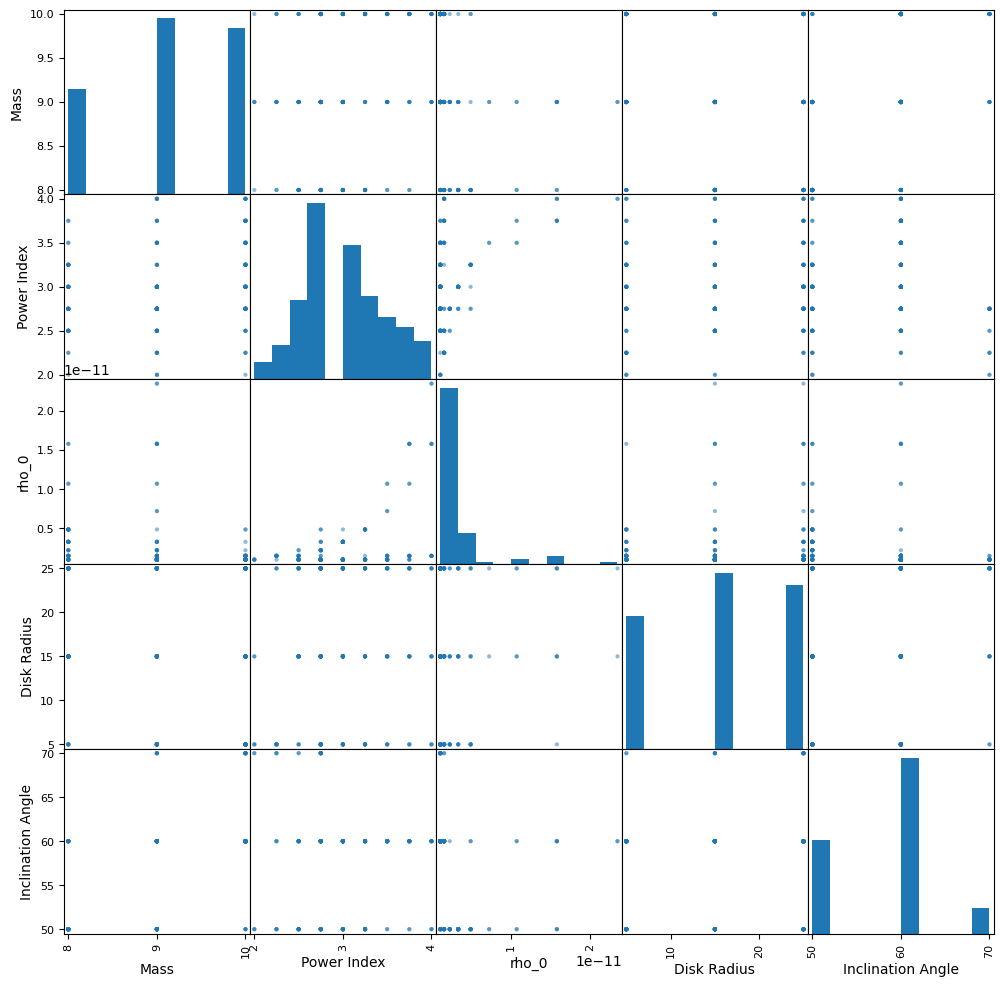

In [73]:
accepted = all_results[all_results["f_rel"] <= 1.15]

cols = [
    "Mass",
    "Power Index",
    "rho_0",
    "Disk Radius",
    "Inclination Angle"
]

pd.plotting.scatter_matrix(
    accepted[cols],
    figsize=(12,12),
    diagonal="hist"
)

plt.show()

Plotting 2025-11-14
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_4d00_2d35em11_rd15p0_halpha_alp0p0_i60
FOM: 0.615
Velocity shift: 60.10 km/s


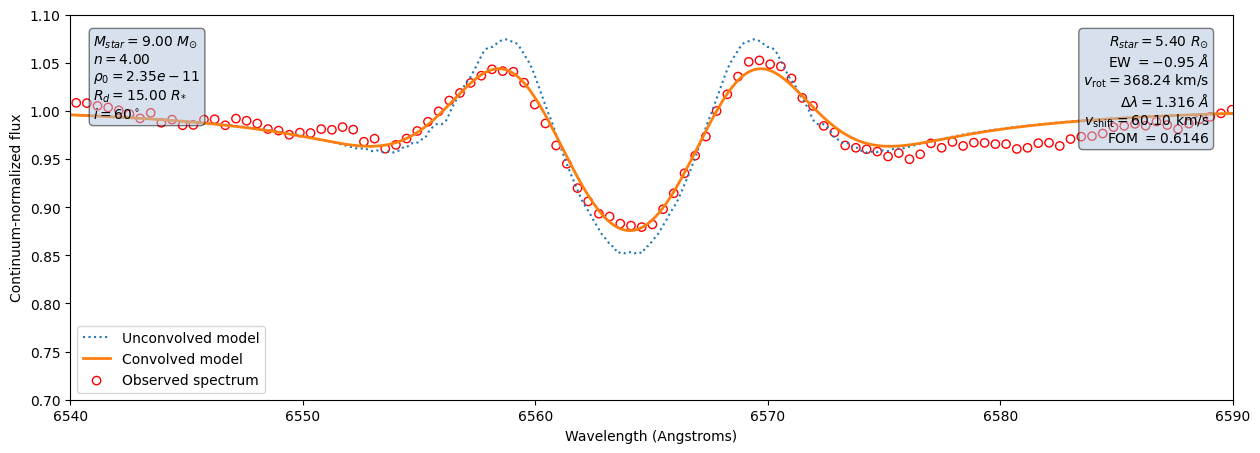

Plotting 2025-11-21
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_3d75_1d58em11_rd25p0_halpha_alp0p0_i60
FOM: 0.592
Velocity shift: 57.91 km/s


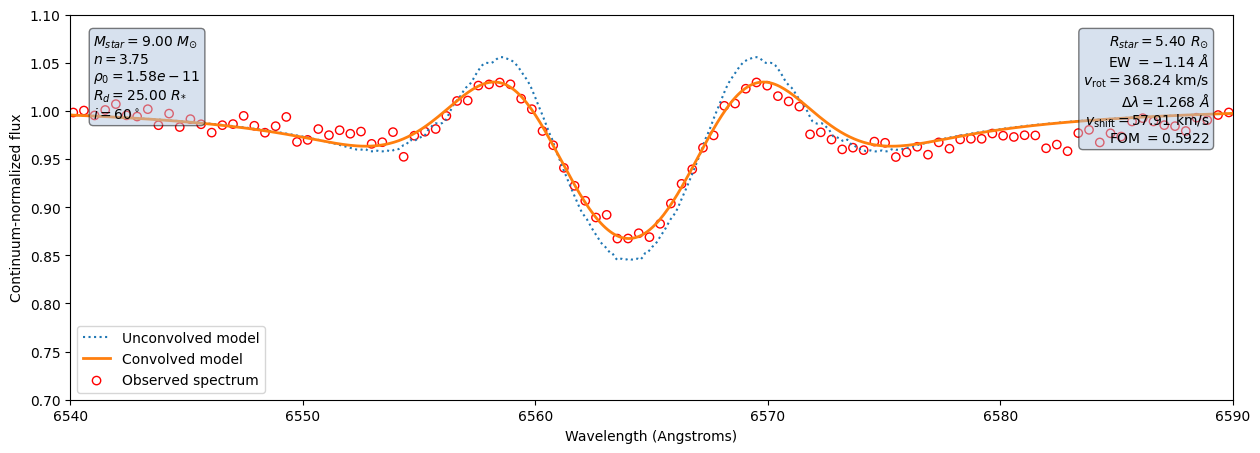

Plotting 2025-11-24
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_4d00_1d58em11_rd25p0_halpha_alp0p0_i50
FOM: 0.561
Velocity shift: 64.74 km/s


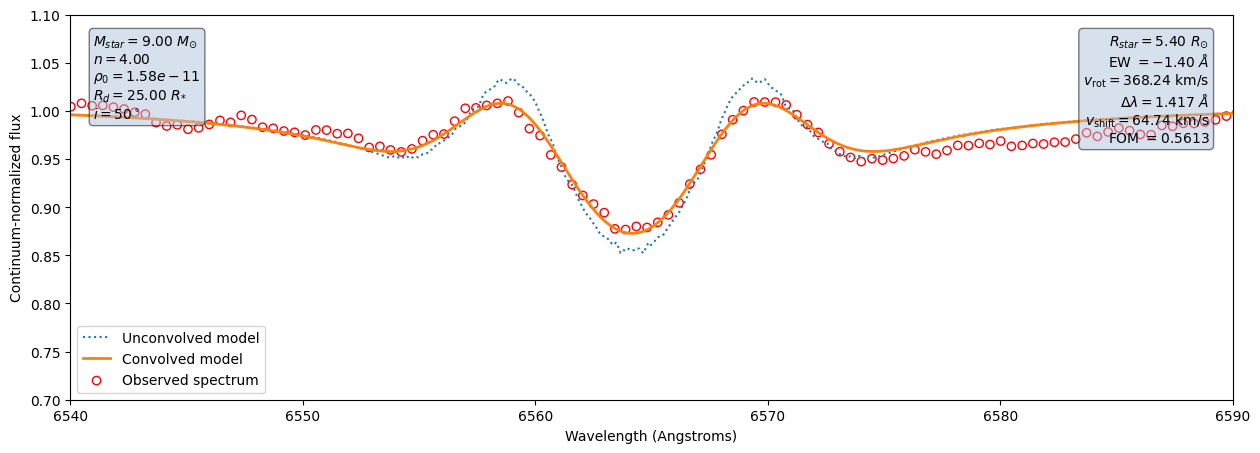

Plotting 2025-11-25
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_4d00_1d58em11_rd5p0_halpha_alp0p0_i50
FOM: 0.533
Velocity shift: 62.36 km/s


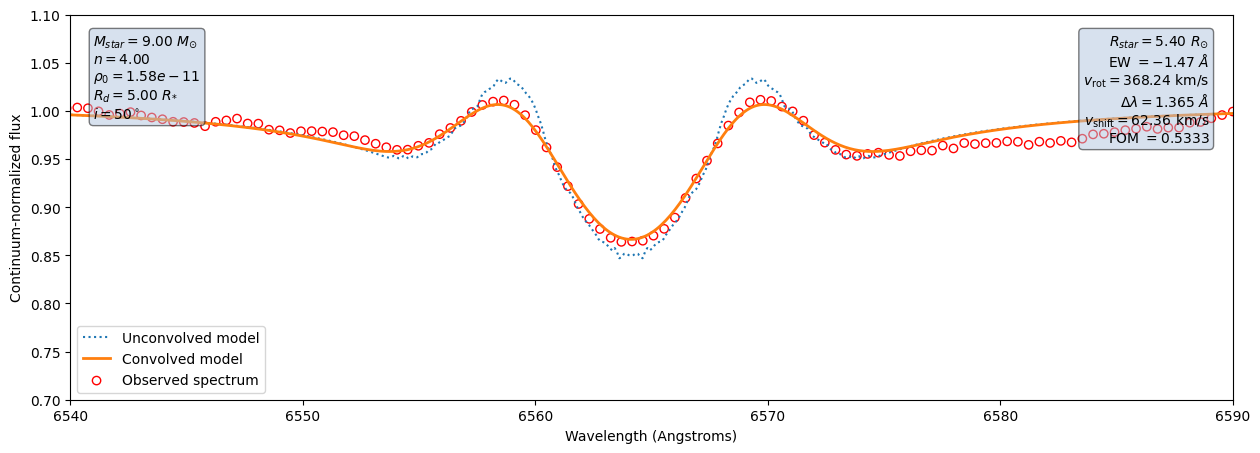

Plotting 2025-11-27
Best model: /Users/joshuamarine/Downloads/Model Spectra/M10p0V0p0z0p0X0p3/SPEC.M10p0V0p0z0p0X0p3_t14040_w0d0_j0h0_3d00_4d85em12_rd5p0_halpha_alp0p0_i50
FOM: 0.444
Velocity shift: 56.50 km/s


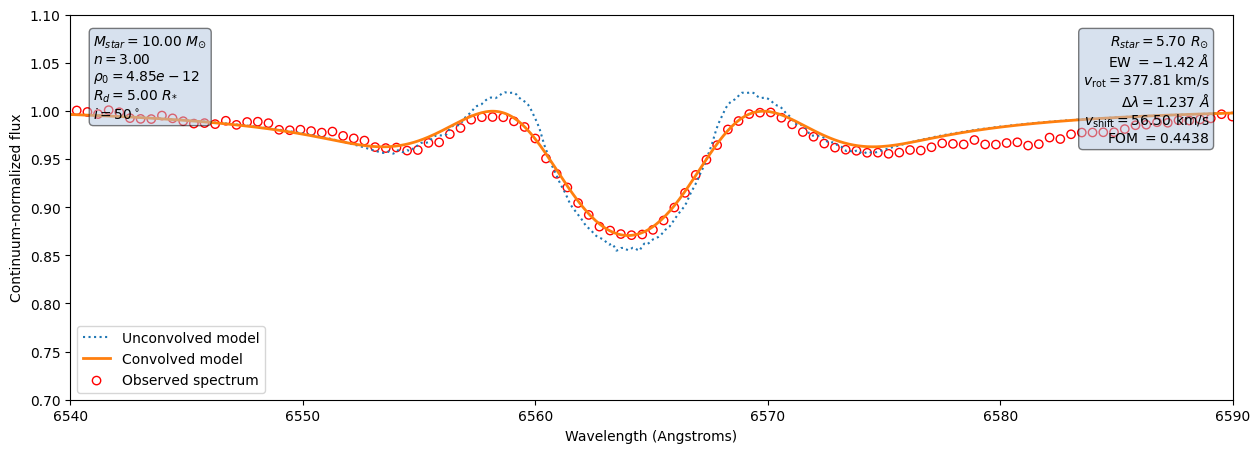

Plotting 2025-12-01
Best model: /Users/joshuamarine/Downloads/Model Spectra/M10p0V0p0z0p0X0p3/SPEC.M10p0V0p0z0p0X0p3_t14040_w0d0_j0h0_2d75_3d27em12_rd5p0_halpha_alp0p0_i50
FOM: 0.567
Velocity shift: 62.64 km/s


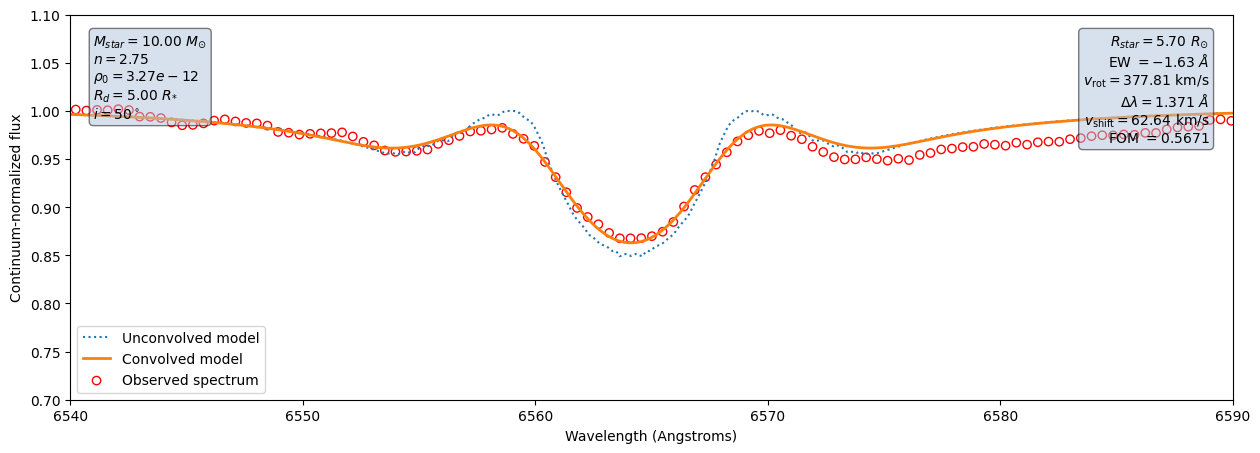

Plotting 2025-12-03
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_3d27em12_rd5p0_halpha_alp0p0_i50
FOM: 0.490
Velocity shift: 70.88 km/s


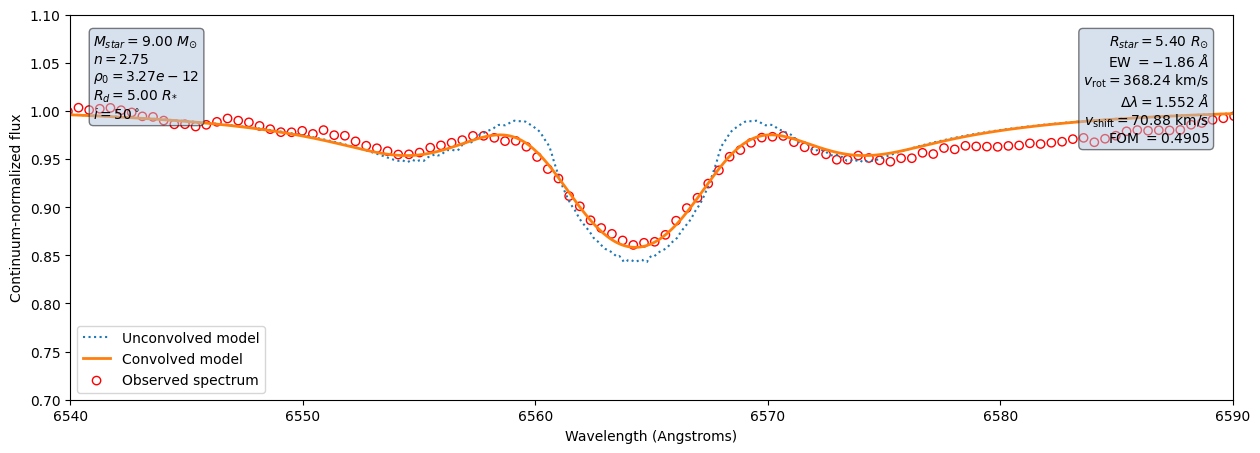

Plotting 2025-12-07
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d25_4d85em12_rd25p0_halpha_alp0p0_i50
FOM: 0.492
Velocity shift: 68.29 km/s


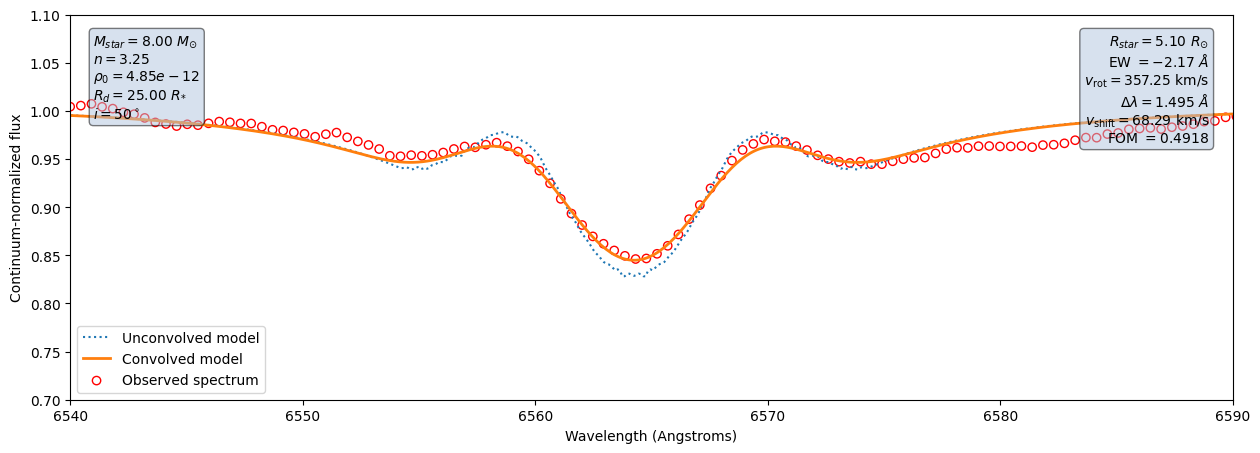

Plotting 2025-12-08
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d25_4d85em12_rd25p0_halpha_alp0p0_i50
FOM: 0.490
Velocity shift: 64.97 km/s


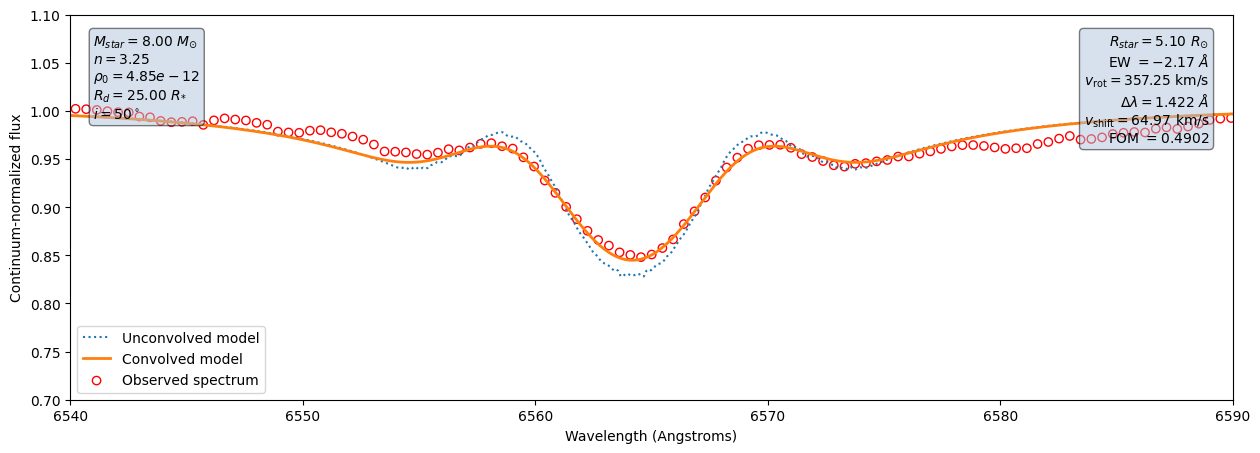

Plotting 2025-12-09
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d25_4d85em12_rd25p0_halpha_alp0p0_i50
FOM: 0.487
Velocity shift: 68.59 km/s


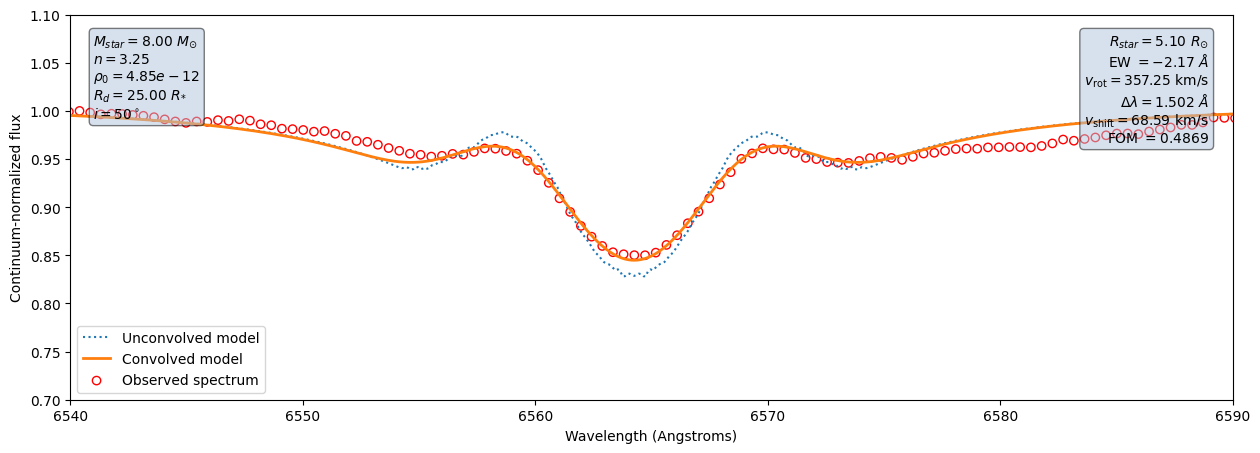

Plotting 2025-12-10
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_3d00_3d27em12_rd15p0_halpha_alp0p0_i50
FOM: 0.557
Velocity shift: 77.98 km/s


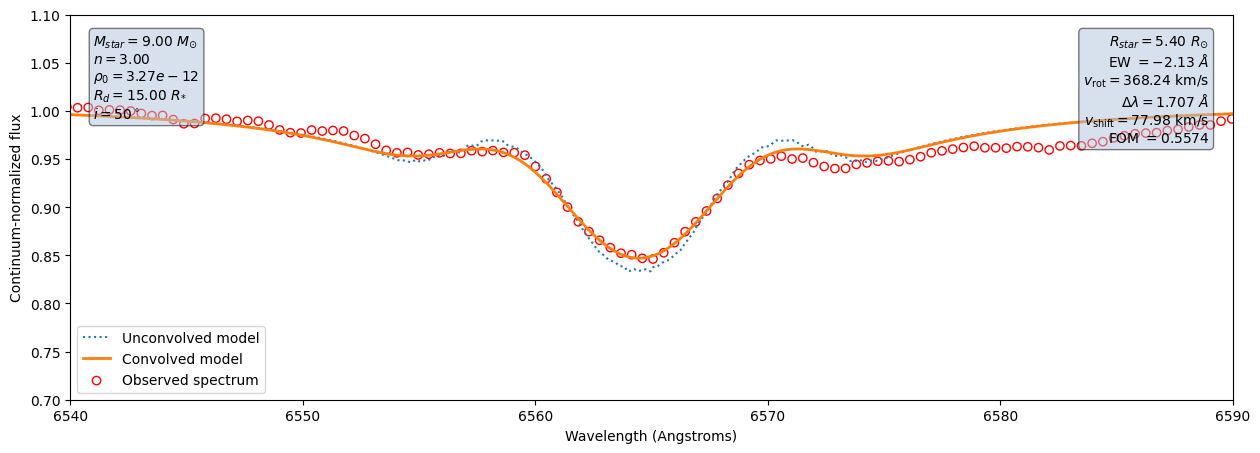

Plotting 2025-12-11
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d00_3d27em12_rd25p0_halpha_alp0p0_i50
FOM: 0.580
Velocity shift: 52.52 km/s


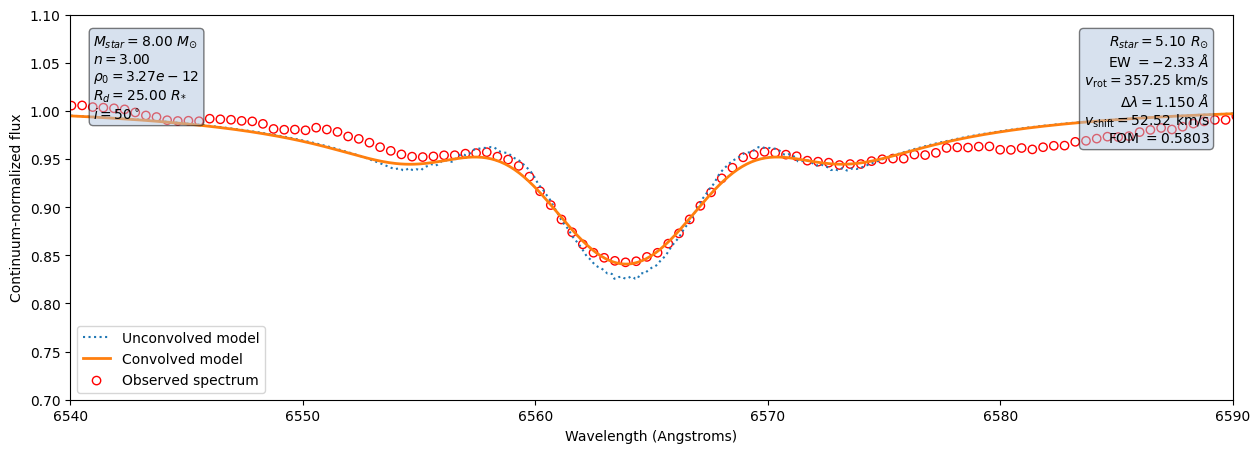

Plotting 2025-12-12
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d00_3d27em12_rd15p0_halpha_alp0p0_i50
FOM: 0.612
Velocity shift: 71.57 km/s


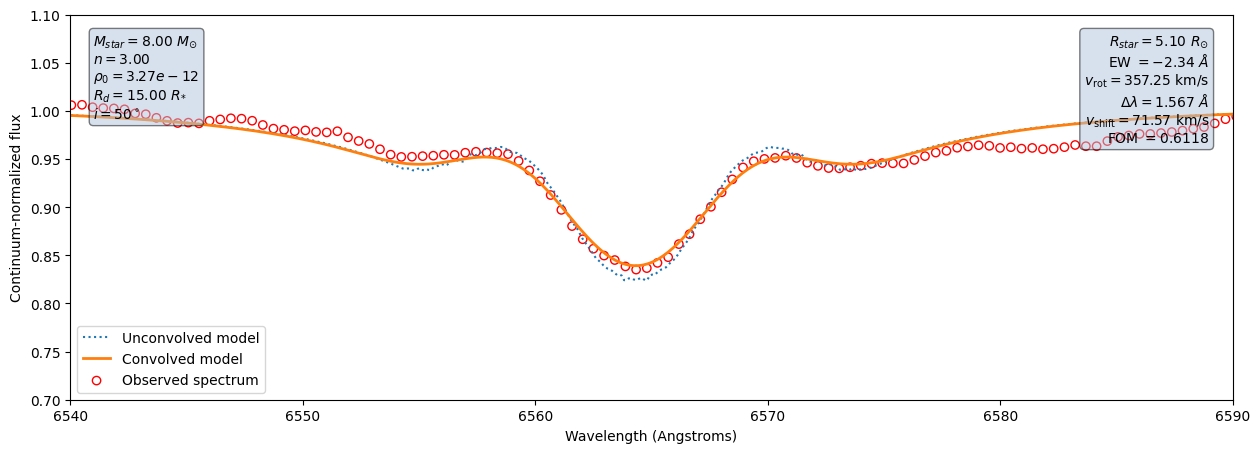

Plotting 2025-12-13
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_3d00_3d27em12_rd15p0_halpha_alp0p0_i50
FOM: 0.543
Velocity shift: 61.45 km/s


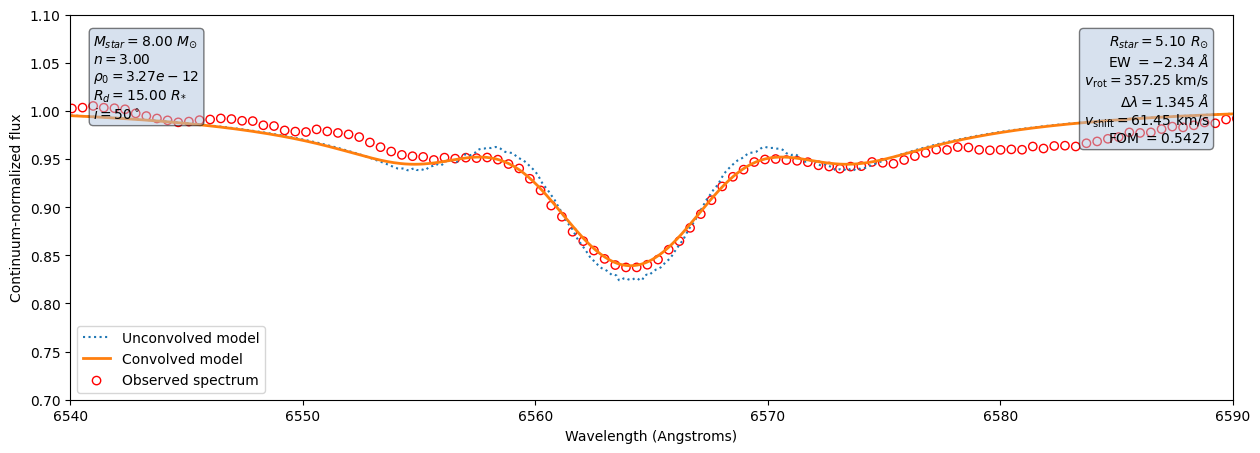

Plotting 2025-12-14
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_3d00_3d27em12_rd5p0_halpha_alp0p0_i50
FOM: 0.638
Velocity shift: 64.17 km/s


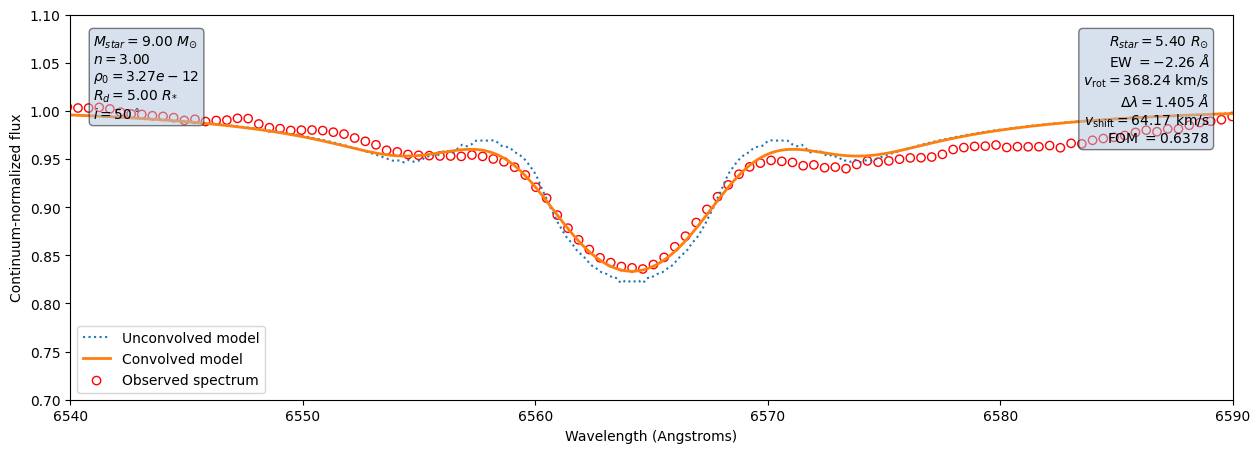

Plotting 2025-12-15
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d25_1d48em12_rd5p0_halpha_alp0p0_i50
FOM: 0.755
Velocity shift: 86.43 km/s


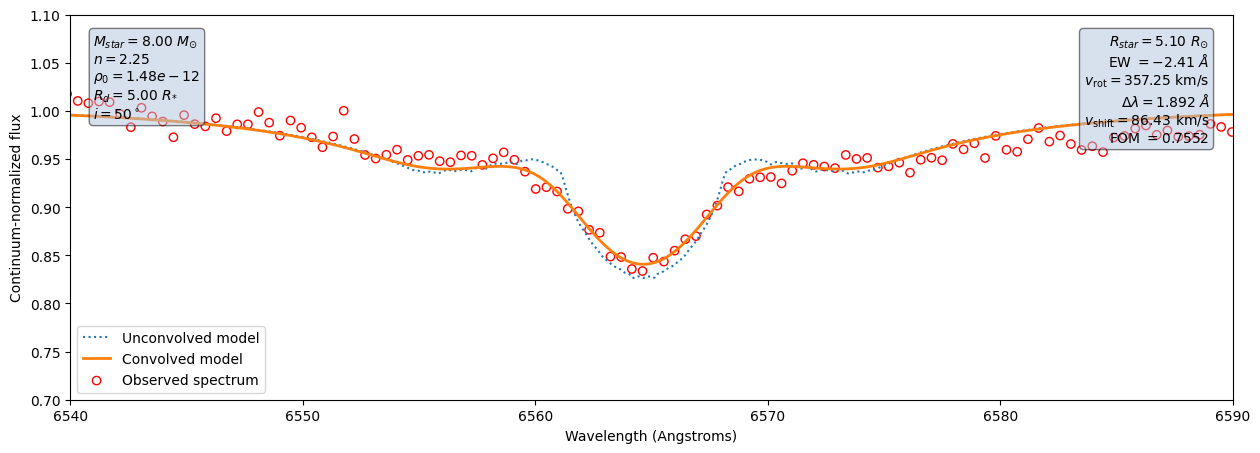

Plotting 2025-12-19
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d48em12_rd15p0_halpha_alp0p0_i50
FOM: 0.675
Velocity shift: 77.46 km/s


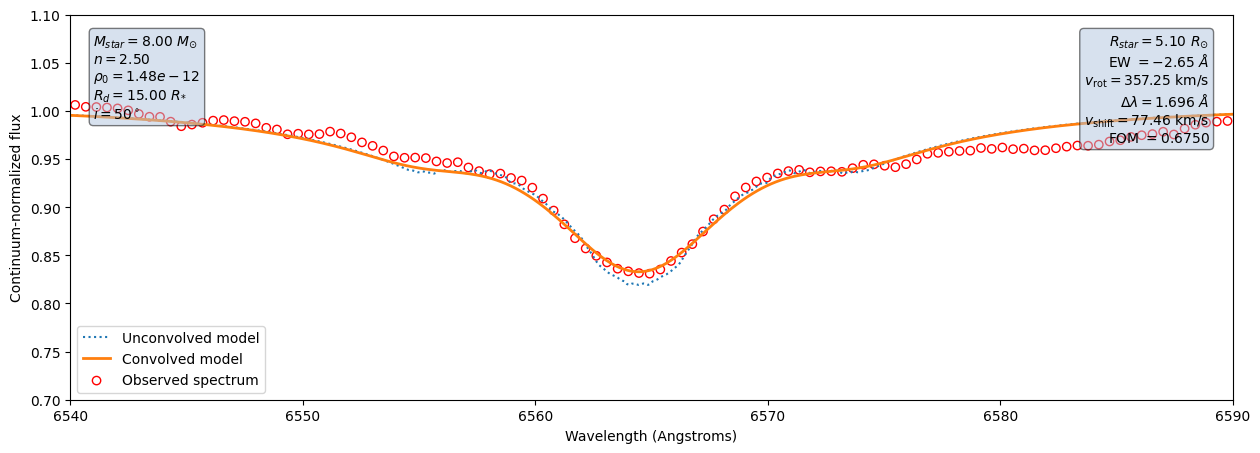

Plotting 2025-12-20
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d48em12_rd25p0_halpha_alp0p0_i50
FOM: 0.533
Velocity shift: 75.25 km/s


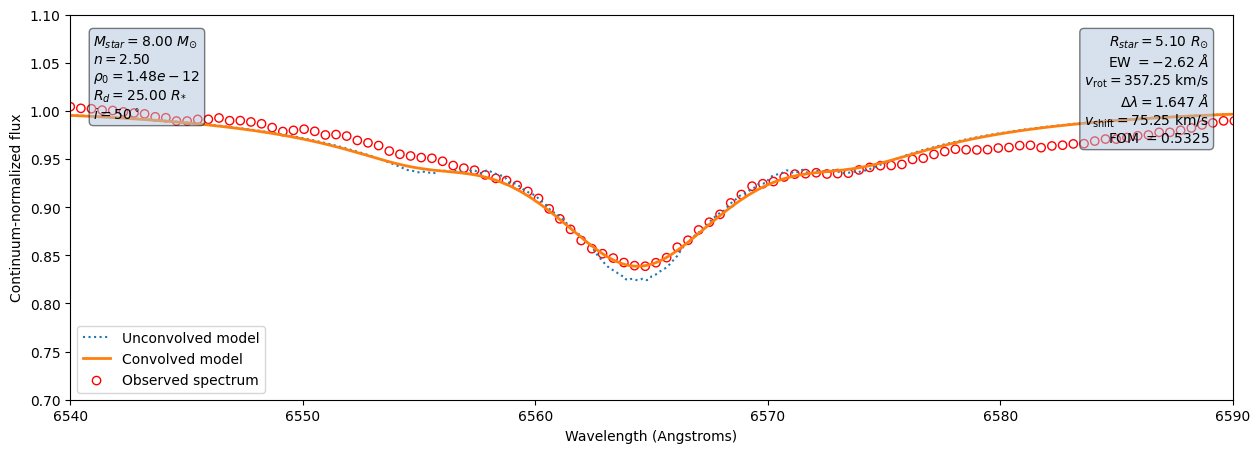

Plotting 2025-12-21
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_2d20em12_rd5p0_halpha_alp0p0_i50
FOM: 0.689
Velocity shift: 54.90 km/s


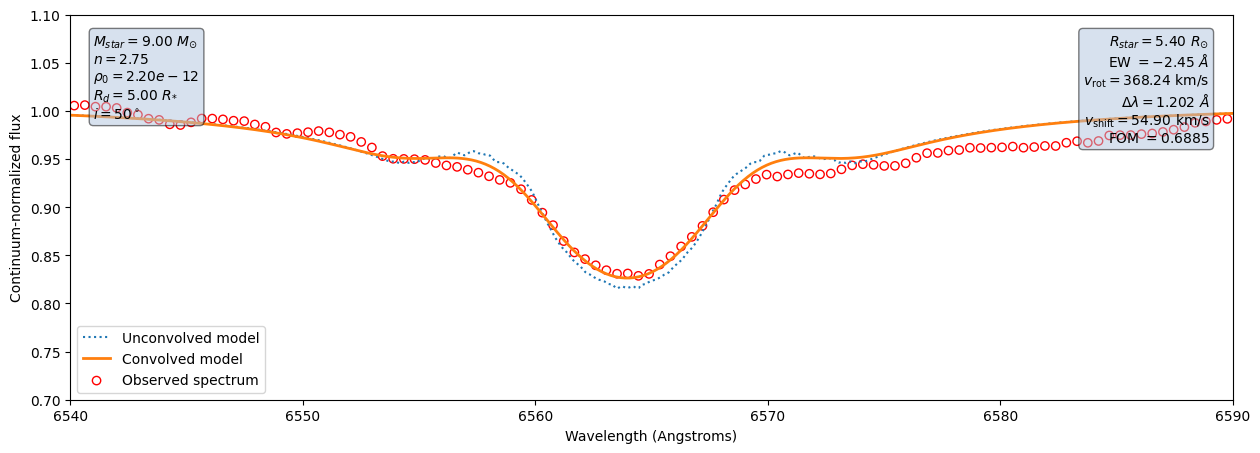

Plotting 2025-12-22
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d48em12_rd15p0_halpha_alp0p0_i50
FOM: 0.591
Velocity shift: 62.61 km/s


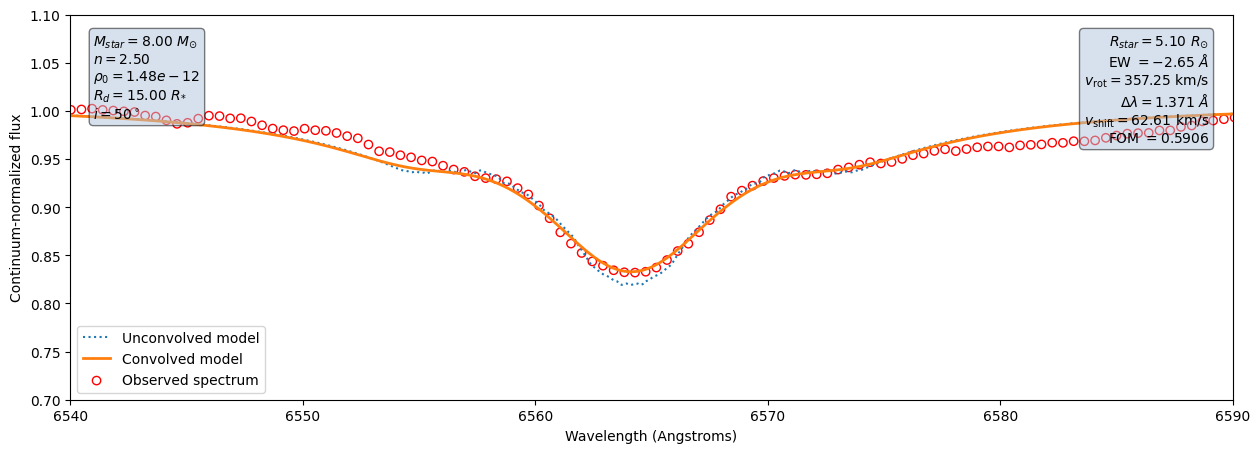

Plotting 2025-12-23
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d48em12_rd15p0_halpha_alp0p0_i50
FOM: 0.658
Velocity shift: 55.66 km/s


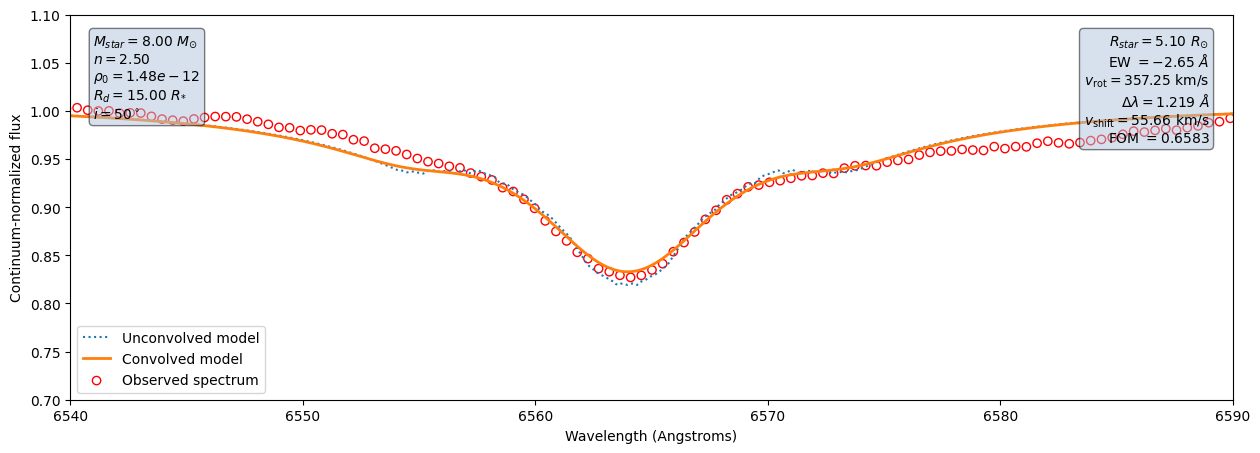

Plotting 2026-01-10
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d00em12_rd25p0_halpha_alp0p0_i50
FOM: 0.545
Velocity shift: 74.21 km/s


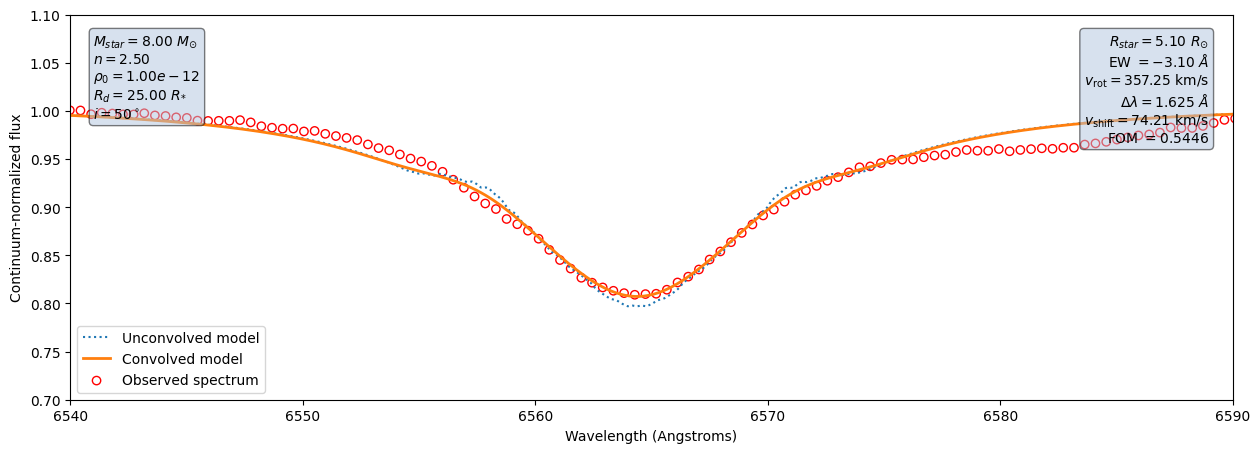

Plotting 2026-01-14
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d75_1d48em12_rd25p0_halpha_alp0p0_i60
FOM: 0.532
Velocity shift: 58.25 km/s


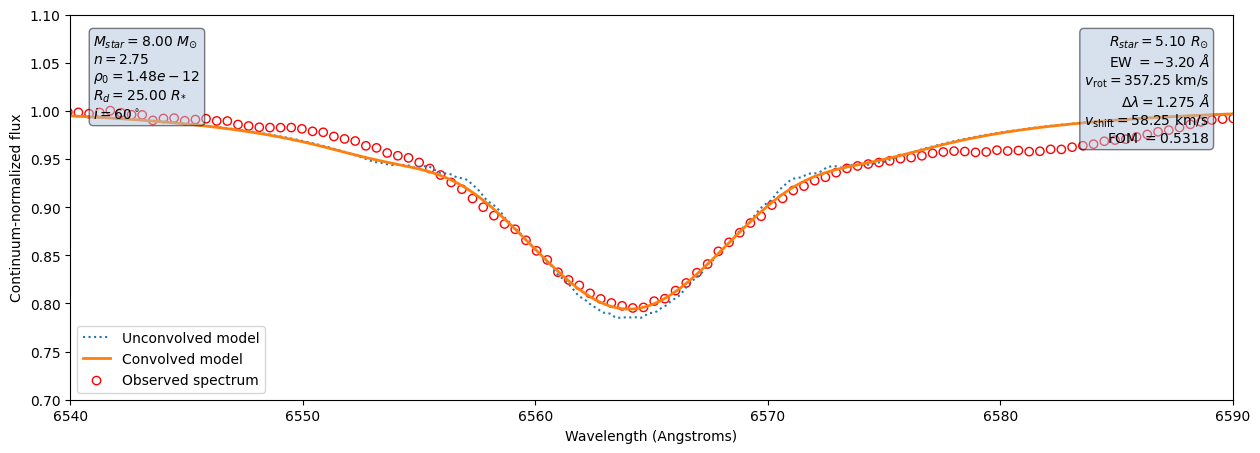

Plotting 2026-01-15
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d50_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.458
Velocity shift: 67.68 km/s


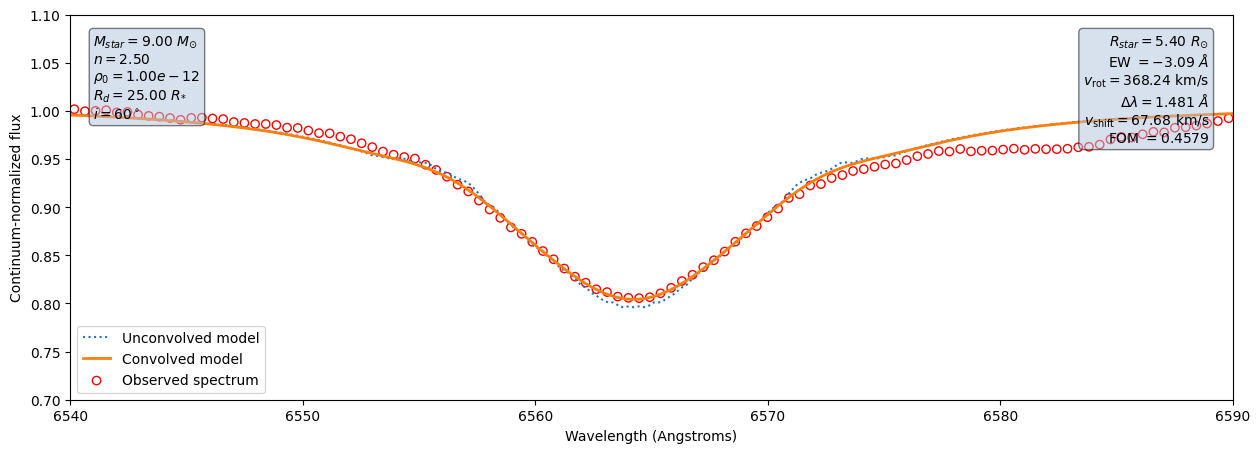

Plotting 2026-01-16
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d50_1d00em12_rd15p0_halpha_alp0p0_i60
FOM: 0.549
Velocity shift: 63.76 km/s


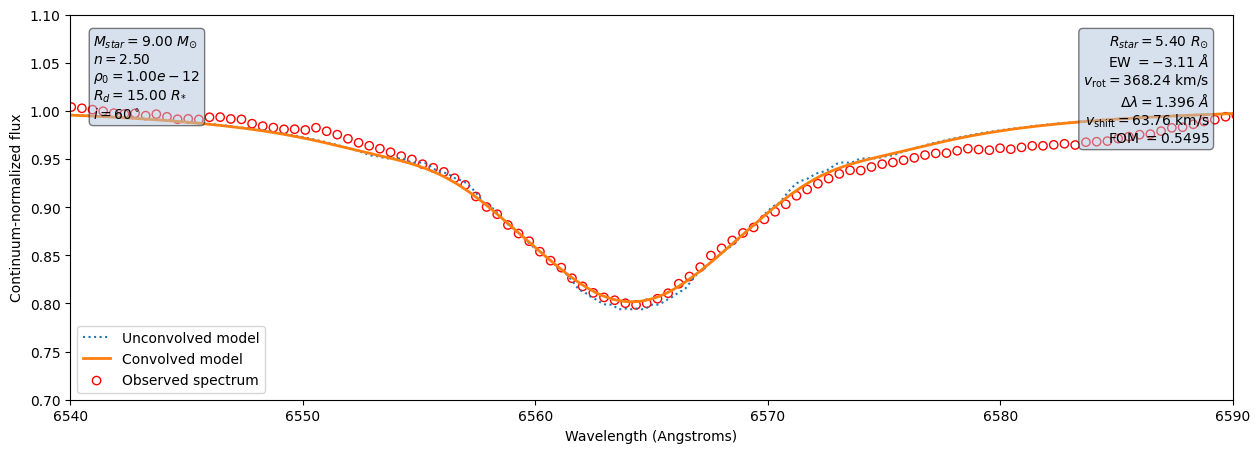

Plotting 2026-01-17
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d50_1d00em12_rd15p0_halpha_alp0p0_i60
FOM: 0.547
Velocity shift: 66.16 km/s


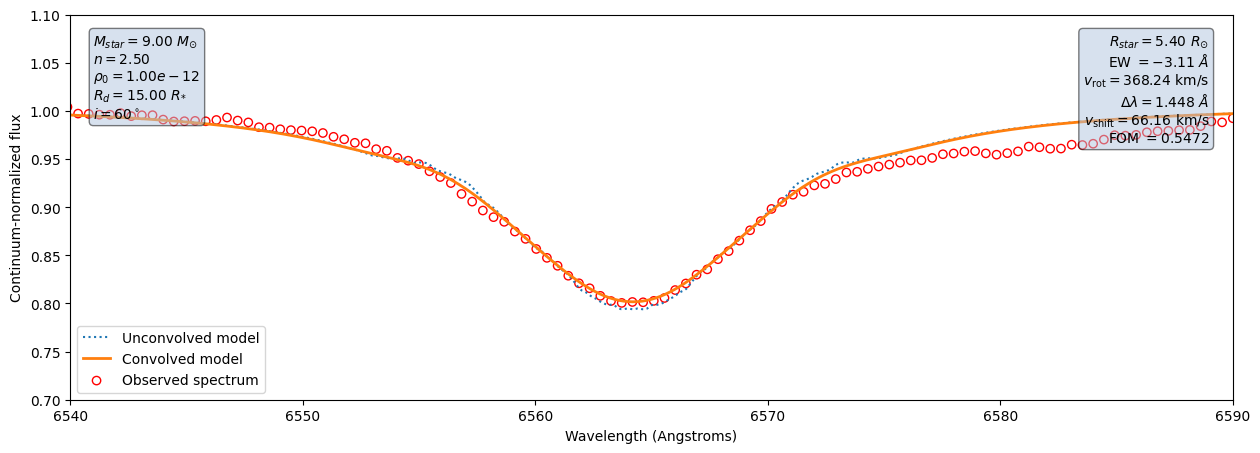

Plotting 2026-01-21
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d50_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.596
Velocity shift: 89.87 km/s


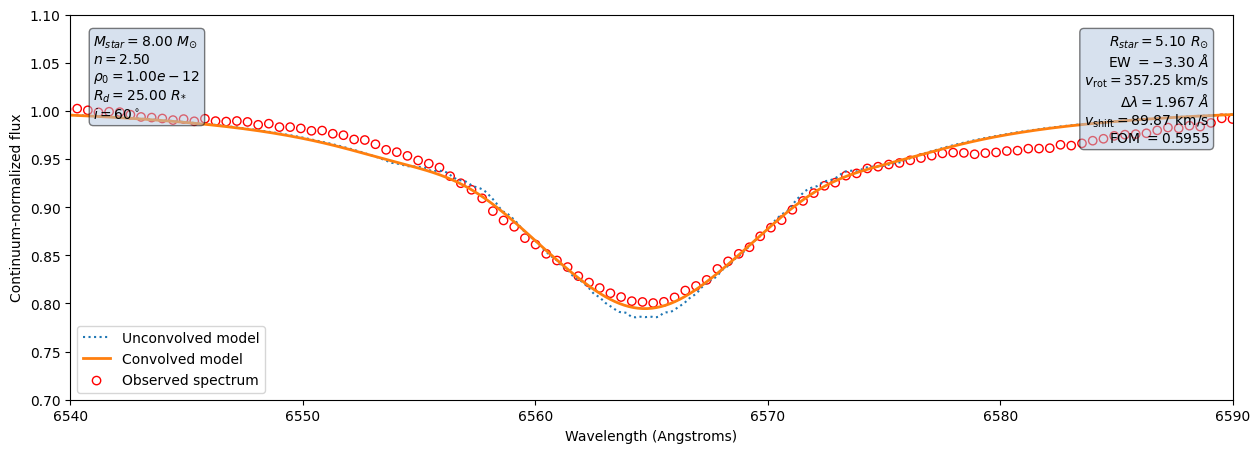

Plotting 2026-01-26
Best model: /Users/joshuamarine/Downloads/Model Spectra/M10p0V0p0z0p0X0p3/SPEC.M10p0V0p0z0p0X0p3_t14040_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i70
FOM: 0.448
Velocity shift: 69.59 km/s


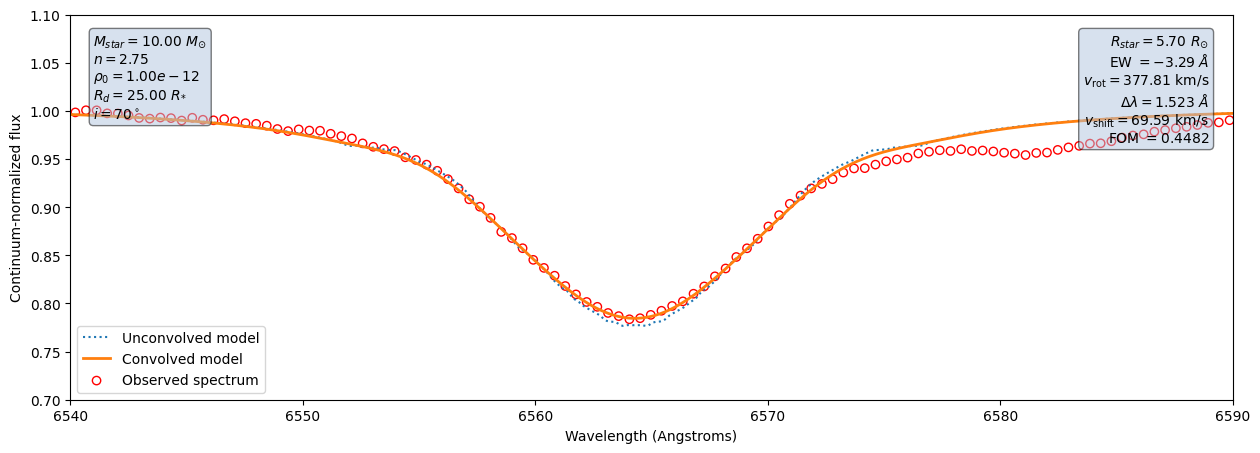

Plotting 2026-01-28
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.651
Velocity shift: 56.84 km/s


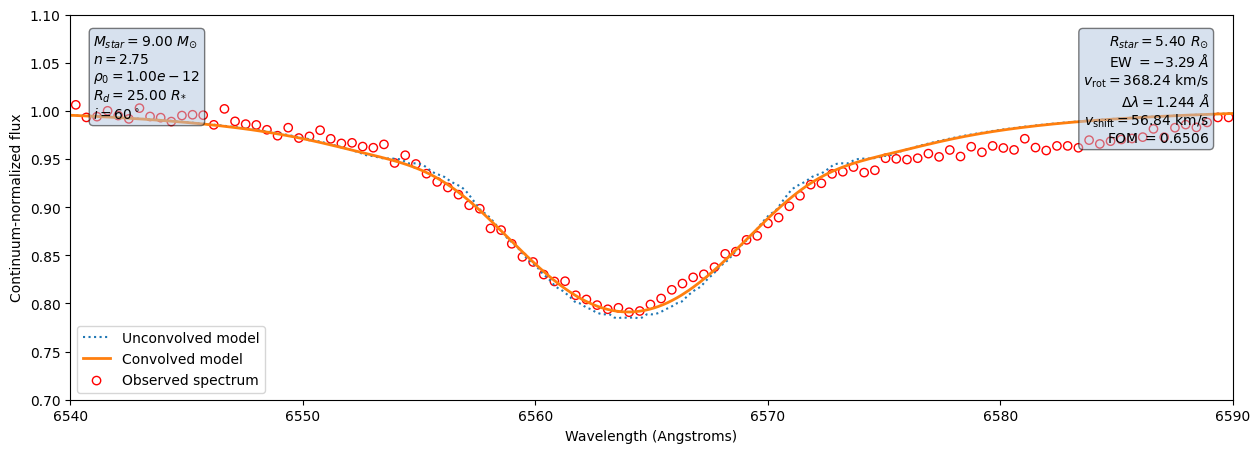

Plotting 2026-01-31
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.507
Velocity shift: 68.00 km/s


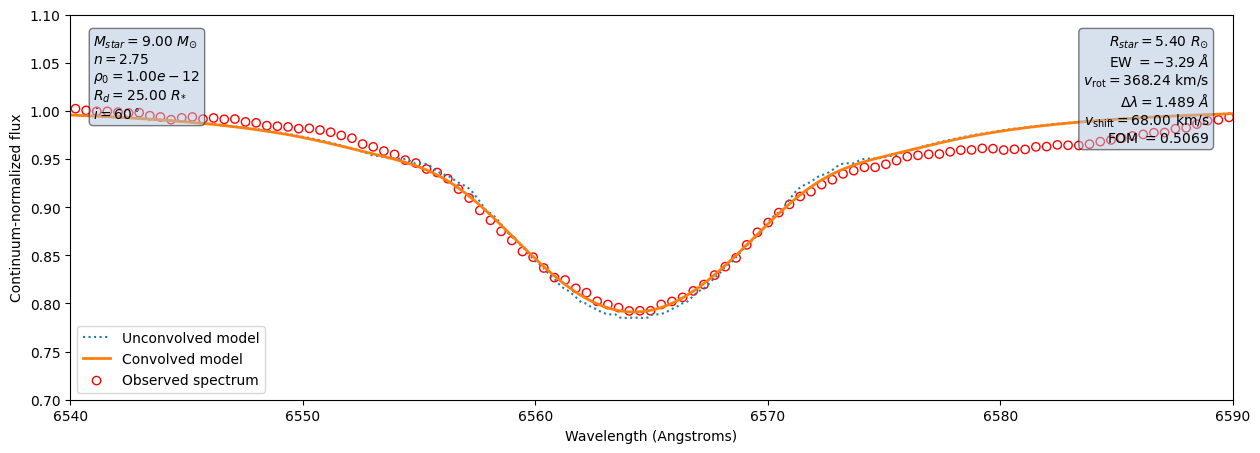

Plotting 2026-02-03
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.674
Velocity shift: 63.74 km/s


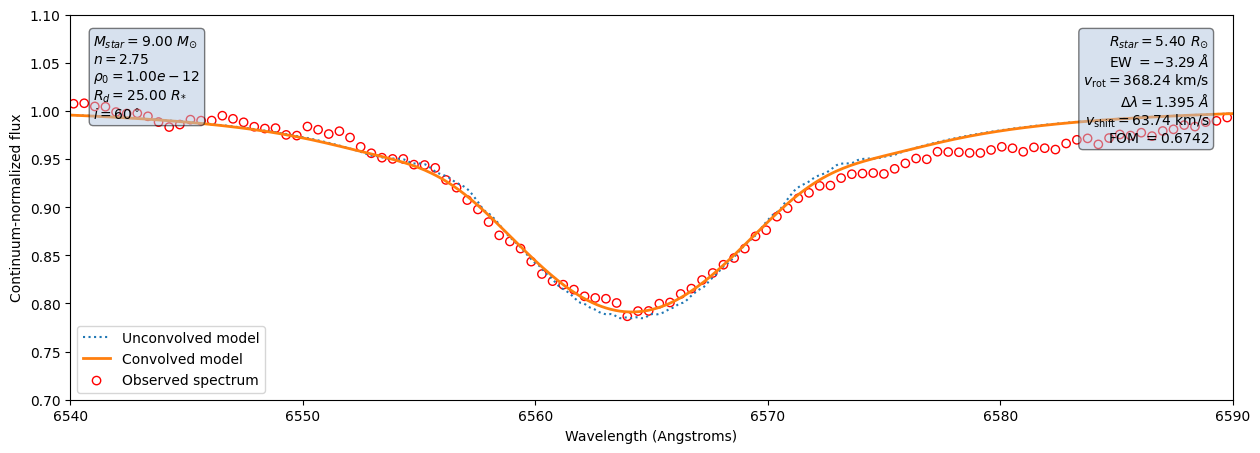

Plotting 2026-02-15
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.526
Velocity shift: 54.00 km/s


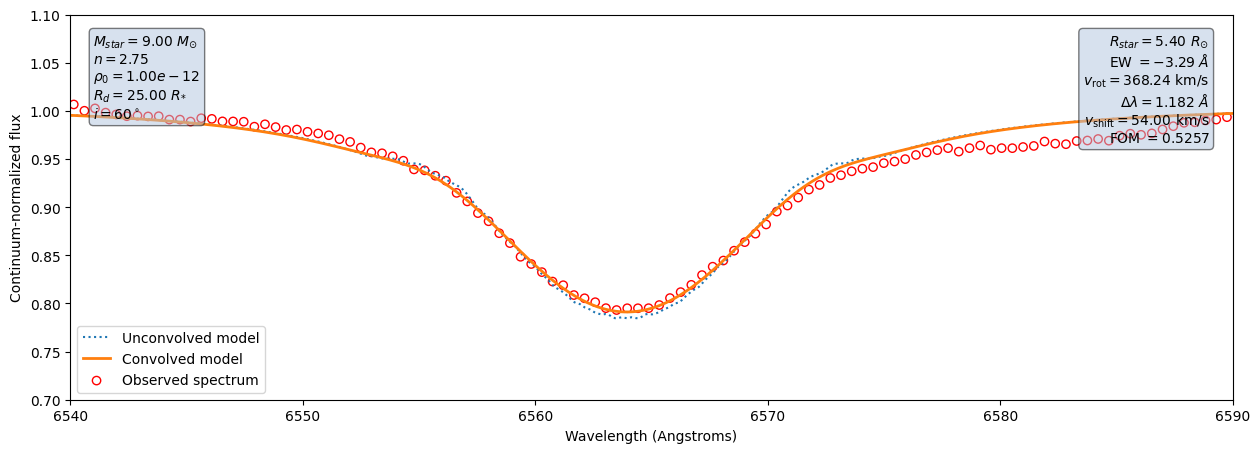

Plotting 2026-02-25
Best model: /Users/joshuamarine/Downloads/Model Spectra/M8p0V0p0z0p0X0p3/SPEC.M8p0V0p0z0p0X0p3_t12360_w0d0_j0h0_2d75_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.606
Velocity shift: 31.29 km/s


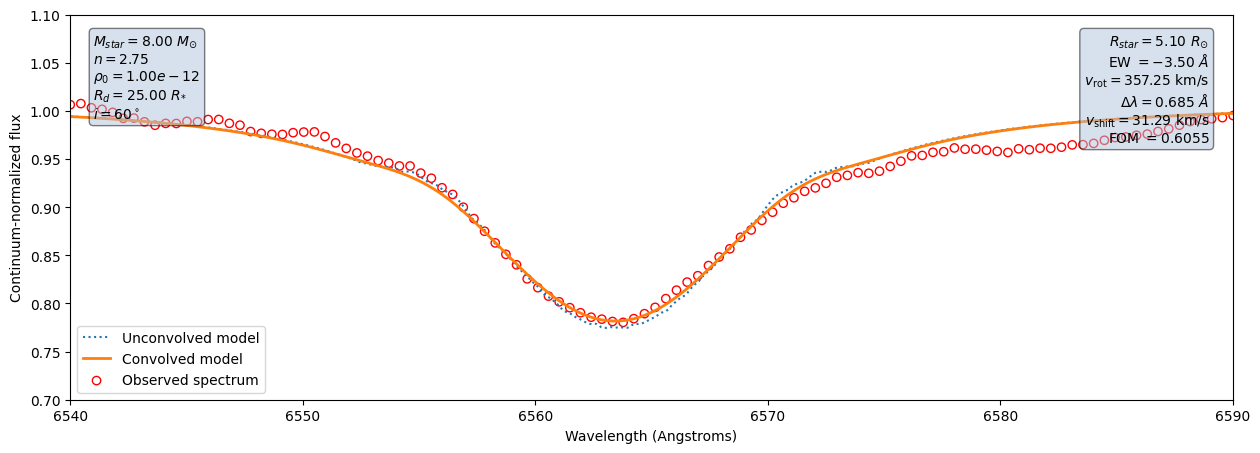

Plotting 2026-02-27
Best model: /Users/joshuamarine/Downloads/Model Spectra/M10p0V0p0z0p0X0p3/SPEC.M10p0V0p0z0p0X0p3_t14040_w0d0_j0h0_3d25_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.593
Velocity shift: 31.11 km/s


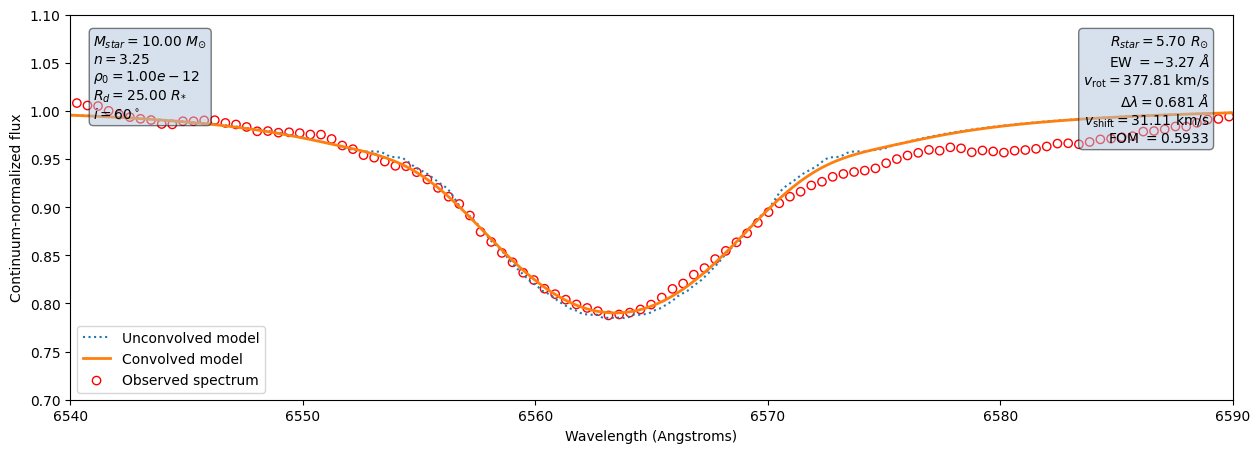

Plotting 2026-03-04
Best model: /Users/joshuamarine/Downloads/Model Spectra/M10p0V0p0z0p0X0p3/SPEC.M10p0V0p0z0p0X0p3_t14040_w0d0_j0h0_3d50_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.559
Velocity shift: 11.89 km/s


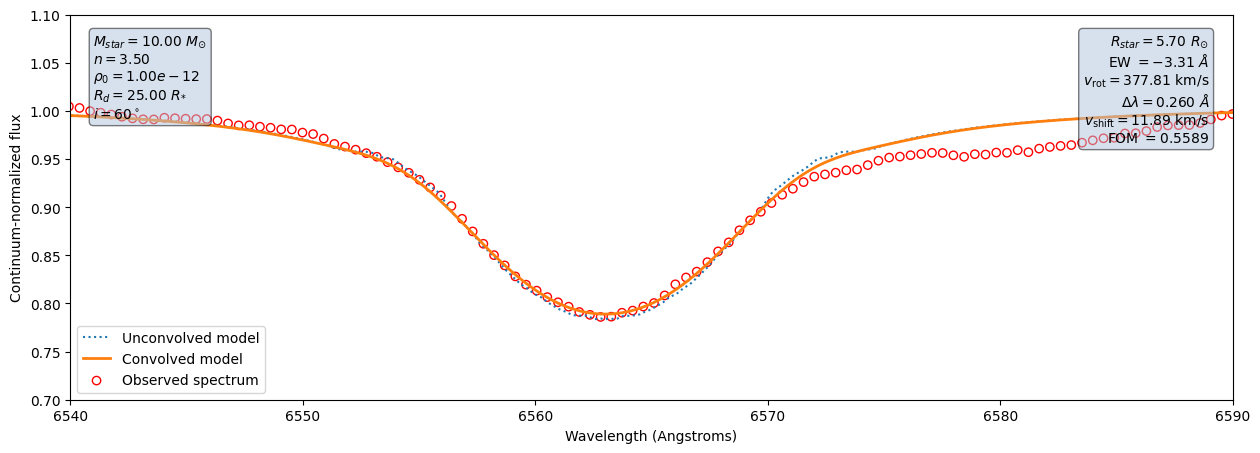

Plotting 2026-03-12
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_3d00_1d00em12_rd15p0_halpha_alp0p0_i60
FOM: 0.510
Velocity shift: 37.63 km/s


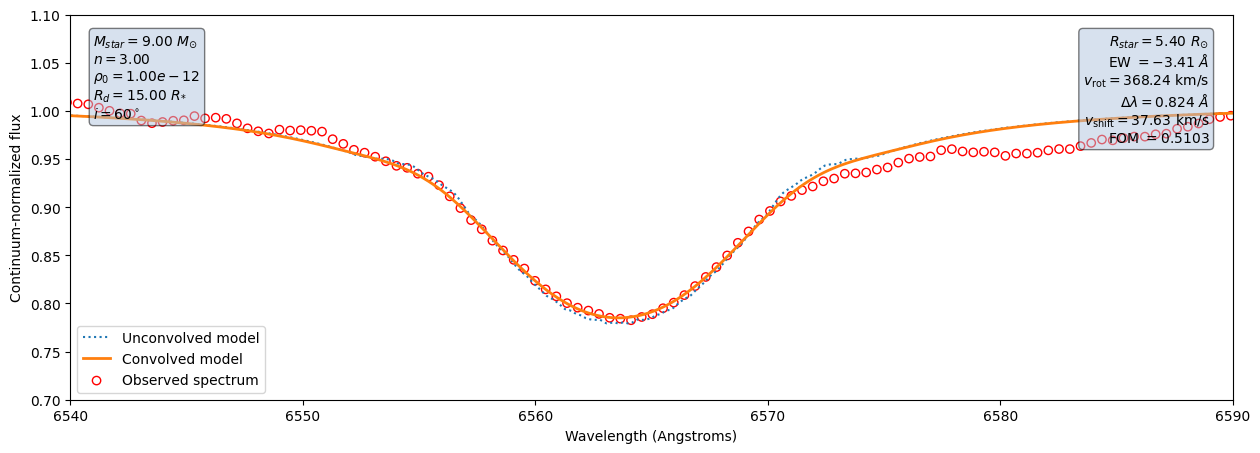

Plotting 2026-03-27
Best model: /Users/joshuamarine/Downloads/Model Spectra/M9p0V0p0z0p0X0p3/SPEC.M9p0V0p0z0p0X0p3_t13200_w0d0_j0h0_3d00_1d00em12_rd25p0_halpha_alp0p0_i60
FOM: 0.480
Velocity shift: 43.76 km/s


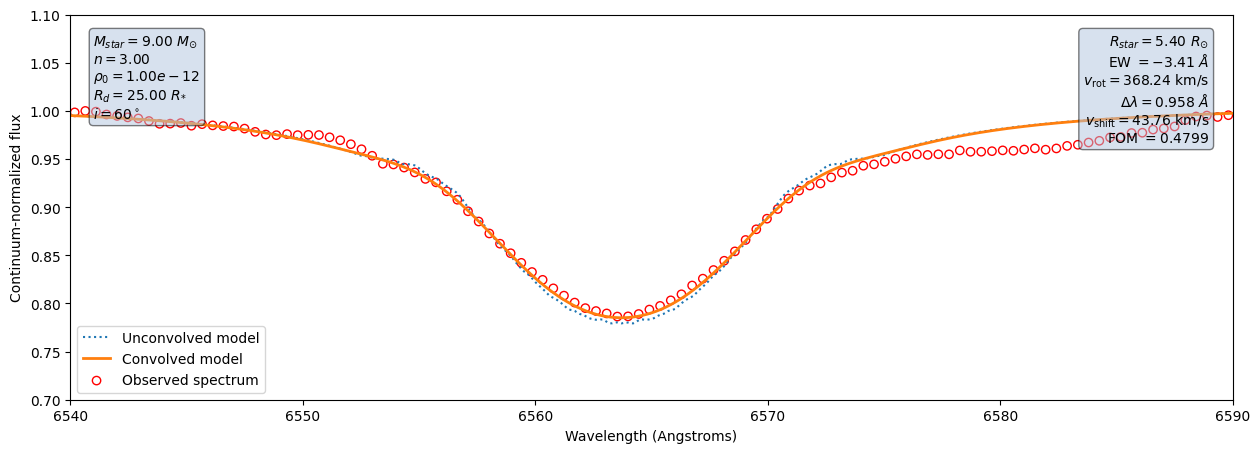

In [74]:
# 12/11, 11/25

summary = (
    all_results
    .sort_values("fom")
    .groupby("spectrum_id", as_index=False)
    .first()
)

for _, best in summary.iterrows():

    spectrum_id = best["spectrum_id"]
    best_model = best["model"]

    dataframe, header = load_model(best_model)

    test_spectrum = stacked_norm[spectrum_id]

    print(f"Plotting {spectrum_id}")
    print(f"Best model: {best_model}")
    print(f"FOM: {best['fom']:.3f}")
    print(f"Velocity shift: {best['velocity_shift_kms']:.2f} km/s")

    plot_model_overlay(
        test_spectrum,
        dataframe,
        header,
        fwhm,
        fit_result=best,
        xlim=(6540, 6590),
        ylim = (0.7, 1.1)
    )

Make Histograms of Matches

In [75]:
def summarize_accepted_over_time(all_results, accepted_fom=1.15):
    rows = []

    params = [
        "Mass",
        "Power Index",
        "rho_0",
        "Disk Radius",
        "Inclination Angle",
        "velocity_shift_kms",
    ]

    df = all_results.copy()
    df["log_rho_0"] = np.log10(df["rho_0"])

    params = [
        "Mass",
        "Power Index",
        "log_rho_0",
        "Disk Radius",
        "Inclination Angle",
        "velocity_shift_kms",
    ]

    for spectrum_id, group in df.groupby("spectrum_id"):
        accepted = group[group["f_rel"] <= accepted_fom]

        row = {
            "spectrum_id": spectrum_id,
            "n_accepted": len(accepted),
            "best_fom": group["fom"].min(),
        }

        for p in params:
            row[f"{p}_p16"] = accepted[p].quantile(0.16)
            row[f"{p}_median"] = accepted[p].quantile(0.50)
            row[f"{p}_p84"] = accepted[p].quantile(0.84)

        rows.append(row)

    return pd.DataFrame(rows)

In [76]:
summary_time = summarize_accepted_over_time(all_results, accepted_fom=1.15)
summary_time

,spectrum_id,n_accepted,best_fom,Mass_p16,Mass_median,Mass_p84,Power Index_p16,Power Index_median,Power Index_p84,log_rho_0_p16,...,log_rho_0_p84,Disk Radius_p16,Disk Radius_median,Disk Radius_p84,Inclination Angle_p16,Inclination Angle_median,Inclination Angle_p84,velocity_shift_kms_p16,velocity_shift_kms_median,velocity_shift_kms_p84
0,2025-11-14,2,0.614552,9.00,9.0,9.00,4.00,4.000,4.00,-10.628932,...,-10.628932,16.6,20.0,23.4,60.0,60.0,60.0,60.104578,60.116290,60.128002
1,2025-11-21,6,0.592231,8.00,9.0,9.20,2.75,3.750,3.75,-11.314258,...,-10.801343,5.0,15.0,25.0,60.0,60.0,60.0,57.335196,57.856906,58.079780
2,2025-11-24,2,0.561315,9.00,9.0,9.00,4.00,4.000,4.00,-10.801343,...,-10.801343,16.6,20.0,23.4,50.0,50.0,50.0,64.750435,64.770016,64.789597
3,2025-11-25,3,0.533279,8.00,8.0,8.68,3.50,3.500,3.84,-10.970616,...,-10.855510,8.2,15.0,21.8,53.2,60.0,60.0,63.031761,64.448847,65.160172
4,2025-11-27,3,0.443761,9.00,9.0,9.68,3.24,3.750,3.75,-11.204293,...,-10.970616,8.2,15.0,21.8,50.0,50.0,50.0,55.814915,55.859336,56.294692
5,2025-12-01,4,0.567102,9.00,9.0,9.52,2.75,3.125,3.50,-11.485452,...,-11.142668,5.0,10.0,20.2,50.0,50.0,50.0,63.349676,64.564855,65.178155
6,2025-12-03,1,0.490455,9.00,9.0,9.00,2.75,2.750,2.75,-11.485452,...,-11.485452,5.0,5.0,5.0,50.0,50.0,50.0,70.883683,70.883683,70.883683
7,2025-12-07,2,0.491828,8.00,8.0,8.00,3.25,3.250,3.25,-11.314258,...,-11.314258,16.6,20.0,23.4,50.0,50.0,50.0,68.355357,68.485505,68.615654
8,2025-12-08,3,0.490213,8.00,8.0,8.68,2.74,3.250,3.25,-11.547715,...,-11.314258,8.2,15.0,21.8,50.0,50.0,50.0,64.714452,64.965572,65.154567
9,2025-12-09,3,0.486861,8.00,8.0,8.68,2.74,3.250,3.25,-11.547715,...,-11.314258,8.2,15.0,21.8,50.0,50.0,50.0,68.019034,68.594283,69.507172


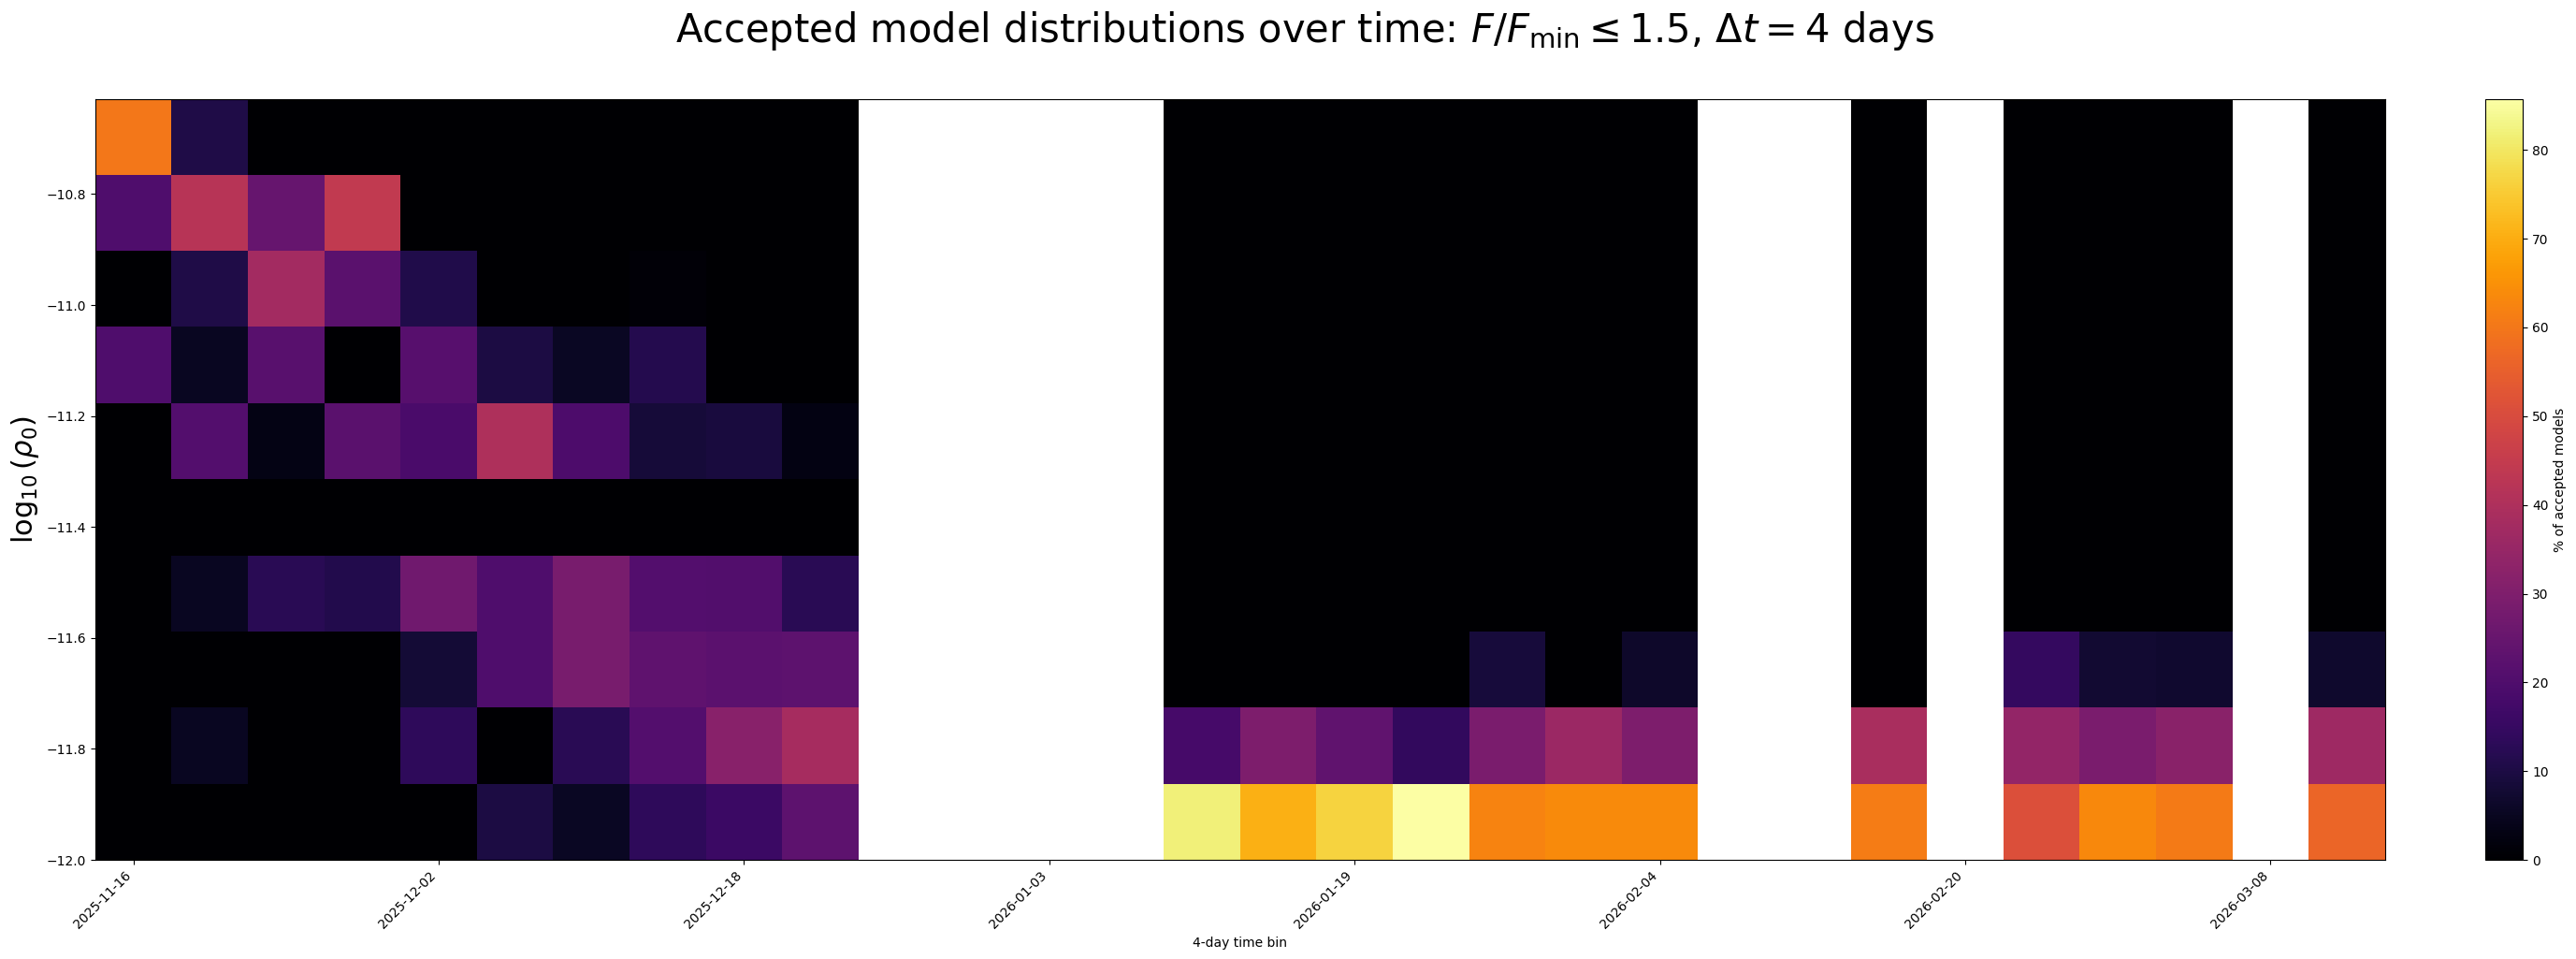

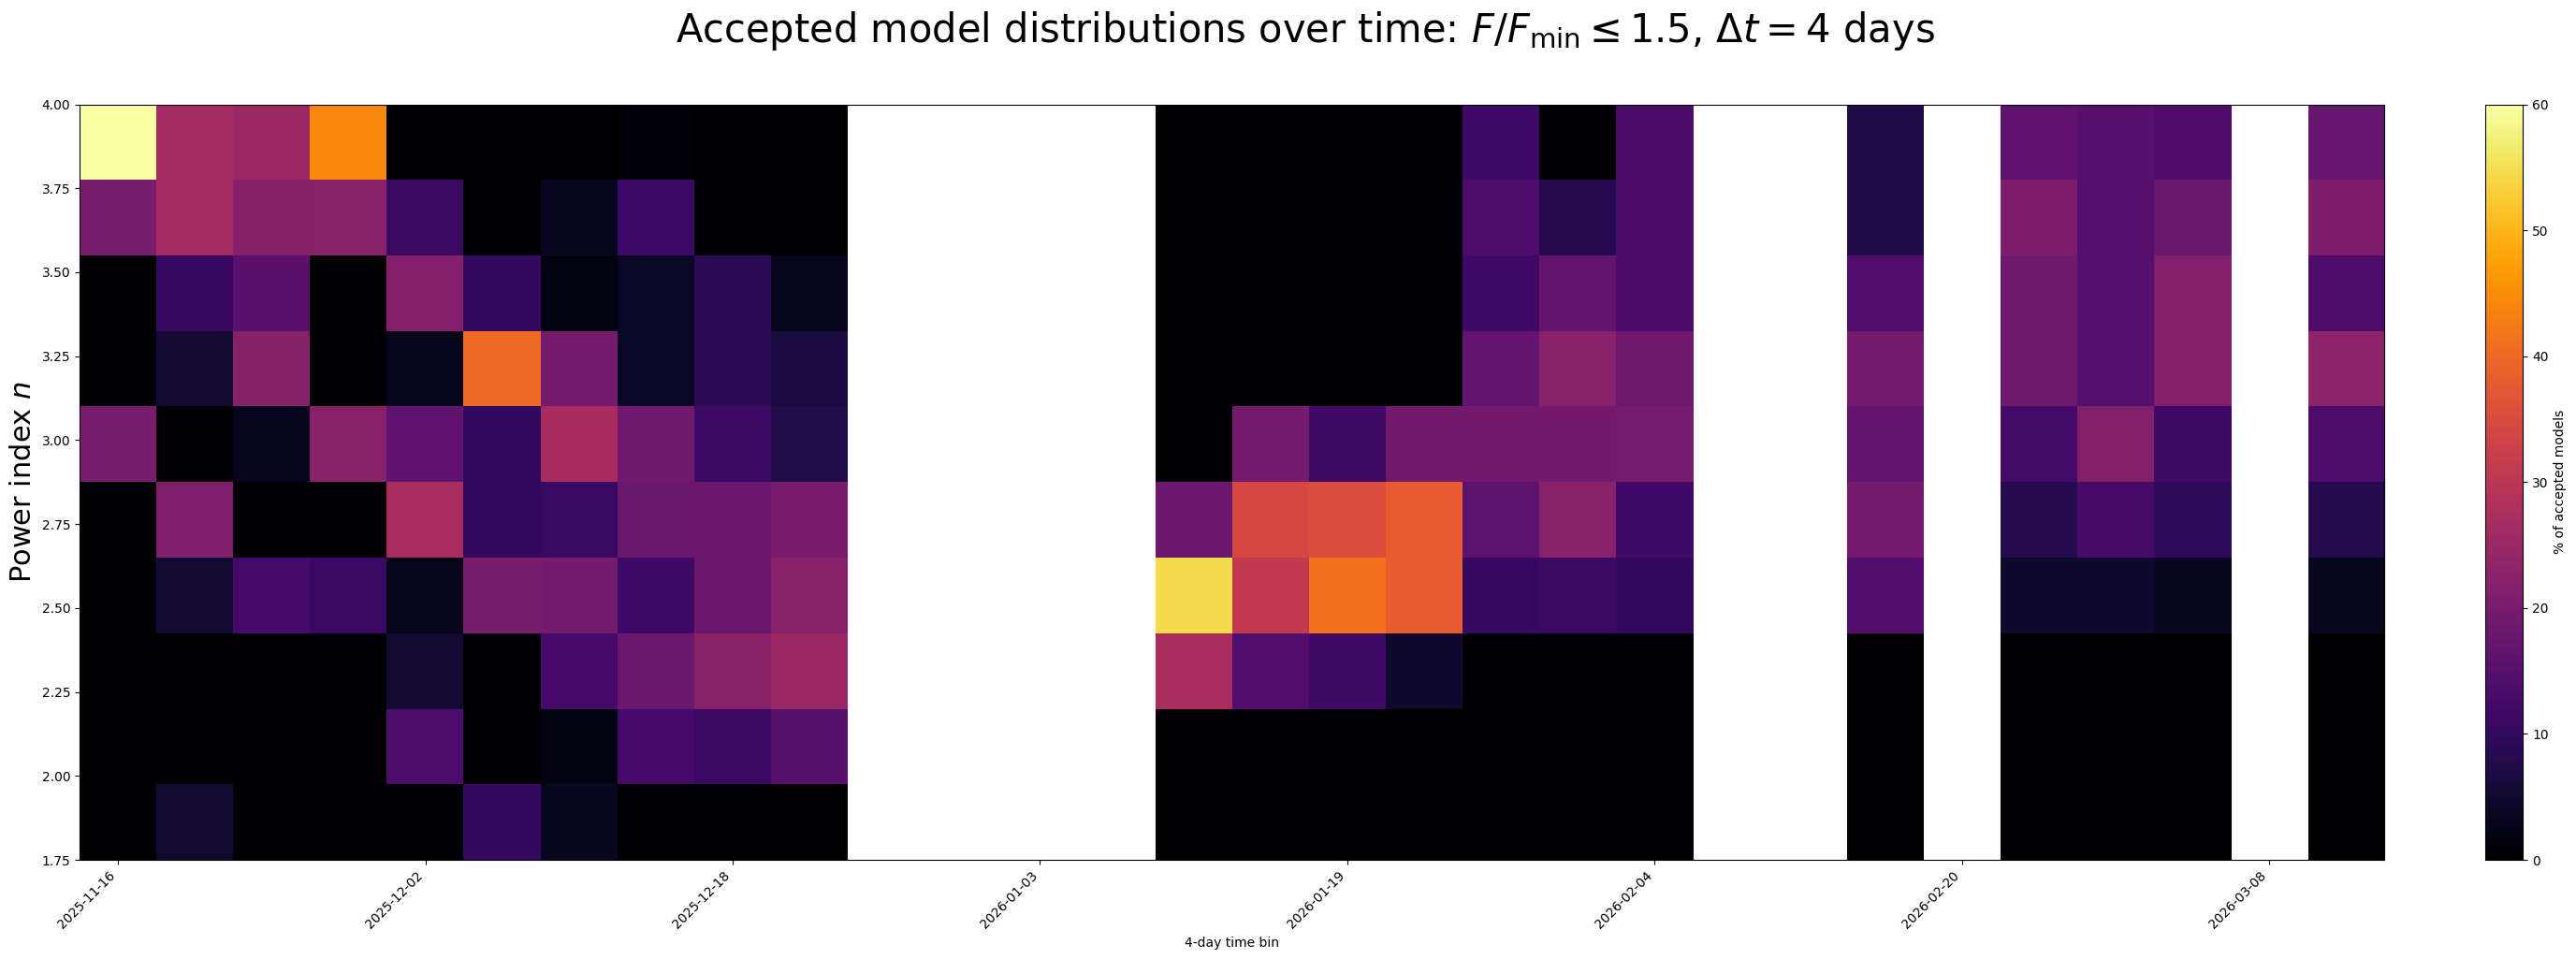

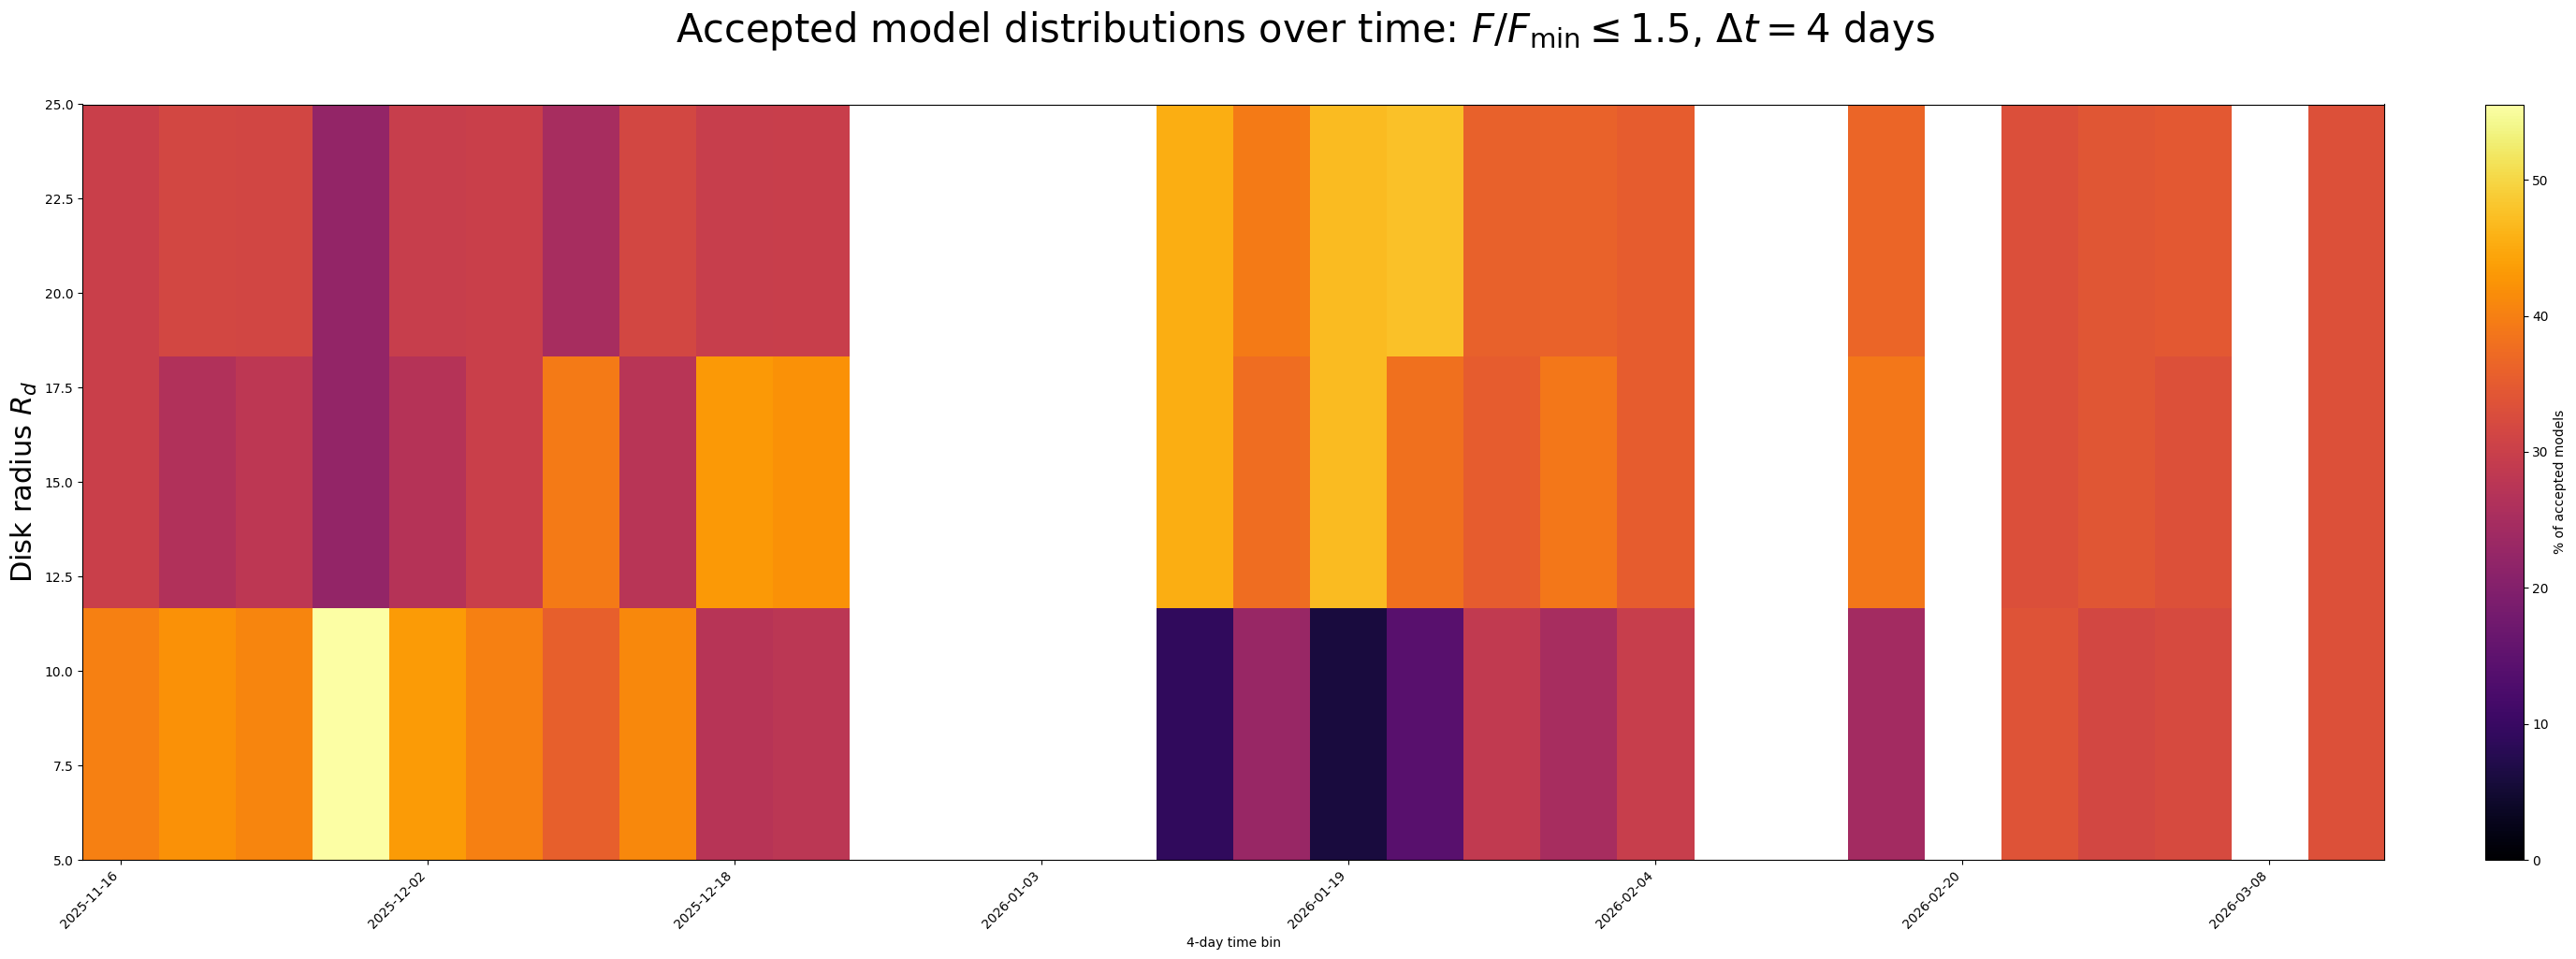

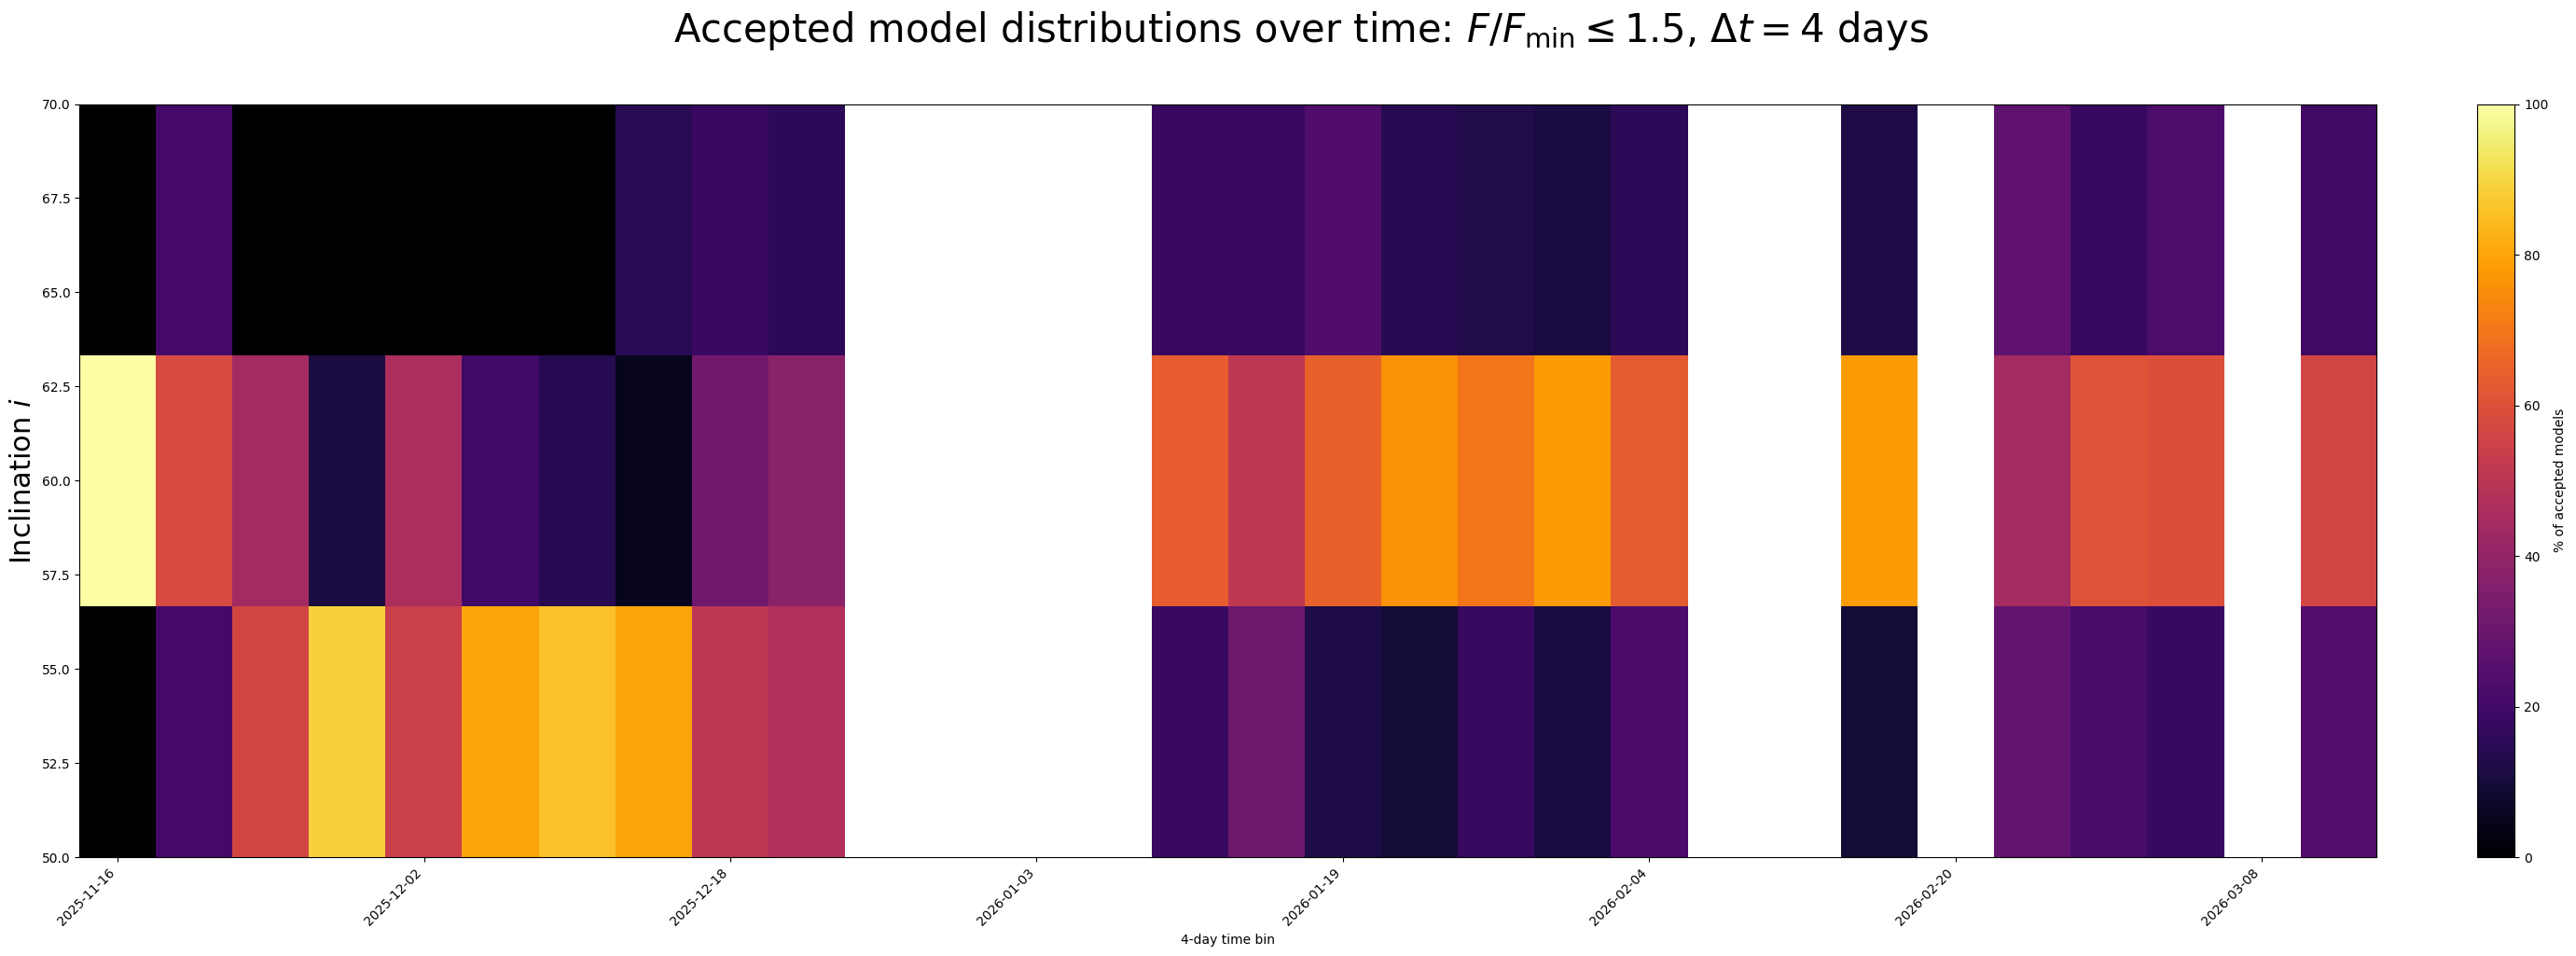

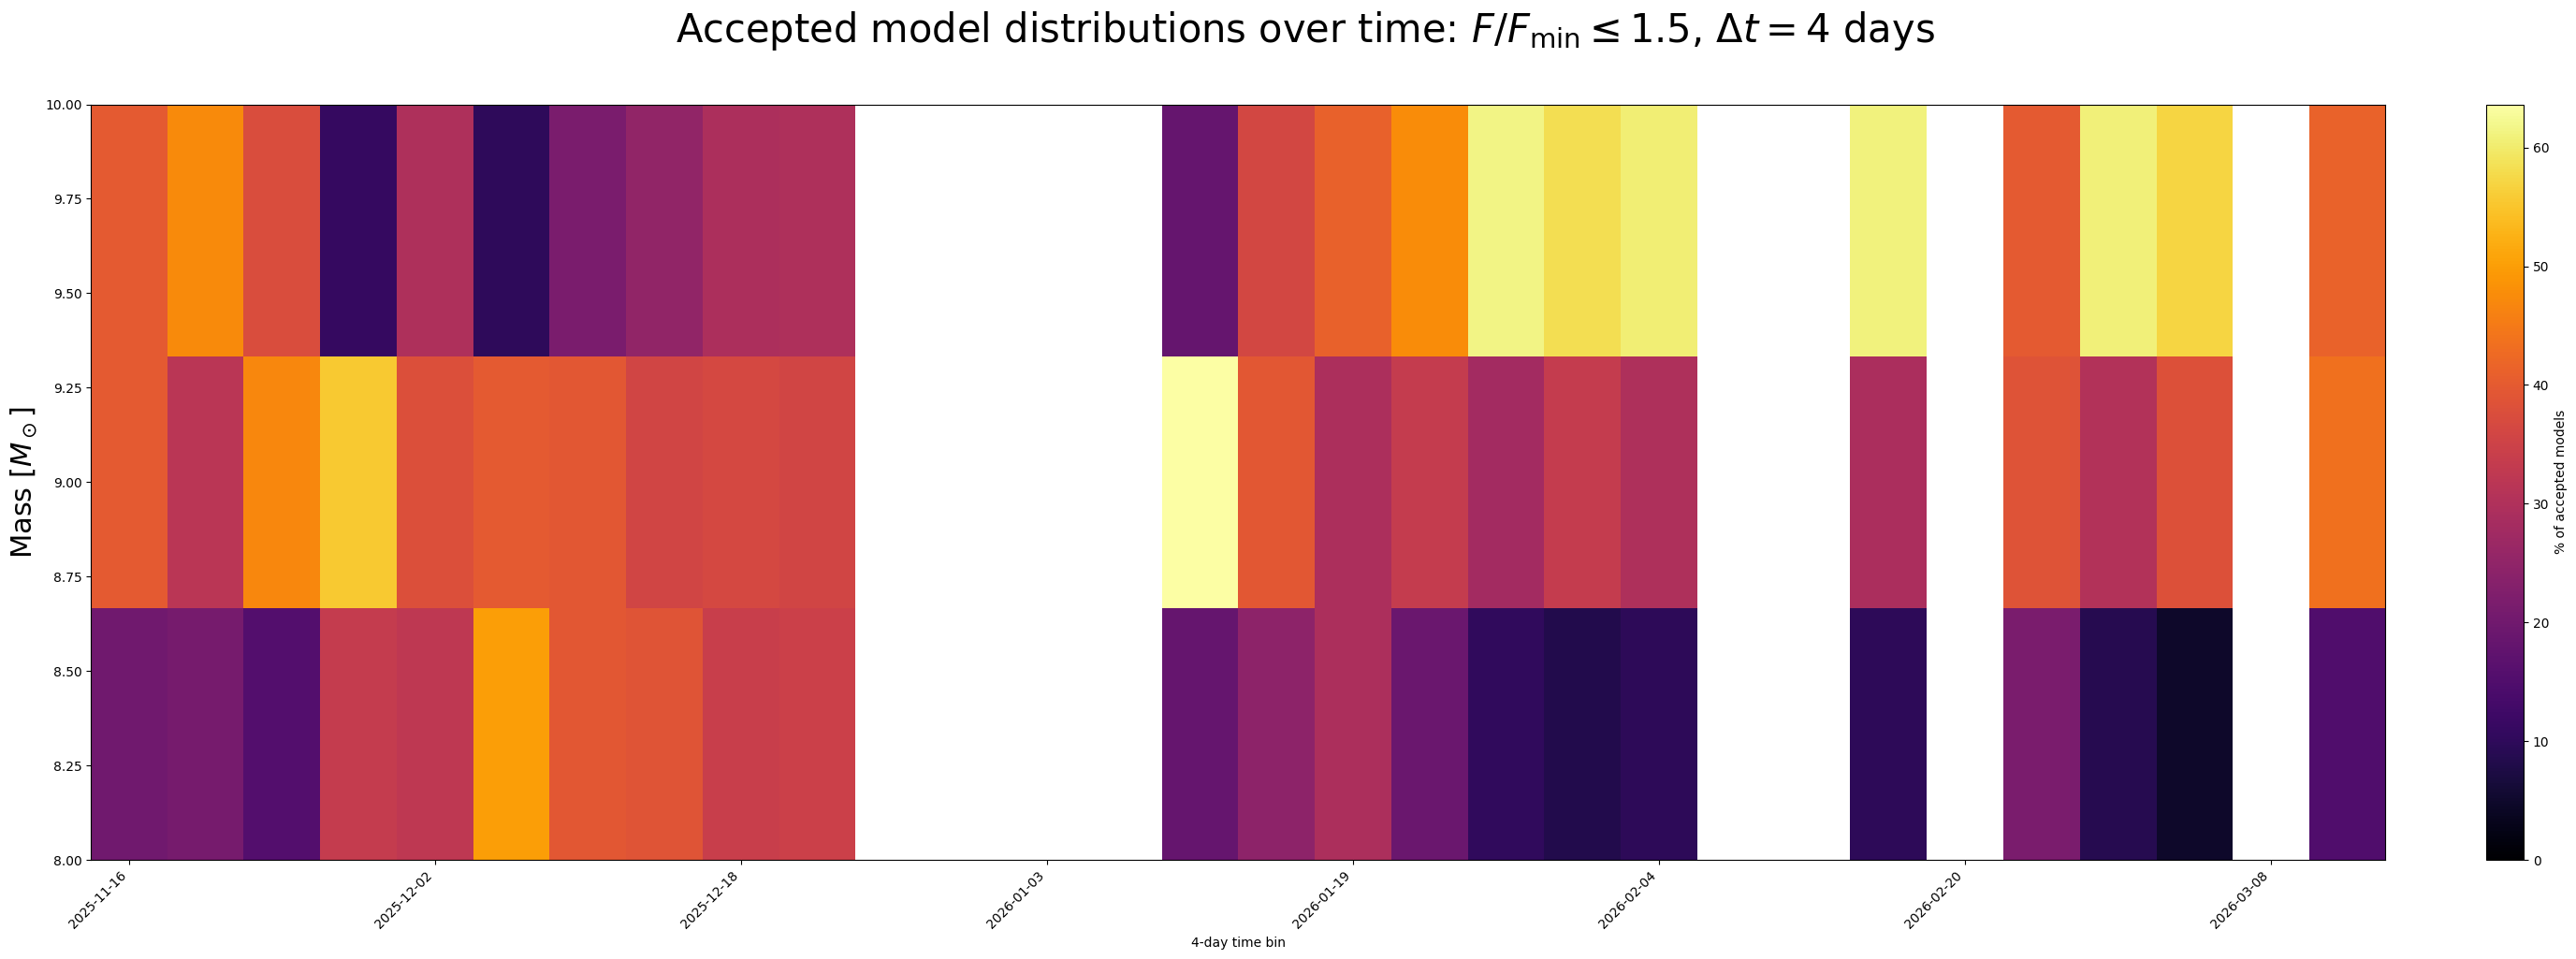

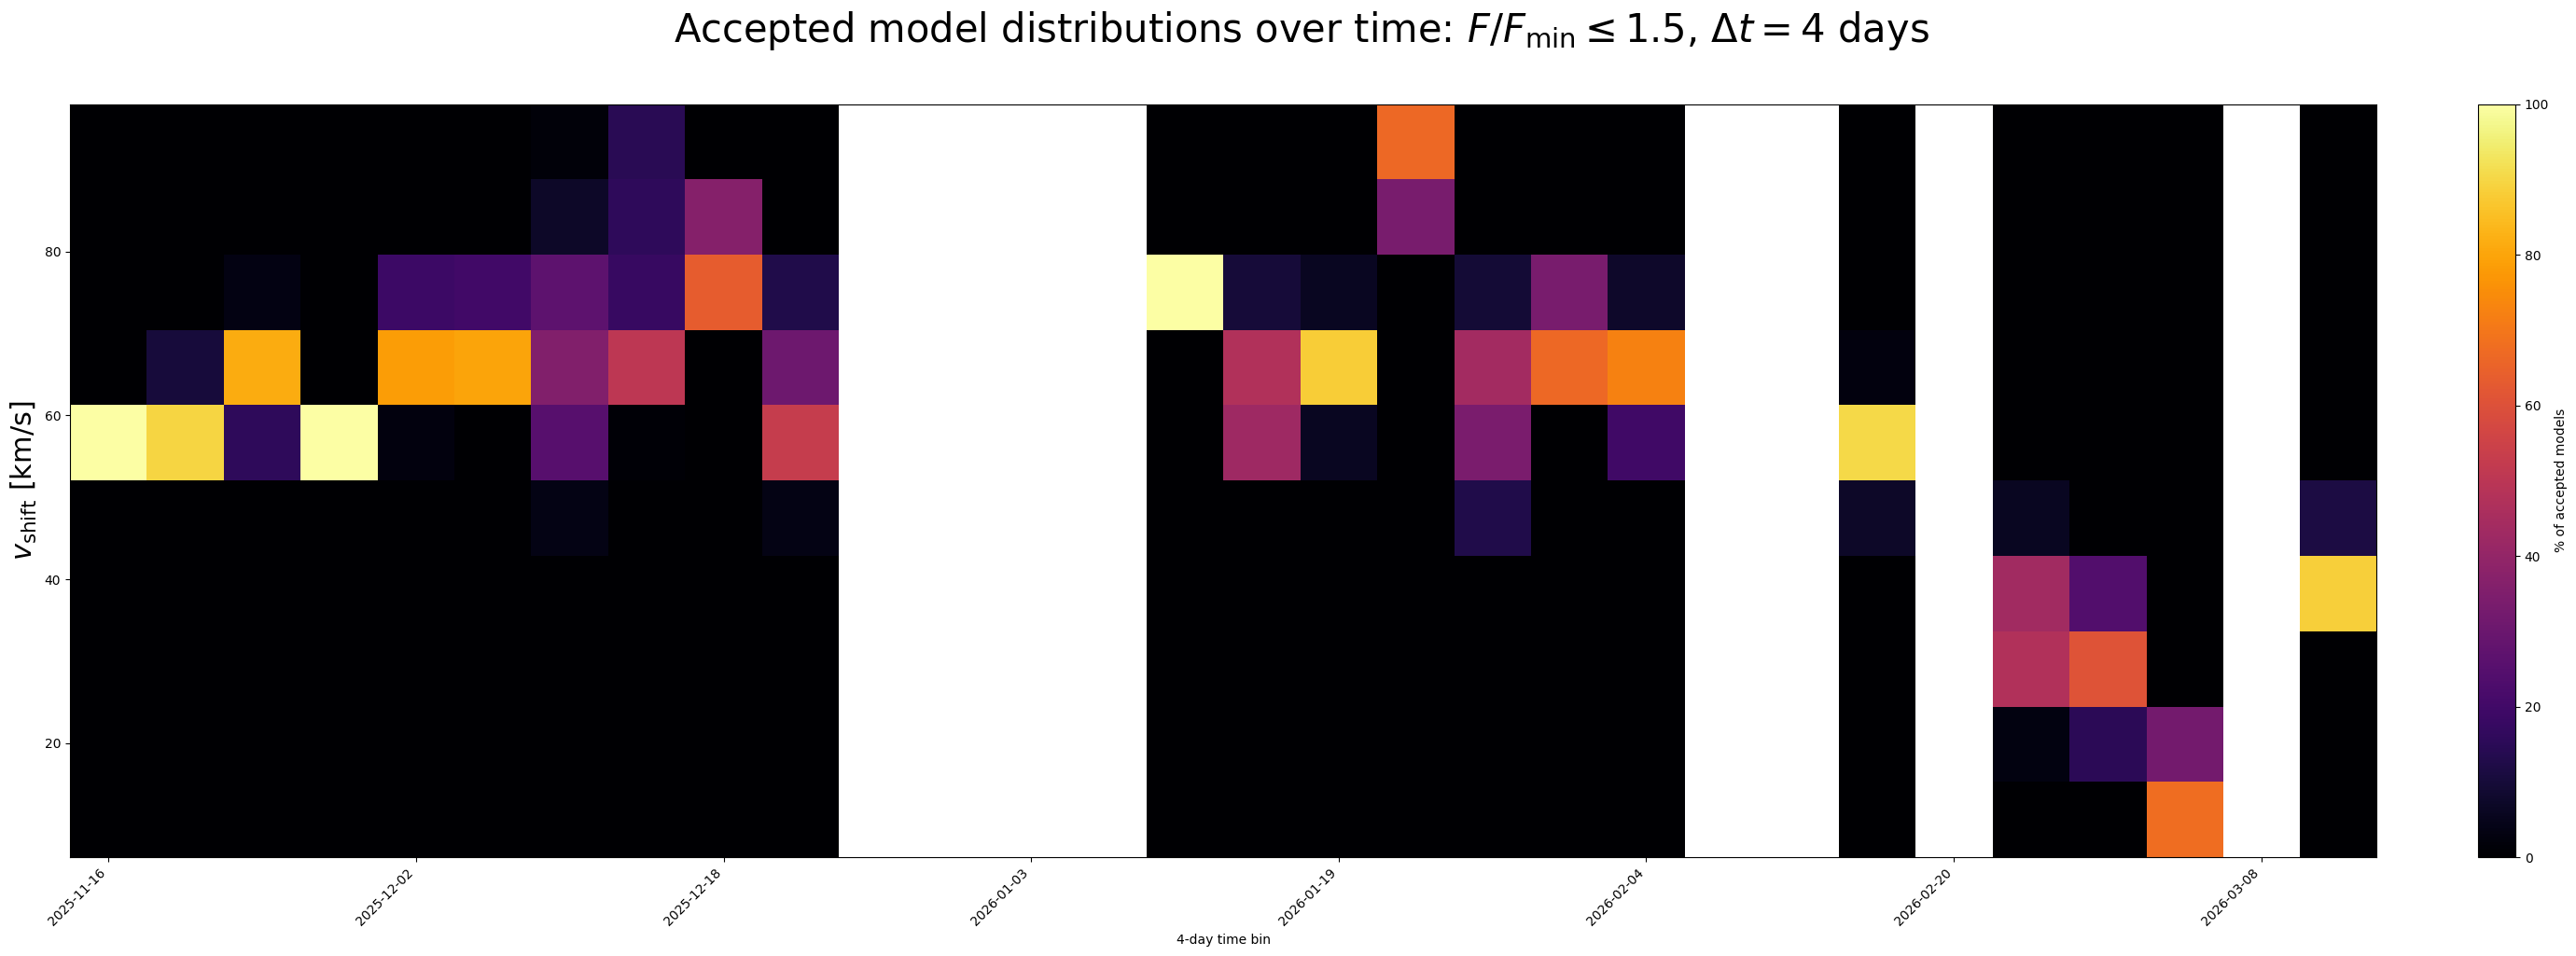

In [ ]:
params = ["log_rho_0", "Power Index", "Disk Radius", "Inclination Angle", "Mass", "velocity_shift_kms"]
bins = [10, 10, 3, 3, 3, 10]


for param, bin in zip(params, bins):
    plot_parameter_time_distribution(
        all_results,
        # all_results[601425:],
        # accepted_fom=1.15,
        accepted_fom=1.5,
        params = [param],
        show_summary=False,
        show_heatmap=True,
        show_3d_surface=False,
        show_3d_waterfall=False,
        bins=bin,
        cmap="inferno",
        figsize_per_panel=(28, 10),
        tbin = 4,
        date_range = ['2025-11-14', '2026-03-16']
    )